In [1]:
# !pip install segmentation-models-pytorch
# !pip install torchmetrics
# !pip install mlflow[databricks]

In [2]:
import os

# Replace with your actual workspace URL and token
# os.environ['DATABRICKS_HOST'] = ""
# os.environ['DATABRICKS_TOKEN'] = ""




In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupKFold

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms

import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

# from torchmetrics.segmentation import DiceScore
# from torchmetrics.segmentation import MeanIoU

from tqdm import tqdm
import json

# Configurar el dispositivo (GPU si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def build_color_map_from_json(label_dict):
    color_map_raw = label_dict["mascara_multiclase_color_rgb"]
    return {int(k): tuple(v) for k, v in color_map_raw.items()}

def build_label_map_from_json(label_dict):
    label_map_raw = label_dict["mascara_multiclase_id_png"]
    return {int(k): v for k, v in label_map_raw.items()}

def create_color_overlay(mask, color_map, alpha=0.45):
    h, w = mask.shape
    overlay = np.zeros((h, w, 3), dtype=np.uint8)

    for class_id, color in color_map.items():
        overlay[mask == class_id] = color

    return overlay

def get_class_centroid(mask, class_id):
    ys, xs = np.where(mask == class_id)
    if len(xs) == 0 or len(ys) == 0:
        return None
    cx = int(np.mean(xs))
    cy = int(np.mean(ys))
    return cx, cy

def show_overlay_with_labels(image, mask, label_dict, alpha=0.45, min_pixels=20):
    label_map = build_label_map_from_json(label_dict)
    color_map = build_color_map_from_json(label_dict)

    # image = cv2.imread(image_path)
    # image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    overlay = create_color_overlay(mask, color_map, alpha=alpha)

    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.imshow(overlay, alpha=alpha)

    unique_vals = np.unique(mask)

    for class_id in unique_vals:
        if class_id == 0:
            continue

        region = (mask == class_id)
        if region.sum() < min_pixels:
            continue

        centroid = get_class_centroid(mask, class_id)
        if centroid is None:
            continue

        x, y = centroid
        class_name = label_map.get(int(class_id), str(class_id))

        plt.text(
            x, y, class_name,
            fontsize=9,
            ha="center",
            va="center",
            color="white",
            bbox=dict(facecolor="black", alpha=0.6, boxstyle="round,pad=0.2")
        )

    plt.title("Overlay con clases anatómicas")
    plt.axis("off")
    plt.show()

In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

In [6]:
# dataset = '/content/drive/MyDrive/Documentos/UniAndes/MAIA/2026-12/Proyecto Despluiegue de Soluciones/Proyecto/Scoliosis_Dataset'
# indice = pd.read_csv(os.path.join(dataset,'indice_dataset.csv'))

In [7]:
# dataset = 'Scoliosis_Dataset'
project_path = 'C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA'
dataset = os.path.join(project_path,'Scoliosis_Dataset')
indice = pd.read_csv(os.path.join(dataset,'indice_dataset.csv'))
data_split = 'C:/Users/juanm/PycharmProjects/Segmentacion_semantica_columna/notebooks/medsam_pipeline/data_splits\splits_estratificados_medsam.csv'
data_split = pd.read_csv(data_split)

In [8]:
with open(dataset+os.sep+'diccionario_etiquetas_T1_T12_L1_L5.json', 'r') as f:
    dic_labels = json.load(f)

color_label = dic_labels['mascara_multiclase_color_rgb']

In [9]:
# imagenes = pd.DataFrame(columns=['image_path', 'mask_path', 'id_paciente'])
# imagenes['image_path'] = dataset +os.sep + indice['grupo'] + os.sep + indice['imagen']
# imagenes['mask_path'] = dataset + os.sep + indice['ruta_mascara_multiclase_id_png']
# imagenes['id_paciente'] = indice['id_paciente']
# masks_path = masks_path.apple(dataset, indice['grupo'], indice['ruta_mascara_multiclase_id_png'])

In [10]:
# imagenes

In [11]:
train = data_split[data_split['split'] == 'train']
val = data_split[data_split['split'] == 'val']
test = data_split[data_split['split'] == 'test']

In [12]:
train_img = project_path+os.sep+train['image_relpath'].reset_index(drop=True)
train_mask = project_path+os.sep+train['mask_relpath'].reset_index(drop=True)
val_img = project_path+os.sep+val['image_relpath'].reset_index(drop=True)
val_mask = project_path+os.sep+val['mask_relpath'].reset_index(drop=True)
test_img = project_path+os.sep+test['image_relpath'].reset_index(drop=True)
test_mask = project_path+os.sep+test['mask_relpath'].reset_index(drop=True)

In [13]:
print(f'Train: {train_img.shape} Val: {val_img.shape} Test: {test_img.shape}')

Train: (174,) Val: (37,) Test: (38,)


In [14]:
MODEL_NAME = 'Unet++'
MODEL_PATH = 'modelos'+os.sep+MODEL_NAME+'.pth'
SEED = 42
NUM_EPOCHS = 50
BATCH_SIZE = 4
PATIENCE = 20
STRIDE = 4
LR = 1e-3                   # Learning rate
WD = 0                   # Weight Decay
DROPOUT = None
PATCH_SIZE = 128
NUM_PATCHES = 8
CROP_RATIO = (0.1, 0.5)
STRIDE_RATIO = 4
IN_CHANNELS = 3
NUM_CLASSES = 18
TRAIN_ENCODER = True
CENTER_IMAGES = True
CLAHE = True
PERSPECTIVE = True

# LOSS = 'CrossEntropyLoss'
LOSS = 'CombinedLoss'
# LOSS = 'CombinedLossFocal'
# LOSS = 'DiceLoss'

# ENCODER_NAME = "resnet34"
# ENCODER_NAME = "resnet152"
ENCODER_NAME = "efficientnet-b7"
# ENCODER_NAME = "mit_b5"
# ENCODER_NAME = "tu-swinv2_small_window16_256"
# ENCODER_NAME = 'tu-sam2_hiera_large'

ENCODER_WEIGHTS = "imagenet"
# ENCODER_WEIGHTS = None

# DECODER_ATTENTION = 'scse'
DECODER_ATTENTION = None

MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)

if IN_CHANNELS == 1:
  MEAN = 0.44531356896770125
  STD = 0.2692461874154524

# CE_WEIGHT = 0.5
# DICE_WEIGHT = 0.5
# BASE_CHANNELS = 32

In [15]:
import mlflow

# Set the tracking URI to the Databricks workspace
mlflow.set_tracking_uri("databricks")

# Set the experiment name (must start with /Users/<email>/ or /Shared/)
experiment = mlflow.set_experiment("/"+MODEL_NAME+'_patch')

In [16]:
def compute_metrics(preds, targets, num_classes=NUM_CLASSES, eps=1e-6, average=True):

    dice_scores = []
    iou_scores = []

    for cls in range(num_classes):
        pred_cls = (preds == cls)
        target_cls = (targets == cls)

        intersection = np.sum(np.logical_and(pred_cls==1,target_cls==1))
        union = np.sum(np.logical_or(pred_cls==1,target_cls==1))

        dice = (2 * intersection + eps) / (pred_cls.sum() + target_cls.sum() + eps)
        iou = (intersection + eps) / (union + eps)

        dice_scores.append(dice)
        iou_scores.append(iou)

    if average:
        return np.mean(dice_scores), np.mean(iou_scores)
    else:
        return dice_scores, iou_scores

In [17]:
def compute_metrics_torch(preds, targets, num_classes=NUM_CLASSES, eps=1e-6, average=True):

    num_classes = num_classes

    # Convert targets to one-hot: [N, C, H, W]
    targets_one_hot = torch.nn.functional.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()

    preds_one_hot = torch.nn.functional.one_hot(preds, num_classes).permute(0, 3, 1, 2).float()

    # Calculate intersection and cardinality
    dims = (2, 3) # Sum over batch, height, and width
    intersection = torch.sum(preds_one_hot * targets_one_hot, dim=dims)
    union = torch.sum(preds_one_hot + targets_one_hot, dim=dims) - intersection

    dice_score = (2. * intersection + eps) / (torch.sum(preds_one_hot, dim=dims) + torch.sum(targets_one_hot, dim=dims) + eps)
    iou_score = (intersection + eps) / (union + eps)

    if average:
        return dice_score.mean(dim=1), iou_score.mean(dim=1)
    else:
        return dice_score, iou_score

In [18]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        # logits: [N, C, H, W], targets: [N, H, W]
        num_classes = logits.shape[1]
        probs = torch.nn.functional.softmax(logits, dim=1)

        # Convert targets to one-hot: [N, C, H, W]
        targets_one_hot = torch.nn.functional.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()

        # Calculate intersection and cardinality
        dims = (0, 2, 3) # Sum over batch, height, and width
        intersection = torch.sum(probs * targets_one_hot, dim=dims)
        union = torch.sum(probs + targets_one_hot, dim=dims)

        dice_score = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice_score.mean() # Return mean loss across classes

class CombinedLoss(nn.Module):
    def __init__(self, ce_weight=1, dice_weight=1):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        dice_loss = self.dice(logits, targets)
        return self.ce_weight * ce_loss + self.dice_weight * dice_loss

class CustomWeightedFocalLoss(nn.Module):
    def __init__(self, alpha_weights, gamma=2.0):
        super().__init__()
        # Esperamos un tensor 1D puro de tamaño [18]
        self.alpha_weights = alpha_weights
        self.gamma = gamma

    def forward(self, logits, targets):
        # 1. Calculamos la Cross Entropy SIN pesos para obtener la probabilidad real (pt)
        # reduction='none' mantiene la forma [Batch, H, W]
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)

        # 2. Aplicamos la fórmula base de Focal Loss
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        # 3. EL TRUCO MAGNÍFICO: Mapeo de pesos
        # targets contiene la clase correcta (0-17) de cada píxel.
        # Al hacer esto, extraemos el peso exacto para cada píxel individual,
        # creando un tensor 'pixel_weights' de forma idéntica: [Batch, H, W]
        pixel_weights = self.alpha_weights[targets]

        # 4. Multiplicamos de forma segura (ambos tensores son [Batch, H, W]) y promediamos
        weighted_focal_loss = focal_loss * pixel_weights

        return weighted_focal_loss.mean()

class CombinedLossFocal(nn.Module):
    def __init__(self, fl_weight=1, dice_weight=1):
        super().__init__()

        class_frequencies = np.array([1.0, 0.9718875502008032, 0.9879518072289156, 0.9919678714859438, 0.9879518072289156, 0.9759036144578314, 0.9558232931726908, 0.9317269076305221, 0.9116465863453815, 0.8955823293172691, 0.8714859437751004, 0.7991967871485943, 0.7590361445783133, 0.6546184738955824, 0.6265060240963856, 0.5502008032128514, 0.4819277108433735, 0.44176706827309237]
        )

        # 2. Calcular Alpha usando frecuencia inversa suavizada (Raíz cuadrada)
        # Agregamos un pequeño epsilon (1e-5) para evitar división por cero
        # alpha = 1.0 / np.sqrt(class_frequencies + 1e-5)
        #
        # # 3. Normalizar los alphas para que no den números gigantes que exploten el gradiente
        # alpha = alpha / np.sum(alpha)
        #
        # # alpha=torch.tensor(alpha, dtype=torch.float32).to(device)
        # alpha = torch.tensor(alpha, dtype=torch.float32).to(device)

        alpha = None

        self.focal = smp.losses.FocalLoss(mode='multiclass', alpha=None, gamma=2.0) if alpha == None else CustomWeightedFocalLoss(alpha_weights=alpha, gamma=2.0)
        self.dice = smp.losses.DiceLoss(mode='multiclass', from_logits=True)
        self.fl_weight = fl_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        fl_loss = self.focal(logits, targets)
        dice_loss = self.dice(logits, targets)
        return self.fl_weight * fl_loss + self.dice_weight * dice_loss

In [19]:
class CustomSegmentationDataset(Dataset):
    def __init__(self, images_filenames, masks_filenames, transform=None, num_patches=NUM_PATCHES):
        self.images_filenames = images_filenames
        self.masks_filenames = masks_filenames
        self.transform = transform
        self.num_patches = num_patches

    def __len__(self):
        return len(self.images_filenames)

    def __getpath__(self, idx):
        return self.images_filenames[idx]

    def __getitem__(self, idx):
        image_path = self.images_filenames[idx]
        mask_path = self.masks_filenames[idx]
        try:
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)

            patches_img = []
            patches_mask = []
            for _ in range(self.num_patches):
                if self.transform:
                    augmented = self.transform(image=image, mask=mask)
                    p_image = augmented['image']
                    p_mask = augmented['mask']

                    patches_img.append(p_image)
                    patches_mask.append(p_mask)

            stacked_images = torch.stack(patches_img)
            stacked_masks = torch.stack(patches_mask)

        except:
            new_idx = (idx + 1)
            return self.__getitem__(new_idx)


        return stacked_images, stacked_masks

In [20]:
# --- TRANSFORMACIONES (Albumentations) ---
normalization = A.Normalize(mean=MEAN, std=STD)
clahe = A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0)

# Transformaciones de entrenamiento: redimensionamiento, aumento de datos y normalización
train_transforms = []
# train_transforms += [A.OneOf([A.CropNonEmptyMaskIfExists(height=PATCH_SIZE, width=PATCH_SIZE, p=0.8), A.RandomCrop(height=PATCH_SIZE, width=PATCH_SIZE, p=0.2)], p=1)]
train_transforms += [A.RandomResizedCrop(size=(PATCH_SIZE,PATCH_SIZE), scale=CROP_RATIO, ratio=(1,1), p=1), A.GaussNoise(std_range=(0.05, 0.1), p=1.0)]


train_transforms+=[
    A.HorizontalFlip(p=0.2),
    A.Rotate(limit=(-10, 10), p=1.0),
    A.RandomBrightnessContrast(brightness_limit=(-0.1,0.1), p=0.5)
]

if PERSPECTIVE:
    train_transforms.append(A.Perspective(scale=(0.01, 0.05)))
if CLAHE:
    train_transforms.append(clahe)

train_transforms.append(normalization)
train_transforms.append(ToTensorV2())

train_transform = A.Compose(train_transforms)
# train_transform = A.Compose([
#     A.LongestMaxSize(IMG_SIZE[0]),
#     A.PadIfNeeded(IMG_SIZE[0], IMG_SIZE[1]),
#     A.HorizontalFlip(p=0.2),
#     A.Rotate(limit=(-10, 10), p=1.0),
#     # A.VerticalFlip(p=0.5),
#     A.RandomBrightnessContrast(brightness_limit=(-0.1,0.1), p=0.5),
#     A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0),
#     # A.Normalize(mean=MEAN, std=STD),
#     # A.Resize(IMG_SIZE[0],IMG_SIZE[1]),
#     ToTensorV2(),
# ])

# Transformaciones de validación/prueba: solo redimensionamiento y normalización
val_transforms = []

# val_transforms += [A.CropNonEmptyMaskIfExists(height=PATCH_SIZE, width=PATCH_SIZE, p=1)]
val_transforms += [A.RandomResizedCrop(size=(PATCH_SIZE,PATCH_SIZE), scale=CROP_RATIO, ratio=(1,1), p=1)]
if CLAHE:
    val_transforms.append(clahe)

val_transforms.append(normalization)
val_transforms.append(ToTensorV2())

val_transform = A.Compose(val_transforms)

test_transforms = []
if CLAHE:
    test_transforms.append(clahe)
# test_transforms.append(ToTensorV2())
test_transforms.append(normalization)
test_transforms = A.Compose(test_transforms)



In [21]:

# --- DATALOADERS ---
train_dataset = CustomSegmentationDataset(train_img, train_mask, transform=train_transform)
val_dataset = CustomSegmentationDataset(val_img, val_mask, transform=val_transform)
test_dataset = CustomSegmentationDataset(test_img, test_mask, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# print(f"Imágenes de entrenamiento: {len(train_dataset)}")
# print(f"Imágenes de validación: {len(val_dataset)}")

torch.Size([3, 128, 128])


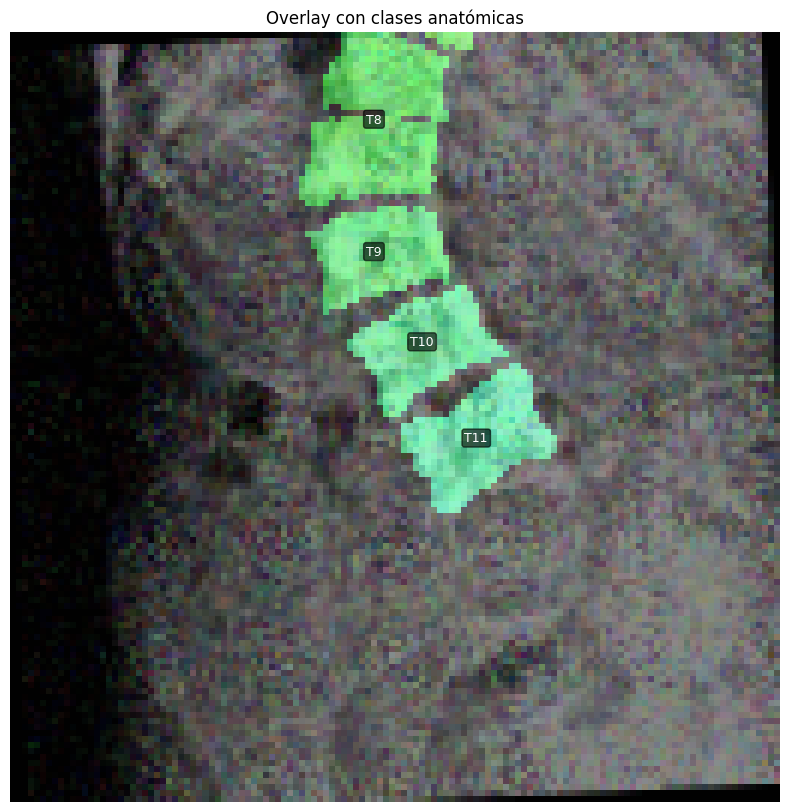

In [22]:
image, mask = train_dataset.__getitem__(10)
print(image[0].shape)
image = image[0].permute(1, 2, 0).cpu().numpy()
mask = mask[0].squeeze().cpu().numpy()
show_overlay_with_labels(image*STD+MEAN, mask, dic_labels)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..0.9999999964237213].


torch.Size([8, 3, 128, 128])


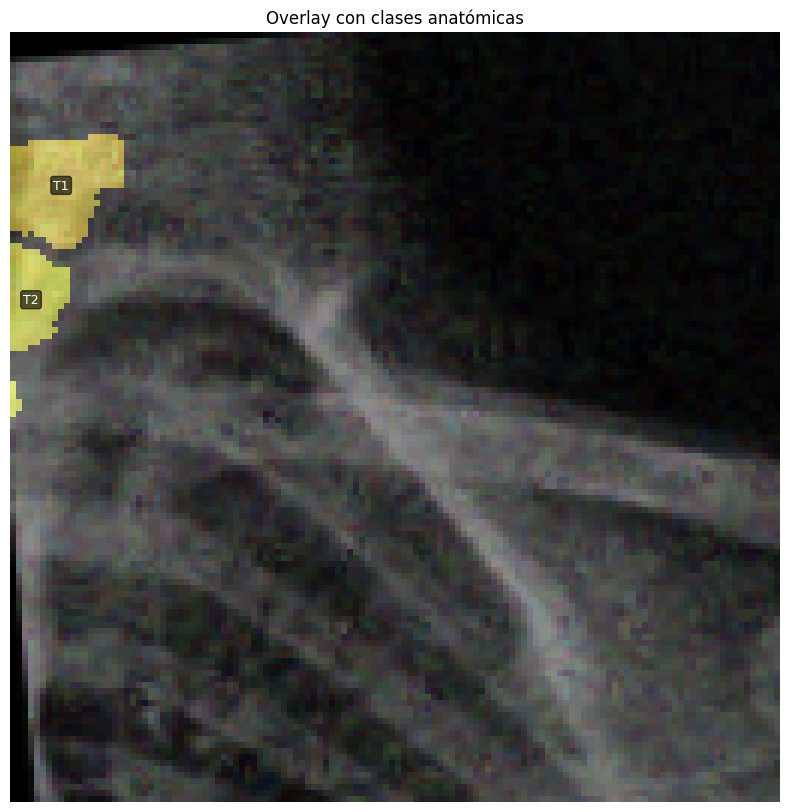

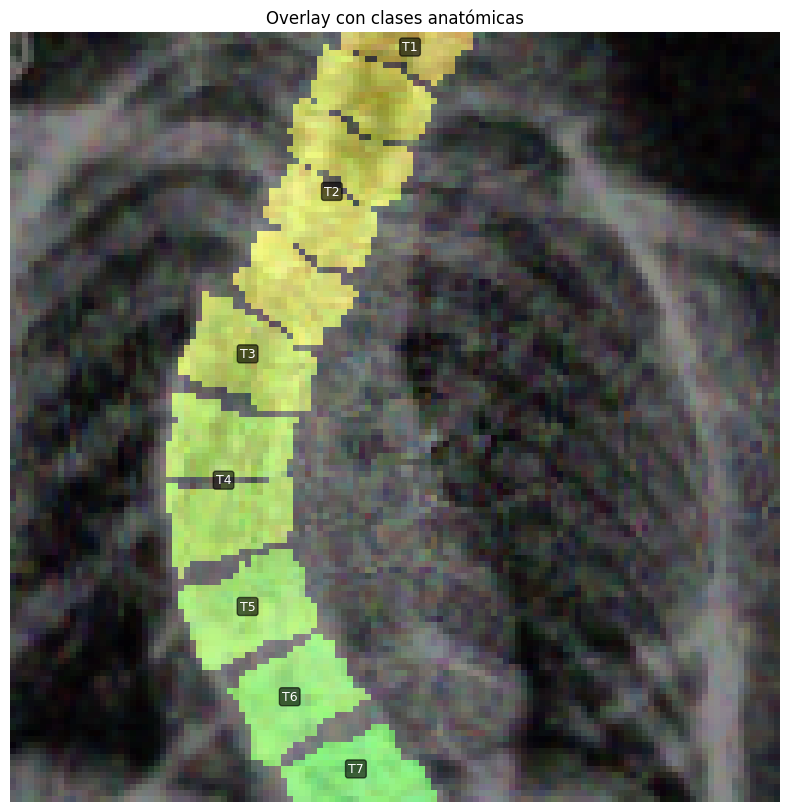

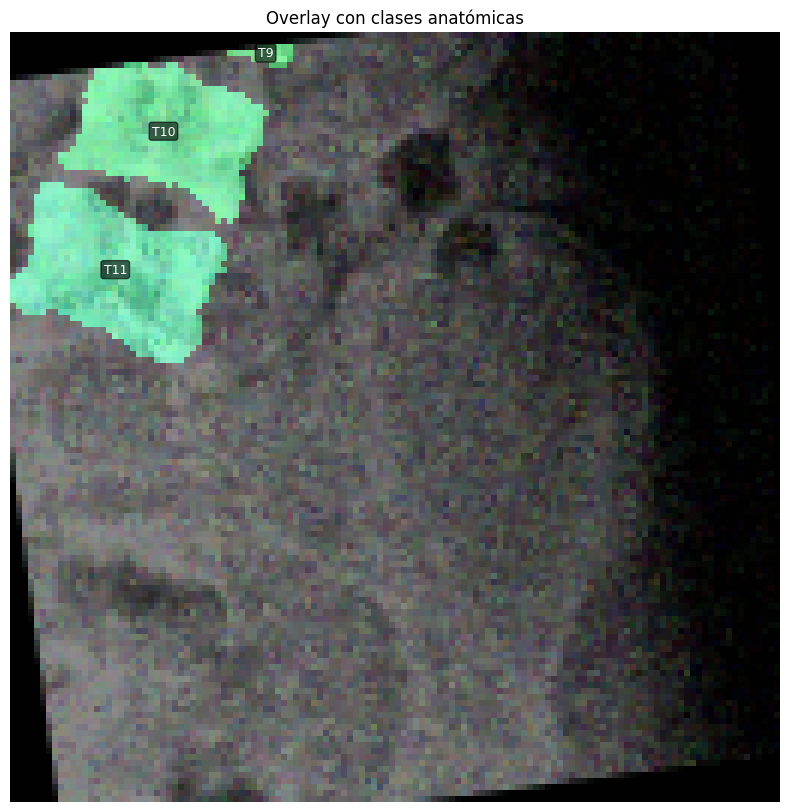

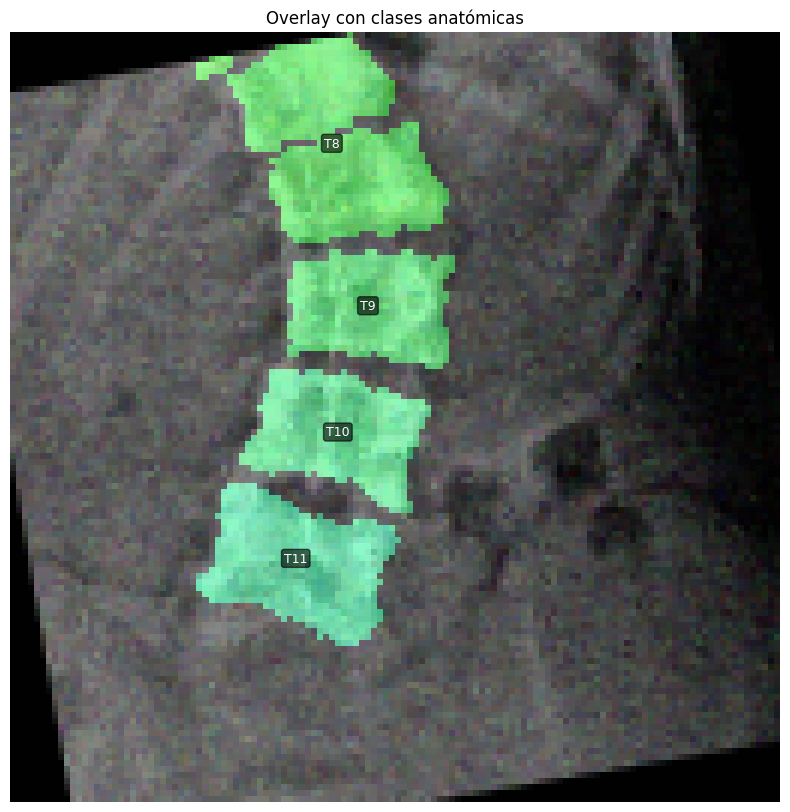

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..0.9999999964237213].


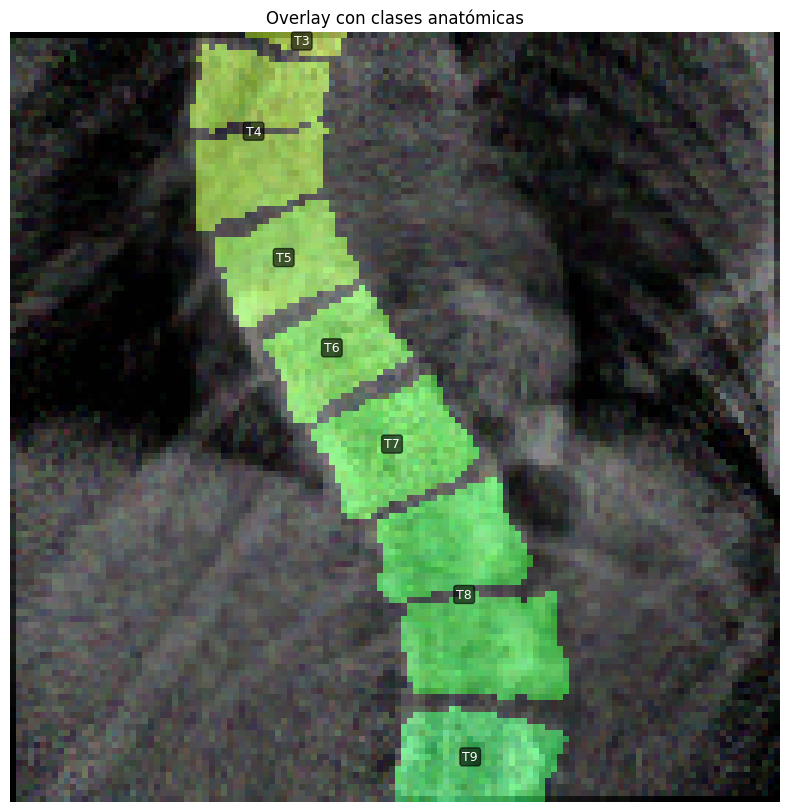

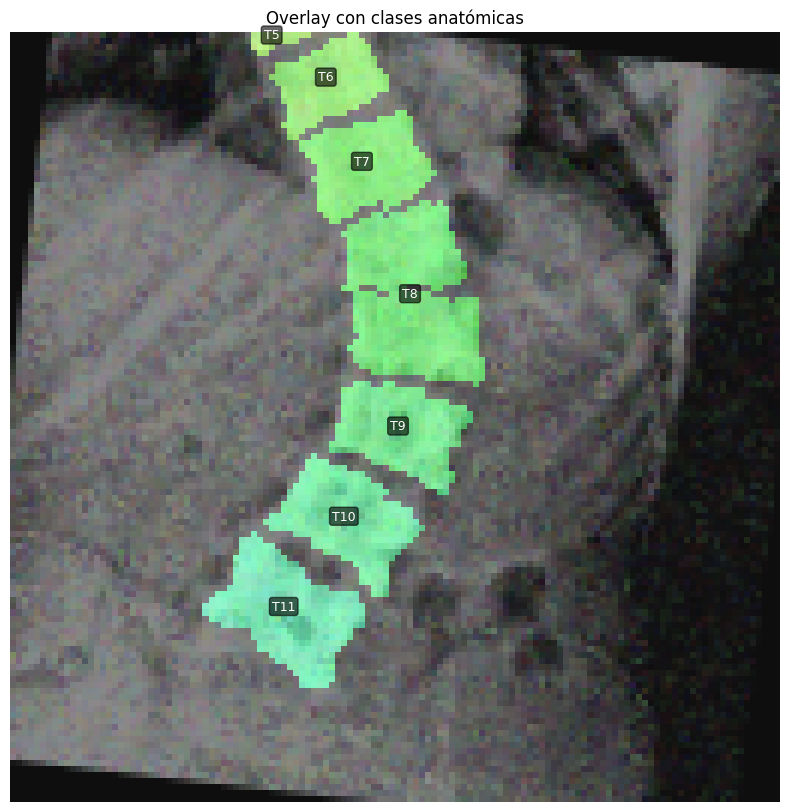

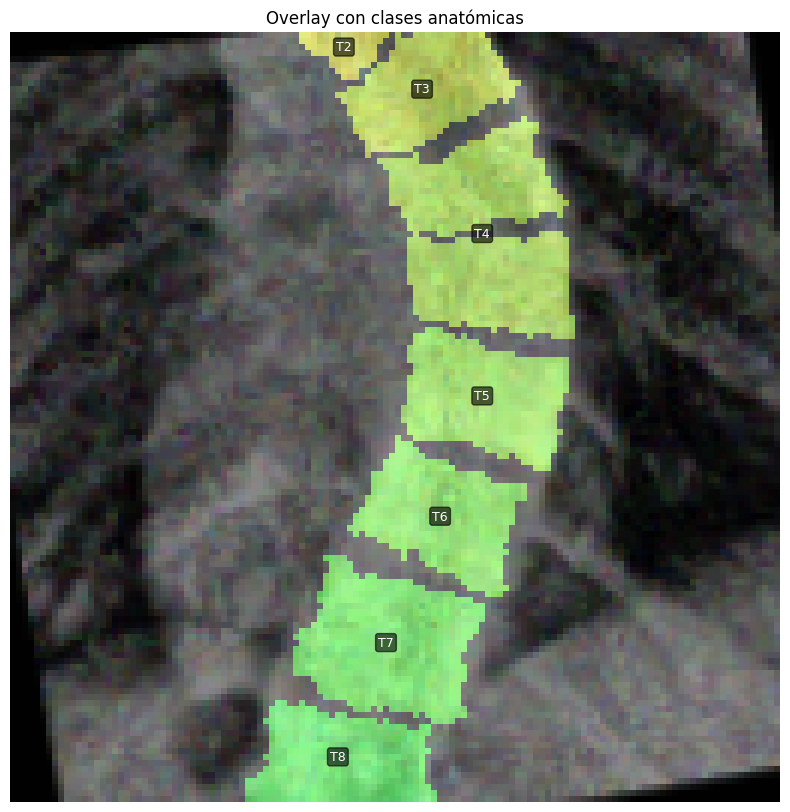

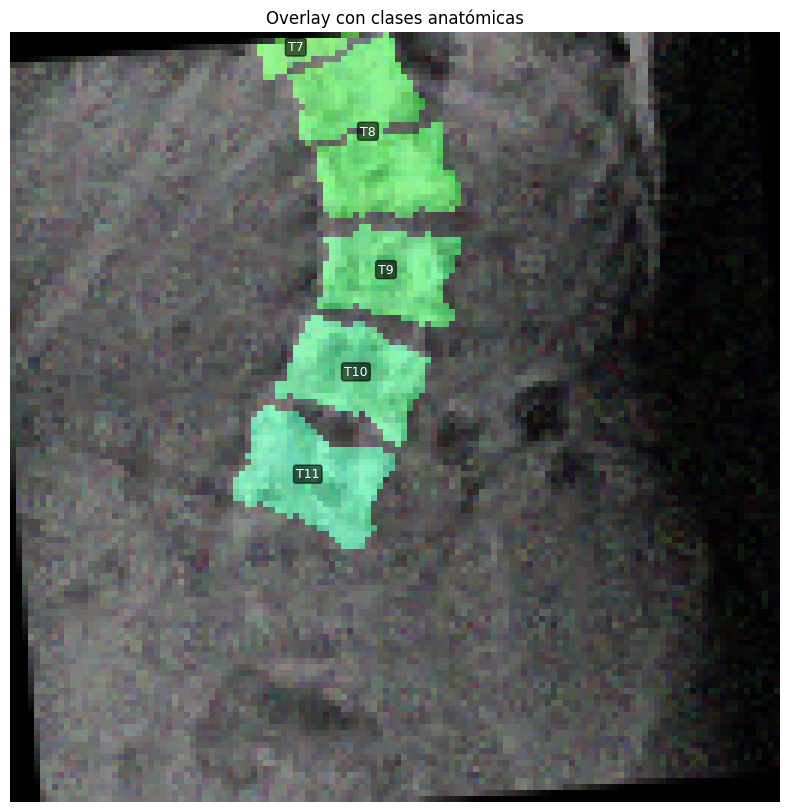

In [23]:
images, masks = train_dataset.__getitem__(10)
print(images.shape)
for image, mask in zip(images, masks):
    image = image.permute(1, 2, 0).cpu().numpy()
    mask = mask.squeeze().cpu().numpy()
    show_overlay_with_labels(image*STD+MEAN, mask, dic_labels)

In [24]:
if MODEL_NAME == 'Unet++':
    model = smp.UnetPlusPlus(
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=IN_CHANNELS,
        classes=NUM_CLASSES,
        decoder_attention_type = DECODER_ATTENTION,
        # pooling='max',
        # dropout = 0.5
    )
elif MODEL_NAME == 'Segformer':
    model = smp.Segformer(
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=IN_CHANNELS,
        classes=NUM_CLASSES,
        # aux_params={'classes':NUM_CLASSES, 'dropout':0.2}
    )
if MODEL_NAME == 'U-net':
    model = smp.Unet(
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=IN_CHANNELS,
        classes=NUM_CLASSES,
        decoder_attention_type = DECODER_ATTENTION,
        # pooling='max',
        # dropout = 0.5
    )

if MODEL_NAME == 'DeepLabV3+':
        model = smp.DeepLabV3Plus(
            encoder_name=ENCODER_NAME,
            encoder_weights=ENCODER_WEIGHTS,
            in_channels=IN_CHANNELS,
            classes=NUM_CLASSES,
            # decoder_attention_type = DECODER_ATTENTION,
            # pooling='max',
            # dropout = 0.5
        )

if DROPOUT is not None:
        model.segmentation_head = nn.Sequential(nn.Dropout2d(p=DROPOUT), model.segmentation_head)
model = model.to(device)

# Definir la función de pérdida y el optimizador
# Usamos BCEWithLogitsLoss porque el modelo no tiene una capa sigmoide final por defecto
# criterion = nn.BCEWithLogitsLoss()

if LOSS == 'CrossEntropyLoss':
    criterion = nn.CrossEntropyLoss()

elif LOSS == 'DiceLoss':
    # criterion =  DiceLoss()
    criterion = smp.losses.DiceLoss(mode='multiclass', from_logits=True)

elif LOSS == 'CombinedLoss':
    criterion = CombinedLoss()

elif LOSS == 'CombinedLossFocal':
        criterion = CombinedLossFocal()

elif LOSS == 'FocalLoss':
        criterion = smp.losses.FocalLoss(mode='multiclass', alpha=None, gamma=2.0)

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)

if not TRAIN_ENCODER:
    for param in model.encoder.parameters():
        param.requires_grad = False


# Definir el scheduler
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',    # 'min' porque quieres que la pérdida disminuya
    factor=0.1,    # Reduce el LR al 10% (multiplica por 0.1)
    patience=PATIENCE,    # Espera 5 épocas sin mejora antes de reducir
    threshold=1e-4, # Cambio mínimo para considerar que hay mejora
)

In [25]:
with mlflow.start_run(experiment_id=experiment.experiment_id):

    train_losses = np.zeros(NUM_EPOCHS)
    val_losses = np.zeros(NUM_EPOCHS)
    val_dice = np.zeros(NUM_EPOCHS)
    best_epoch = 0
    best_metric = 0
    for epoch in range(NUM_EPOCHS):
        model.train()
        train_loss = 0.0

        for images, masks in train_loader:
            B, N, C, H, W = images.shape
            images = images.view(B*N, C, H, W)
            masks = masks.view(B * N, H, W)

            images, masks = images.float().to(device), masks.long().to(device) # <--- Asegurar .long()


            # Forward pass
            optimizer.zero_grad()
            outputs = model(images)

            # pred_mask = torch.argmax(outputs, dim=1)
            loss = criterion(outputs, masks)
            # loss = criterion(pred_mask, masks)

            # Backward pass y optimización
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Validación simple
        model.eval()
        val_loss = 0.0
        dice_score_val = torch.empty((0,NUM_CLASSES))
        IoU_score_val = torch.empty((0,NUM_CLASSES))
        with torch.no_grad():
            for images, masks in val_loader:
                B, N, C, H, W = images.shape
                images = images.view(B*N, C, H, W)
                masks = masks.view(B * N, H, W).to(device)
                images, masks = images.float().to(device), masks.long().to(device)
                outputs = model(images)

                loss = criterion(outputs, masks)
                # loss = criterion(pred_mask, masks)
                val_loss += loss.item()

                pred_mask = torch.argmax(outputs, dim=1)

                dice, IoU = compute_metrics_torch(pred_mask.cpu(), masks.to(torch.long).cpu(), average=False)
                dice_score_val = torch.cat((dice_score_val, dice), dim=0)
                IoU_score_val = torch.cat((IoU_score_val, IoU), dim=0)
            dice_score_val = torch.mean(dice_score_val)
            IoU_score_val = torch.mean(IoU_score_val)

        if dice_score_val > best_metric and epoch > 15:
            best_metric = dice_score_val
            torch.save(model.state_dict(), os.path.join('modelos',MODEL_NAME+'.pth'))
            best_epoch = epoch + 1

        train_losses[epoch] = train_loss / len(train_loader)
        val_losses[epoch] = val_loss / len(val_loader)

        scheduler.step(val_loss/len(val_loader))
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f} | Val DICE Score: {dice_score_val:.4f} | Val IoU Score: {IoU_score_val:.4f}")

    print('Best Epoch: ', best_epoch, ' Best metric: ', best_metric)

    mlflow.log_params({'best_epoch': best_epoch, 'EPOCHS': NUM_EPOCHS, 'SEED': SEED, 'BATCH_SIZE': BATCH_SIZE, 'PATIENCE': PATIENCE, 'LR': LR, 'WD': WD,'CROP_RATIO':CROP_RATIO, 'STRIDE_RATIO': STRIDE_RATIO ,'PATCH_SIZE': PATCH_SIZE,'NUM_PATCHES':NUM_PATCHES , 'IN_CHANNELS': IN_CHANNELS, 'TRAIN_ENCODER': TRAIN_ENCODER, 'CENTER_IMAGES': CENTER_IMAGES, 'CLAHE': CLAHE, 'PERSPECTIVE': PERSPECTIVE ,'LOSS': LOSS, 'ENCODER_NAME': ENCODER_NAME, 'DECODER_ATTENTION': DECODER_ATTENTION, 'DROPOUT': DROPOUT})

    mlflow.log_metric(f"val_mean_dice_score", dice_score_val)
    mlflow.log_metric(f"best_val_dice_score", dice_score_val)
    mlflow.pytorch.log_model(model, name=MODEL_NAME)

    for step, value in enumerate(train_losses):
        mlflow.log_metric('train_hist', value, step=step)
    for step, value in enumerate(val_losses):
        mlflow.log_metric('val_hist', value, step=step)


Epoch 1/50 | Train Loss: 1.4106 | Val Loss: 0.7803 | Val DICE Score: 0.6261 | Val IoU Score: 0.6213
Epoch 2/50 | Train Loss: 0.7323 | Val Loss: 0.6792 | Val DICE Score: 0.6506 | Val IoU Score: 0.6457
Epoch 3/50 | Train Loss: 0.6868 | Val Loss: 0.6376 | Val DICE Score: 0.6313 | Val IoU Score: 0.6247
Epoch 4/50 | Train Loss: 0.6434 | Val Loss: 0.6263 | Val DICE Score: 0.6223 | Val IoU Score: 0.6148
Epoch 5/50 | Train Loss: 0.6087 | Val Loss: 0.6085 | Val DICE Score: 0.5575 | Val IoU Score: 0.5488
Epoch 6/50 | Train Loss: 0.6205 | Val Loss: 0.5693 | Val DICE Score: 0.5631 | Val IoU Score: 0.5519
Epoch 7/50 | Train Loss: 0.5994 | Val Loss: 0.5595 | Val DICE Score: 0.5864 | Val IoU Score: 0.5739
Epoch 8/50 | Train Loss: 0.5836 | Val Loss: 0.5589 | Val DICE Score: 0.5855 | Val IoU Score: 0.5721
Epoch 9/50 | Train Loss: 0.5638 | Val Loss: 0.5915 | Val DICE Score: 0.5908 | Val IoU Score: 0.5766
Epoch 10/50 | Train Loss: 0.5730 | Val Loss: 0.5700 | Val DICE Score: 0.5685 | Val IoU Score: 0.5565

2026/05/14 15:21:48 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/14 15:21:48 WARNING mlflow.utils.requirements_utils: Found torch version (2.7.0+cu118) contains a local version label (+cu118). MLflow logged a pip requirement for this package as 'torch==2.7.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/14 15:22:00 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_e

🏃 View run efficient-bass-93 at: https://dbc-250dea69-0463.cloud.databricks.com/ml/experiments/1784634680320993/runs/87b11e35ba724405b8725a72c9627c44
🧪 View experiment at: https://dbc-250dea69-0463.cloud.databricks.com/ml/experiments/1784634680320993


In [26]:
model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
model.eval()

UnetPlusPlus(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tru

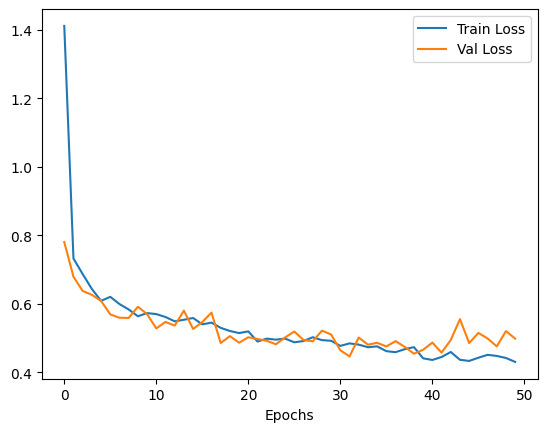

In [27]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel('Epochs')
plt.legend()

In [77]:
import torch
import numpy as np
import torch.nn.functional as F
import cv2
from tqdm import tqdm

def create_gaussian_window(patch_size, sigma=1.0):
    """
    Crea una matriz de pesos 2D con una distribución Gaussiana.
    Da más peso al centro del parche y menos a los bordes.
    """
    tmp = np.zeros((patch_size, patch_size))
    # Crear un centro
    center = patch_size // 2

    # Generar grid
    x, y = np.ogrid[:patch_size, :patch_size]

    # Formula gaussiana simplificada
    d2 = (x - center)**2 + (y - center)**2
    # El valor 2*sigma^2 controla qué tan rápido cae el peso hacia los bordes
    std_squared = 2 * (sigma * patch_size / 2)**2
    window = np.exp(-d2 / std_squared)

    # Normalizar para que el valor máximo sea 1.0 (opcional, ayuda a la estabilidad)
    window = window / np.max(window)

    # Convertir a tensor de PyTorch para usar en GPU
    return torch.from_numpy(window).float()

def patch_based_inference(model, image, patch_size, stride, num_classes, device):
    """
    Realiza inferencia en una imagen grande usando ventanas deslizantes con solape y suavizado.

    image: Tensor [C, H_large, W_large] pre-procesado (normalizado).
    """
    model.eval()
    H_large, W_large, _ = image.shape

    # 1. Crear tensores vacíos en la GPU para acumular las predicciones y los pesos
    # Forma: [Num_Clases, H, W]
    # Usamos floats para acumular probabilidades
    accumulated_predictions = torch.zeros((num_classes, H_large, W_large)).to(device)
    accumulated_weights = torch.zeros((H_large, W_large)).to(device)

    # 2. Crear la ventana Gaussiana de suavizado
    gaussian_window = create_gaussian_window(patch_size, sigma=1.0).to(device)
    # gaussian_window = torch.from_numpy(gkern(l=PATCH_SIZE, sig=1.0)).float().to(device)

    # 3. Bucle de Ventana Deslizante (Sliding Window)
    # Calculamos cuántos pasos dar en y y x
    y_steps = range(0, H_large - patch_size + 1, stride)
    x_steps = range(0, W_large - patch_size + 1, stride)

    # print(len(x_steps), W_large, patch_size,stride)

    # Asegurar que cubrimos el borde final si el stride no encaja perfecto
    # (Añadimos el último parche posible si no termina exactamente en el borde)

    if y_steps[-1] + patch_size < H_large:
        y_steps = list(y_steps) + [H_large - patch_size]
    if x_steps[-1] + patch_size < W_large:
        x_steps = list(x_steps) + [W_large - patch_size]

    # print(len(x_steps), W_large, patch_size,stride)

    with torch.no_grad():
        # Usamos tqdm para ver progreso ya que esto tarda
        # image = (image / 255.0 - MEAN) / STD
        for y in tqdm(y_steps, desc="Procesando filas"):
            for x in x_steps:
                # Extaer el parche de la imagen grande

                # print(image_norm.shape)
                # HWC a CHW y convertir a Tensor
                patch = image[y:y+patch_size, x:x+patch_size, :]
                patch = cv2.resize(patch, (PATCH_SIZE, PATCH_SIZE))

                # transform = torchvision.transforms.ToTensor()
                # patch = transform(patch)
                patch = torch.from_numpy(patch)
                patch = patch.permute(2, 0, 1)
                # print(patch.shape)

                # Añadir dimensión de batch -> [1, C, H_patch, W_patch]
                patch_batch = patch.float().unsqueeze(0).to(device)
                # print(patch_batch.shape)

                # Inferencia del modelo (Logits) -> [1, 18, H_patch, W_patch]
                # trans_image = val_transform(image=image)['image'].float().unsqueeze(0).to(device)
                logits = model(patch_batch)
                pred_mask_patch = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

                # plt.figure()
                # plt.imshow((patch.permute(1, 2, 0).cpu().numpy())*STD + MEAN)
                # plt.imshow(patch.permute(1, 2, 0).cpu().numpy())
                # plt.figure()
                # plt.imshow(pred_mask_patch)
                # show_overlay_with_labels(patch.permute(1, 2, 0).cpu().numpy(), pred_mask_patch, dic_labels) # Plot patches preds
                # print(np.max(pred_mask_patch), np.min(pred_mask_patch))

                # Convertir logits a probabilidades (Softmax)
                # Esto es crucial para la fusión ponderada
                # probs = F.softmax(logits, dim=1).squeeze(0) # -> [18, H_patch, W_patch]
                probs = F.softmax(logits, dim=1) # -> [1, 18, H_patch, W_patch]
                probs = F.interpolate(probs, size=(patch_size, patch_size), mode='bilinear', align_corners=False).squeeze(0)

                # 4. Aplicar Fusión Ponderada en la GPU
                # Multiplicar las probabilidades de cada clase por el peso Gaussiano
                weighted_probs = probs * gaussian_window.unsqueeze(0) # Broadcatsing de canales

                # Acumular en la imagen grande
                accumulated_predictions[:, y:y+patch_size, x:x+patch_size] += weighted_probs

                # Acumular los pesos aplicados en esa zona para luego normalizar
                accumulated_weights[y:y+patch_size, x:x+patch_size] += gaussian_window

    # 5. Normalización Final
    # Dividir las probabilidades acumuladas por la suma de pesos en cada píxel
    # Usamos una pequeña constante (1e-5) para evitar división por cero en bordes extremos
    final_segmentation_probs = accumulated_predictions / (accumulated_weights.unsqueeze(0) + 1e-5)

    return final_segmentation_probs


idx = 5
img_path = test_img[idx]
mask_path = test_mask[idx]

image = cv2.imread(img_path, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
image = test_transforms(image=image)['image']

x, y, _ = image.shape
min_dim = min(x, y)
patch_size = np.round(np.sqrt(0.5*x*y)).astype(int)
patch_size = min_dim if patch_size > min_dim else patch_size
stride = np.round(patch_size/10).astype(int)
print(f'Patch Size: {patch_size} | Stride: {stride}')

# 4. Parímetros de Inferencia
# STRIDE define el solapamiento.
# Si Stride == Patch_Size -> No hay solape (Malos bordes)
# Si Stride == Patch_Size // 2 -> 50% solape (Buen balance velocidad/calidad)

print(f"Resolución imagen original: {image.shape}")

# 5. Ejecutar Inferencia Patch-Based
probs_map = patch_based_inference(
    model,
    image,
    patch_size,
    stride,
    NUM_CLASSES,
    device
)

# 6. Post-procesamiento
# El resultado es [18, H, W] con probabilidades.
# Tomamos el ARGMAX para obtener la clase final por píxel
final_mask = torch.argmax(probs_map, dim=0).cpu().numpy() # -> [H, W] con valores 0-17

print(f"Forma de máscara final: {final_mask.shape}", f"Forma imagen original: {image.shape}")

# 7. Guardar o visualizar
# (Necesitarás un mapeo de color para visualizar 18 clases)
# cv2.imwrite("segmentacion_final.png", final_mask)

Patch Size: 150 | Stride: 15
Resolución imagen original: (595, 150, 3)


Procesando filas: 100%|██████████| 31/31 [00:00<00:00, 56.06it/s]

Forma de máscara final: (595, 150) Forma imagen original: (595, 150, 3)


Dice: 0.4117 | IoU: 0.3326


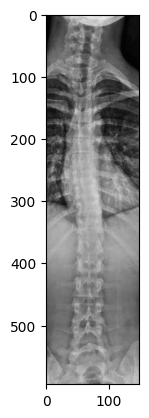

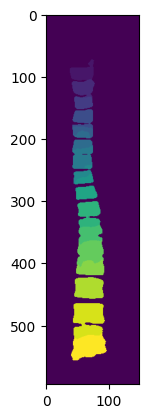

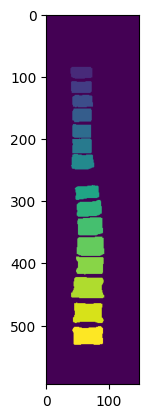

In [78]:
plt.figure()
plt.imshow(cv2.resize(image*STD+MEAN,(final_mask.shape[1],final_mask.shape[0])))
plt.figure()
plt.imshow(final_mask)
plt.figure()
plt.imshow(cv2.resize(mask,(final_mask.shape[1],final_mask.shape[0])))

dice, IoU = compute_metrics(final_mask, mask)
print(f'Dice: {dice:.4f} | IoU: {IoU:.4f}')

In [30]:
print(create_gaussian_window(5))

tensor([[0.5273, 0.6703, 0.7261, 0.6703, 0.5273],
        [0.6703, 0.8521, 0.9231, 0.8521, 0.6703],
        [0.7261, 0.9231, 1.0000, 0.9231, 0.7261],
        [0.6703, 0.8521, 0.9231, 0.8521, 0.6703],
        [0.5273, 0.6703, 0.7261, 0.6703, 0.5273]])


In [31]:
def gkern(l=5, sig=1.):
    """\
    creates gaussian kernel with side length `l` and a sigma of `sig`
    """
    ax = np.linspace(-(l - 1) / 2., (l - 1) / 2., l)
    gauss = np.exp(-0.5 * np.square(ax) / np.square(sig))
    kernel = np.outer(gauss, gauss)
    return kernel

In [32]:
gkern(l=5, sig=1.)

array([[0.01831564, 0.082085  , 0.13533528, 0.082085  , 0.01831564],
       [0.082085  , 0.36787944, 0.60653066, 0.36787944, 0.082085  ],
       [0.13533528, 0.60653066, 1.        , 0.60653066, 0.13533528],
       [0.082085  , 0.36787944, 0.60653066, 0.36787944, 0.082085  ],
       [0.01831564, 0.082085  , 0.13533528, 0.082085  , 0.01831564]])

In [33]:
final_mask

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(2779, 1160))

In [34]:
dice_score_test = np.zeros(NUM_CLASSES)
model.eval()
with torch.no_grad():
    for idx in range(len(test_dataset)):
            image, mask = test_dataset[idx]
            # print(image.shape)
            N, C, H, W = image.shape
            image, mask = image.float().to(device), mask.long().to(device)
            outputs = model(image)
            pred_mask = torch.argmax(outputs, dim=1).squeeze(0).cpu()
            # print(image.shape)
            for image, mask, pred_mask in zip(image, mask, pred_mask):
                # print(image.shape)
                dice, IoU = compute_metrics(pred_mask.cpu().numpy(), mask.to(torch.long).cpu().numpy(), average=False)
            dice_score_test += dice

dice_score_test = dice_score_test/len(test_dataset)

for i,j in zip(dic_labels['mascara_multiclase_id_png'], dice_score_test):
    print(dic_labels['mascara_multiclase_id_png'][i],f'{j:.4f}')

background 0.9670
T1 0.8665
T2 0.5517
T3 0.6439
T4 0.5782
T5 0.4751
T6 0.5816
T7 0.5528
T8 0.5848
T9 0.5730
T10 0.4432
T11 0.5075
T12 0.6244
L1 0.5988
L2 0.7756
L3 0.7396
L4 0.8569
L5 0.8998


Text(0, 0.5, 'mean DICE score')

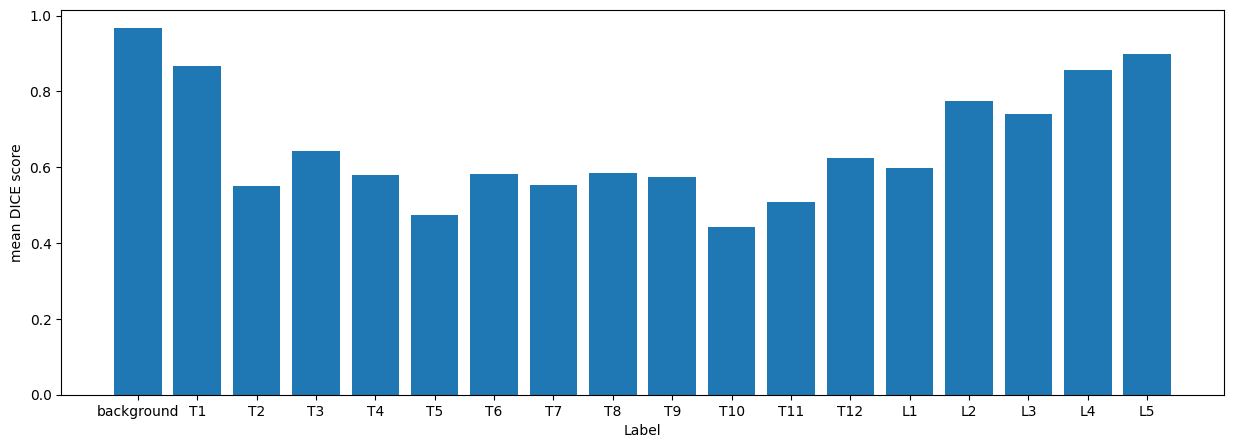

In [35]:
x = range(len(dice_score_test))
f, ax = plt.subplots()
ax.bar(x, dice_score_test)
ax.set_xticks(x)
labels = [dic_labels['mascara_multiclase_id_png'][i] for i  in dic_labels['mascara_multiclase_id_png']]
ax.set_xticklabels(labels)
ax.figure.set_size_inches(15, 5)
ax.set_xlabel('Label')
ax.set_ylabel('mean DICE score')

In [36]:
dice_score_test = torch.zeros(NUM_PATCHES, NUM_CLASSES)
model.eval()
with torch.no_grad():
    for idx in range(len(test_dataset)):
            image, mask = test_dataset[idx]
            image, mask = image.float().to(device), mask.long().to(device)
            outputs = model(image)
            pred_mask = torch.argmax(outputs, dim=1).cpu()
            dice, IoU = compute_metrics_torch(pred_mask.cpu(), mask.to(torch.long).cpu(), average=False)
            dice_score_test += dice.squeeze(0)

dice_score_test = dice_score_test/len(test_dataset)
print(f'Mean Dice Score: {torch.mean(dice_score_test):.4f}')


for i,j in zip(dic_labels['mascara_multiclase_id_png'], torch.mean(dice_score_test, dim=0)):
    print(dic_labels['mascara_multiclase_id_png'][i],f'{j:.4f}')

Mean Dice Score: 0.6473
background 0.9645
T1 0.8998
T2 0.6845
T3 0.6979
T4 0.6388
T5 0.5968
T6 0.5886
T7 0.5491
T8 0.5107
T9 0.4811
T10 0.4186
T11 0.4599
T12 0.4923
L1 0.5947
L2 0.6762
L3 0.7229
L4 0.8122
L5 0.8621


In [37]:
dice_score_test = torch.empty((0,18))
with torch.no_grad():
        for images, masks in test_loader:
            B, N, C, H, W = images.shape
            images = images.view(B*N, C, H, W)
            masks = masks.view(B * N, H, W)
            images, masks = images.float().to(device), masks.long().to(device)
            # print(images.shape, masks.shape)
            outputs = model(images)
            pred_mask = torch.argmax(outputs, dim=1)
            dice, IoU = compute_metrics_torch(pred_mask.cpu(), masks.to(torch.long).cpu(), average=False)
            # print(dice.shape)
            dice_score_test = torch.cat((dice_score_test, dice), dim=0)

print(f'Mean Dice Score: {torch.mean(dice_score_test):.4f}')
mean_dice_score = torch.mean(dice_score_test, dim=0).numpy()

for i,j in zip(dic_labels['mascara_multiclase_id_png'], mean_dice_score):
    print(dic_labels['mascara_multiclase_id_png'][i],f'{j:.4f}')

Mean Dice Score: 0.6272
background 0.9654
T1 0.9065
T2 0.6836
T3 0.6871
T4 0.5925
T5 0.5589
T6 0.5484
T7 0.5282
T8 0.4883
T9 0.4388
T10 0.3730
T11 0.4360
T12 0.4799
L1 0.5730
L2 0.6531
L3 0.6684
L4 0.8078
L5 0.9007


In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

def build_color_map_from_json(label_dict):
    color_map_raw = label_dict["mascara_multiclase_color_rgb"]
    return {int(k): tuple(v) for k, v in color_map_raw.items()}

def build_label_map_from_json(label_dict):
    label_map_raw = label_dict["mascara_multiclase_id_png"]
    return {int(k): v for k, v in label_map_raw.items()}

def create_color_overlay(mask, color_map):
    h, w = mask.shape
    overlay = np.zeros((h, w, 3), dtype=np.uint8)

    for class_id, color in color_map.items():
        overlay[mask == class_id] = color

    return overlay

def get_class_centroid(mask, class_id):
    ys, xs = np.where(mask == class_id)
    if len(xs) == 0 or len(ys) == 0:
        return None
    cx = int(np.mean(xs))
    cy = int(np.mean(ys))
    return cx, cy

def draw_labels_on_axis(ax, mask, label_map, min_pixels=20):
    unique_vals = np.unique(mask)

    for class_id in unique_vals:
        if class_id == 0:
            continue

        region = (mask == class_id)
        if region.sum() < min_pixels:
            continue

        centroid = get_class_centroid(mask, class_id)
        if centroid is None:
            continue

        x, y = centroid
        class_name = label_map.get(int(class_id), str(class_id))

        ax.text(
            x, y, class_name,
            fontsize=9,
            ha="center",
            va="center",
            color="white",
            bbox=dict(facecolor="black", alpha=0.6, boxstyle="round,pad=0.2")
        )

def show_gt_vs_pred_with_labels(
    model,
    dataset,
    device,
    idx,
    patch_idx,
    label_dict,
    alpha=0.45,
    min_pixels=20
):
    model.eval()

    label_map = build_label_map_from_json(label_dict)
    color_map = build_color_map_from_json(label_dict)

    print(dataset.__getpath__(idx))

    sample = dataset[idx]
    if sample is None:
        print(f"No se pudo cargar la muestra {idx}")
        return

    image_tensor, gt_mask = sample
    image_tensor = image_tensor[patch_idx]
    gt_mask = gt_mask[patch_idx]
    image_batch = image_tensor.float().unsqueeze(0).to(device)

    with torch.no_grad():
        if device.type == "cuda":
            with torch.amp.autocast(device_type="cuda"):
                logits = model(image_batch)
        else:
            logits = model(image_batch)
    # print(logits)
    pred_mask = torch.argmax(logits, dim=1).squeeze(0).cpu()

    # dice_score = DiceScore(num_classes=NUM_CLASSES, average="none", input_format='index')
    # dice_score_mean = DiceScore(num_classes=NUM_CLASSES, average="macro", input_format='index')
    # dice_score_mean = dice_score_mean(pred_mask, gt_mask.to(torch.long).cpu())
    # sample_dice = dice_score(pred_mask, gt_mask.to(torch.long).cpu())

    pred_mask = pred_mask.numpy()
    gt_mask = gt_mask.cpu().numpy()

    sample_dice, sample_IoU = compute_metrics(pred_mask, gt_mask, average=False)
    dice_score_mean, IoU_score_mean = compute_metrics(pred_mask, gt_mask)

    image = image_tensor.cpu().numpy()
    if image.shape[0] == 1:
        image = image.squeeze(0)
        image_cmap = "gray"
    else:
        image = np.transpose(image, (1, 2, 0))
        image_cmap = None

    # image = np.clip(image, 0, 1)
    image = image*STD+MEAN
    gt_overlay = create_color_overlay(gt_mask, color_map)
    pred_overlay = create_color_overlay(pred_mask, color_map)

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    axes[0].imshow(image, cmap=image_cmap)
    axes[0].set_title("Imagen")
    axes[0].axis("off")

    axes[1].imshow(image, cmap=image_cmap)
    axes[1].imshow(gt_overlay, alpha=alpha)
    draw_labels_on_axis(axes[1], gt_mask, label_map, min_pixels=min_pixels)
    axes[1].set_title("Ground Truth con etiquetas")
    axes[1].axis("off")

    axes[2].imshow(image, cmap=image_cmap)
    axes[2].imshow(pred_overlay, alpha=alpha)
    draw_labels_on_axis(axes[2], pred_mask, label_map, min_pixels=min_pixels)
    axes[2].set_title("Predicción con etiquetas")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    gt_classes = np.unique(gt_mask)
    pred_classes = np.unique(pred_mask)
    # print(f'Dice Score promedio: {dice_score_mean.numpy():.4f}')
    print(f'Dice Score promedio: {dice_score_mean:.4f}')
    print('Dice Score por clase: ')
    for i,j in zip(dic_labels['mascara_multiclase_id_png'], sample_dice):
        # print(dic_labels['mascara_multiclase_id_png'][i],j.numpy())
        print(dic_labels['mascara_multiclase_id_png'][i],f'{j:.4f}')
    # print(f"DICE Score: {sample_dice:.4f}")

    # print("\nClases presentes en Ground Truth:")
    # for c in gt_classes:
    #     name = label_map.get(int(c), f"Clase {c}")
    #     print(f"  {c} → {name}")
    #
    # print("\nClases presentes en Predicción:")
    # for c in pred_classes:
    #     name = label_map.get(int(c), f"Clase {c}")
    #     print(f"  {c} → {name}")

2
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_53.jpg


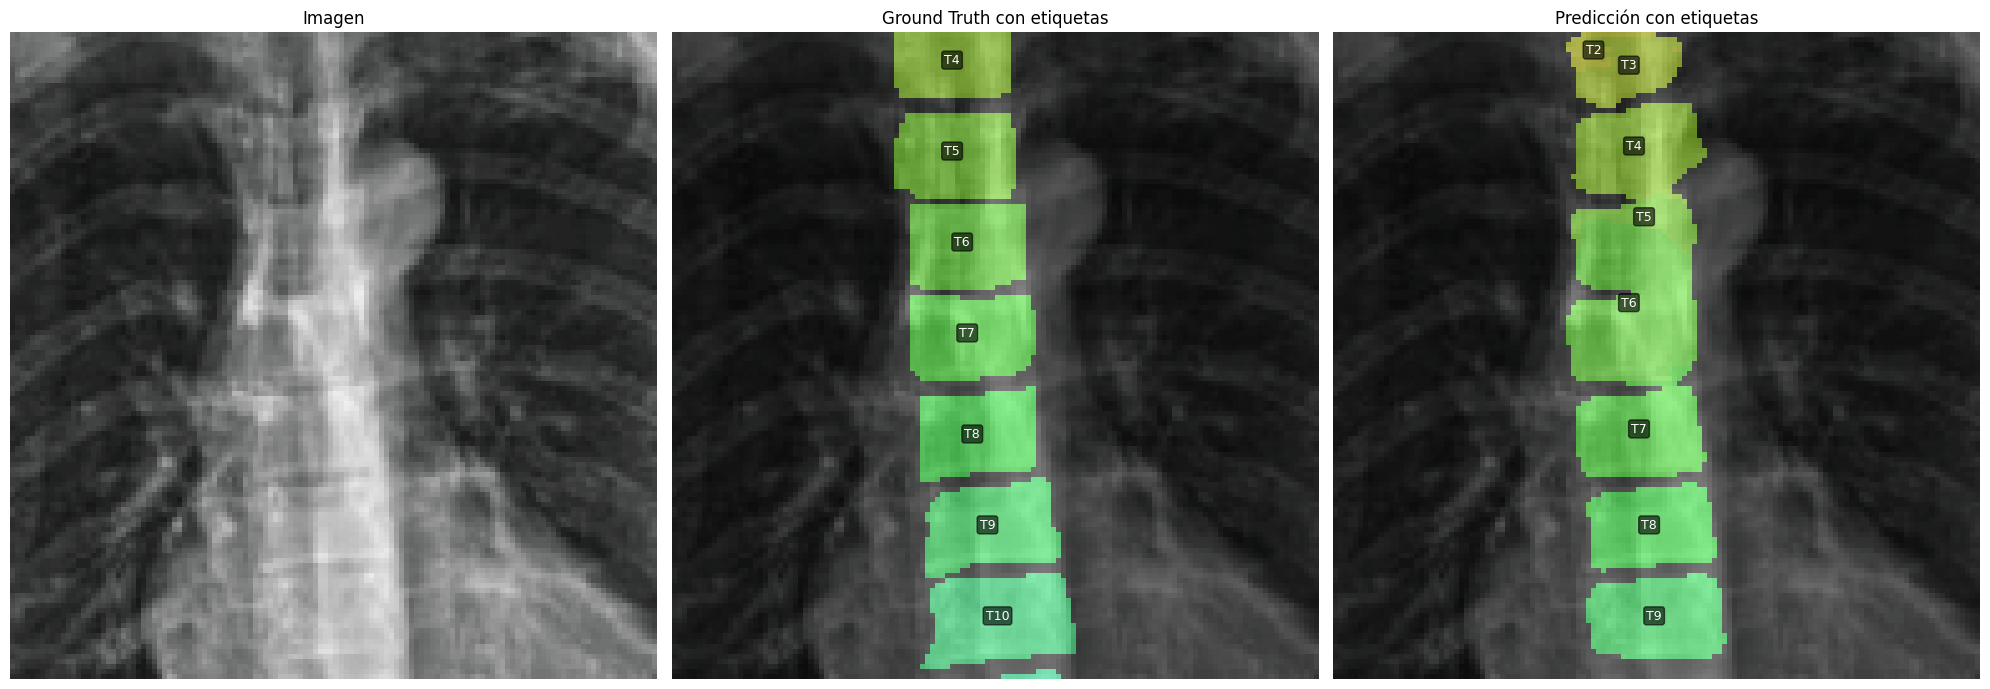

Dice Score promedio: 0.4709
Dice Score por clase: 
background 0.9801
T1 1.0000
T2 0.0000
T3 0.0000
T4 0.0000
T5 0.0115
T6 0.4717
T7 0.0123
T8 0.0000
T9 0.0000
T10 0.0000
T11 0.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
2
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_53.jpg


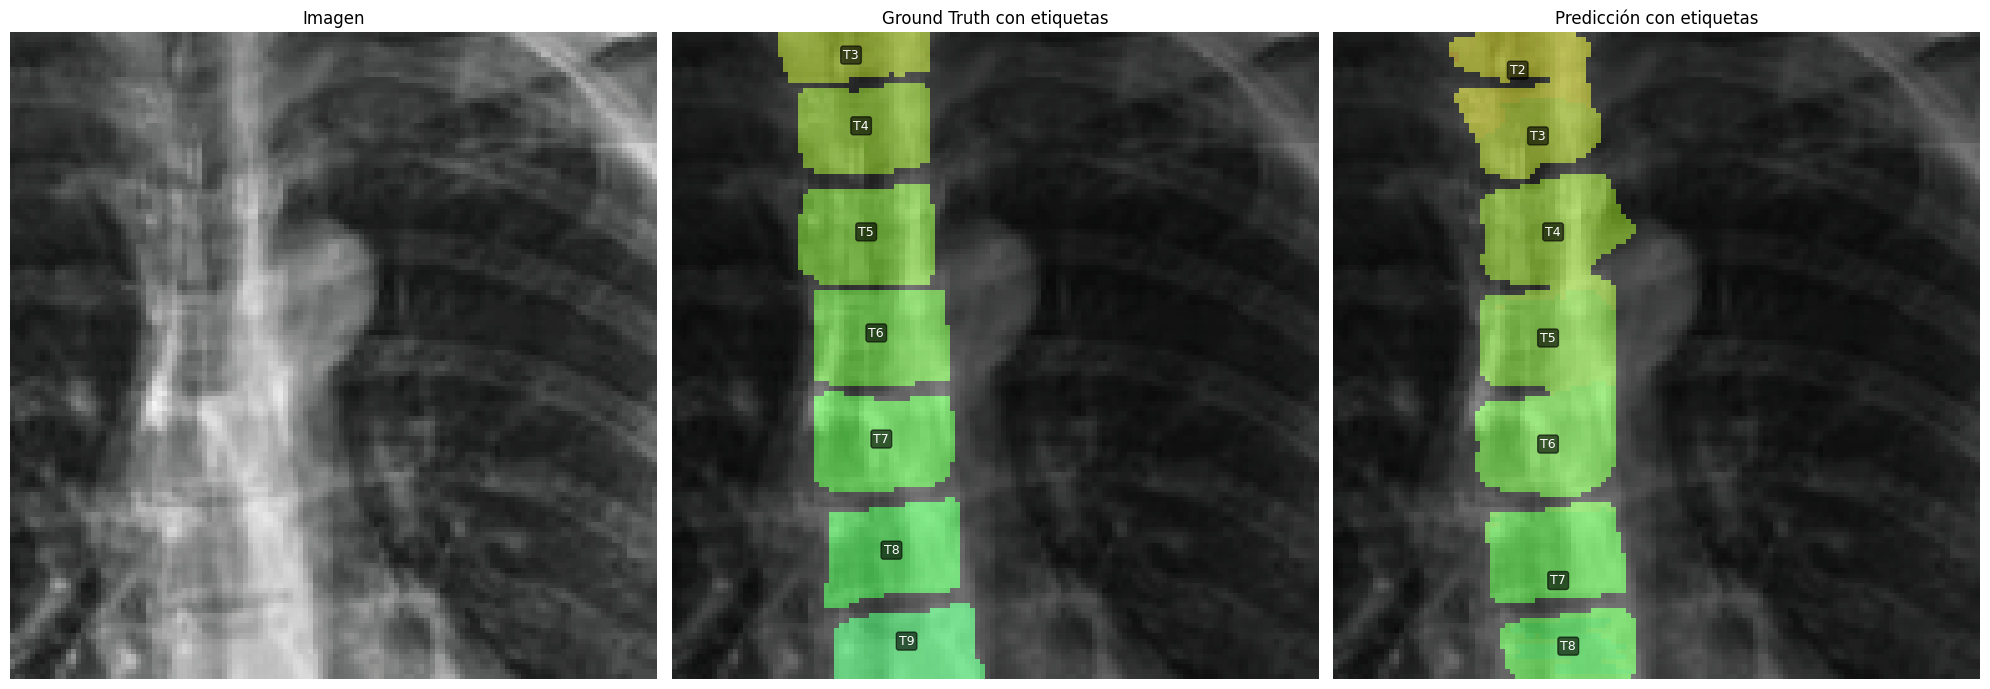

Dice Score promedio: 0.4988
Dice Score por clase: 
background 0.9783
T1 0.0000
T2 0.0000
T3 0.0000
T4 0.0000
T5 0.0000
T6 0.0000
T7 0.0000
T8 0.0000
T9 0.0000
T10 1.0000
T11 1.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
2
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_53.jpg


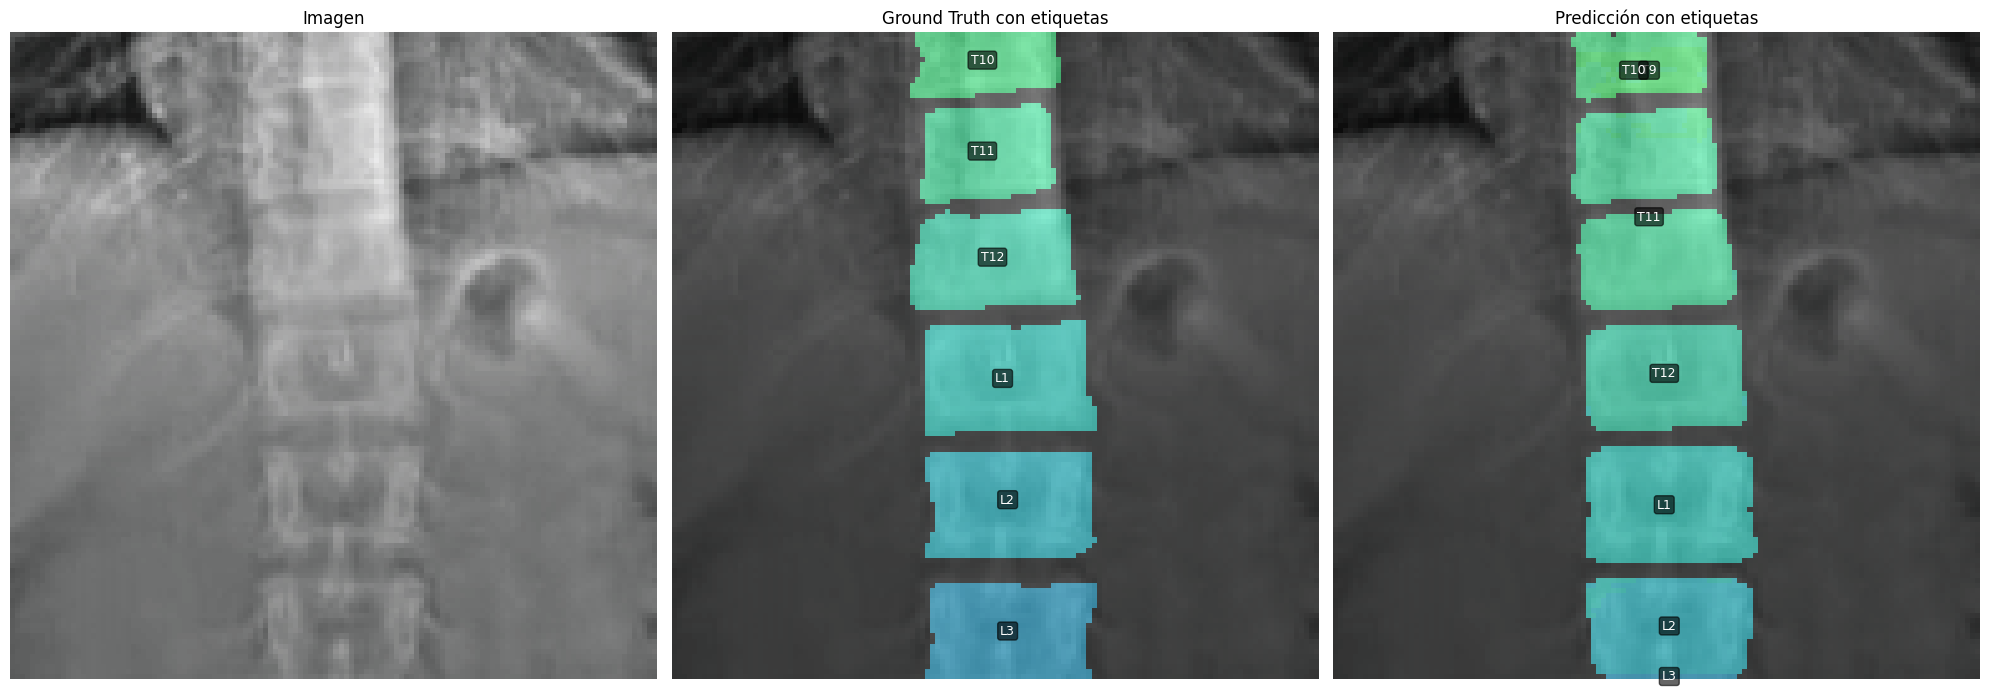

Dice Score promedio: 0.6759
Dice Score por clase: 
background 0.9860
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 1.0000
T8 1.0000
T9 0.0000
T10 0.5501
T11 0.5387
T12 0.0033
L1 0.0054
L2 0.0000
L3 0.0835
L4 1.0000
L5 1.0000
2
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_53.jpg


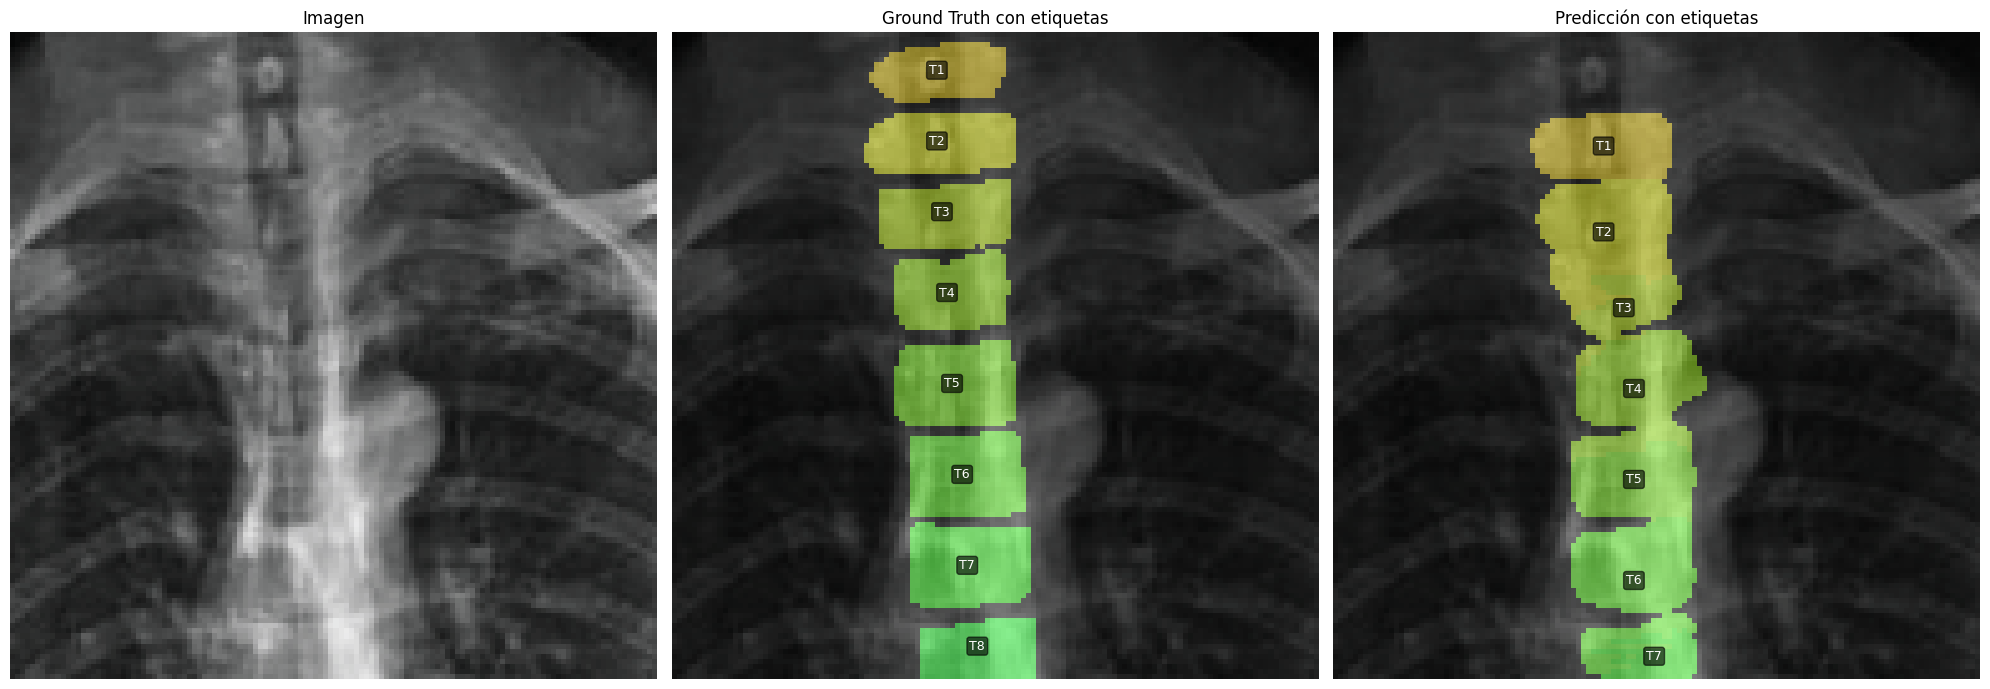

Dice Score promedio: 0.5541
Dice Score por clase: 
background 0.9735
T1 0.0000
T2 0.0000
T3 0.0000
T4 0.0000
T5 0.0000
T6 0.0000
T7 0.0000
T8 0.0000
T9 1.0000
T10 1.0000
T11 1.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
2
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_53.jpg


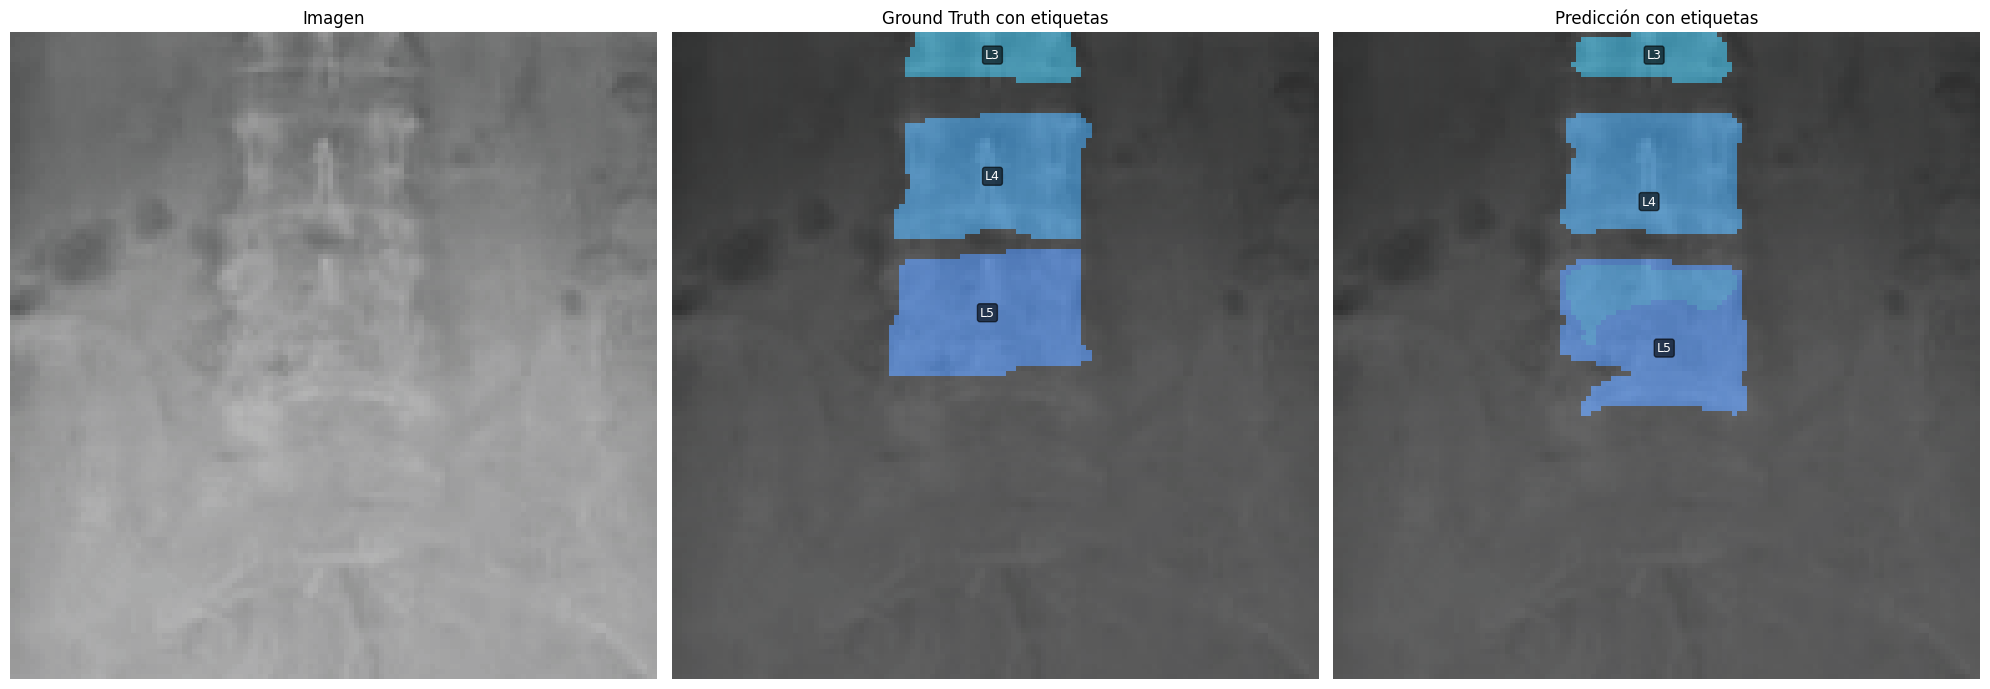

Dice Score promedio: 0.9614
Dice Score por clase: 
background 0.9827
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 1.0000
T8 1.0000
T9 1.0000
T10 1.0000
T11 1.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 0.9252
L4 0.8027
L5 0.5954
2
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_53.jpg


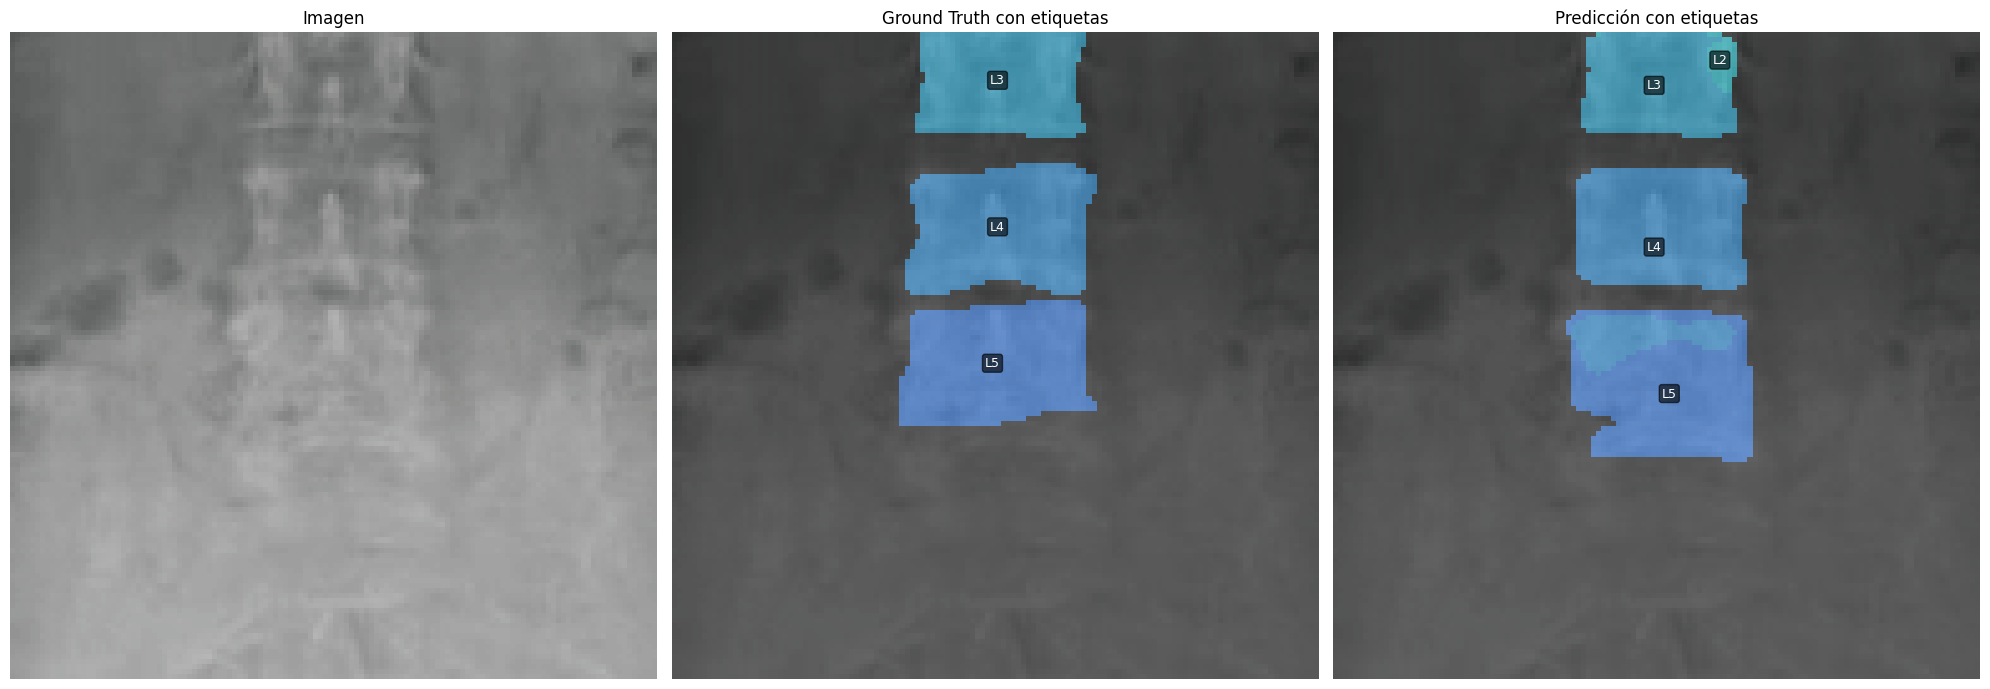

Dice Score promedio: 0.9096
Dice Score por clase: 
background 0.9826
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 1.0000
T8 1.0000
T9 1.0000
T10 1.0000
T11 1.0000
T12 1.0000
L1 1.0000
L2 0.0000
L3 0.9121
L4 0.8214
L5 0.6562
2
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_53.jpg


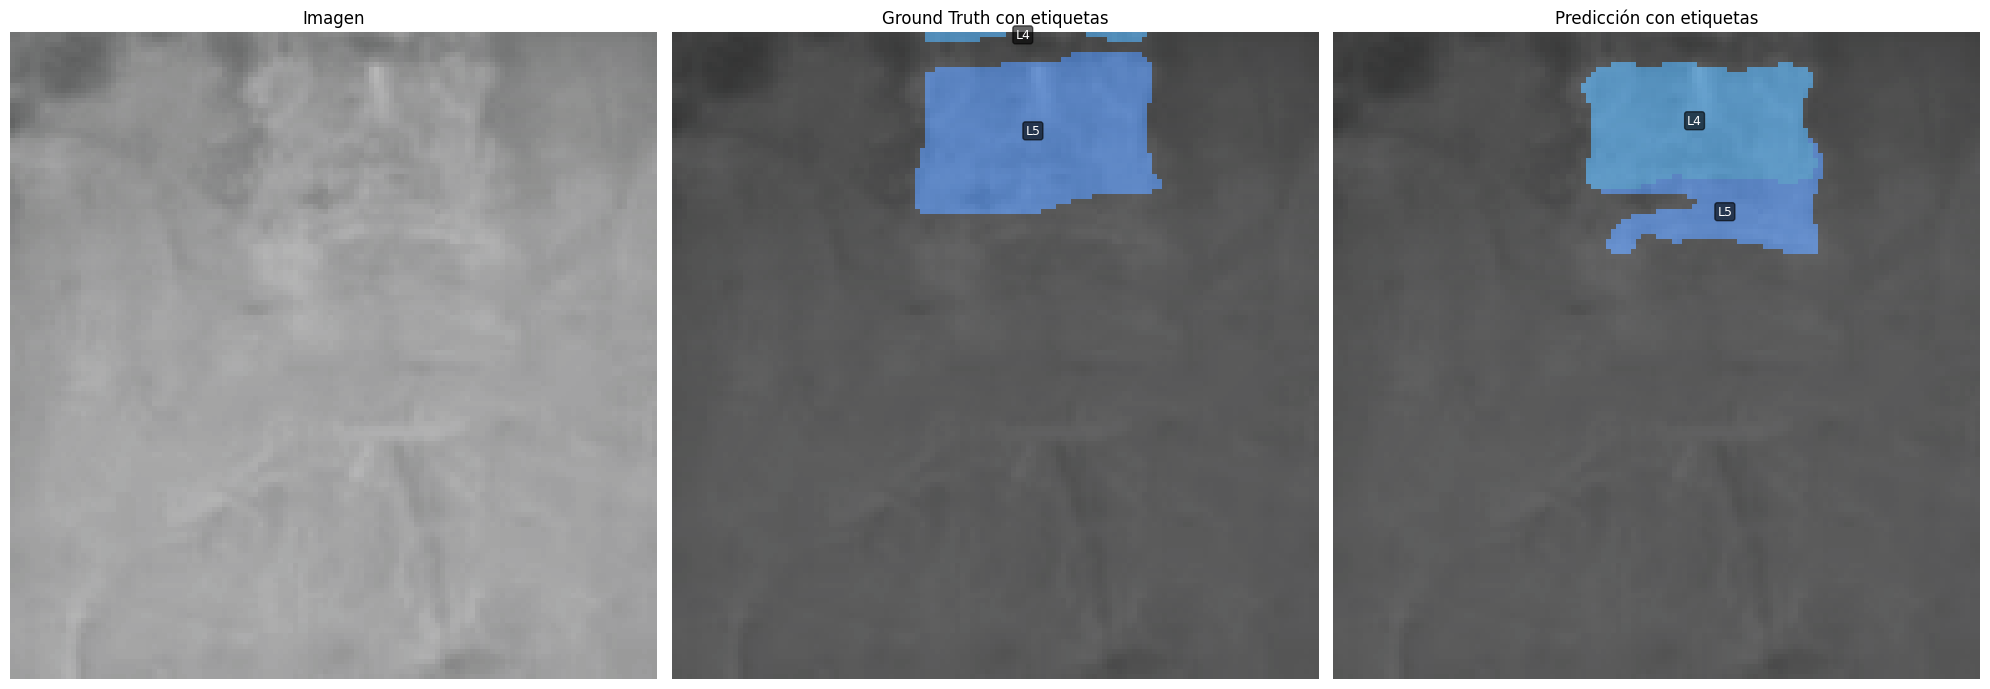

Dice Score promedio: 0.8967
Dice Score por clase: 
background 0.9812
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 1.0000
T8 1.0000
T9 1.0000
T10 1.0000
T11 1.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 0.0000
L5 0.1597
2
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_53.jpg


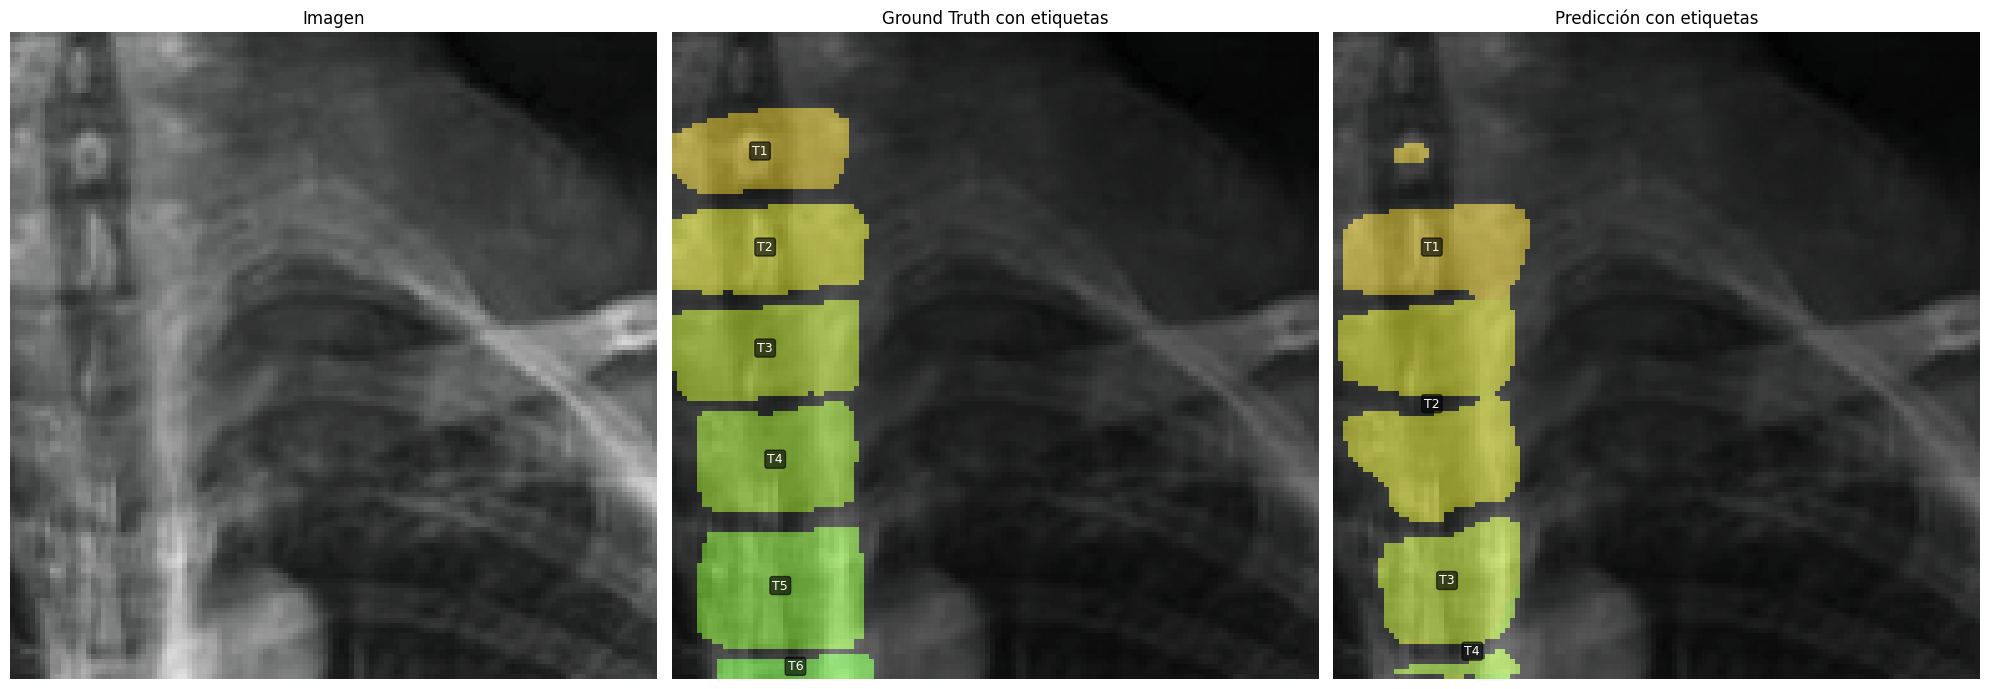

Dice Score promedio: 0.6669
Dice Score por clase: 
background 0.9620
T1 0.0425
T2 0.0000
T3 0.0000
T4 0.0000
T5 0.0000
T6 0.0000
T7 1.0000
T8 1.0000
T9 1.0000
T10 1.0000
T11 1.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000


In [39]:
import random
# Seleccionar un índice aleatorio del dataset de test
idx = 2
# print(idx)
for patch_idx in range(NUM_PATCHES):
    print(idx)
    show_gt_vs_pred_with_labels(
        model=model,
        dataset=test_dataset,
        device=device,
        idx=idx,
        patch_idx = patch_idx,
        label_dict=dic_labels,
        alpha=0.45,
        min_pixels=20
    )

0
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_114.jpg


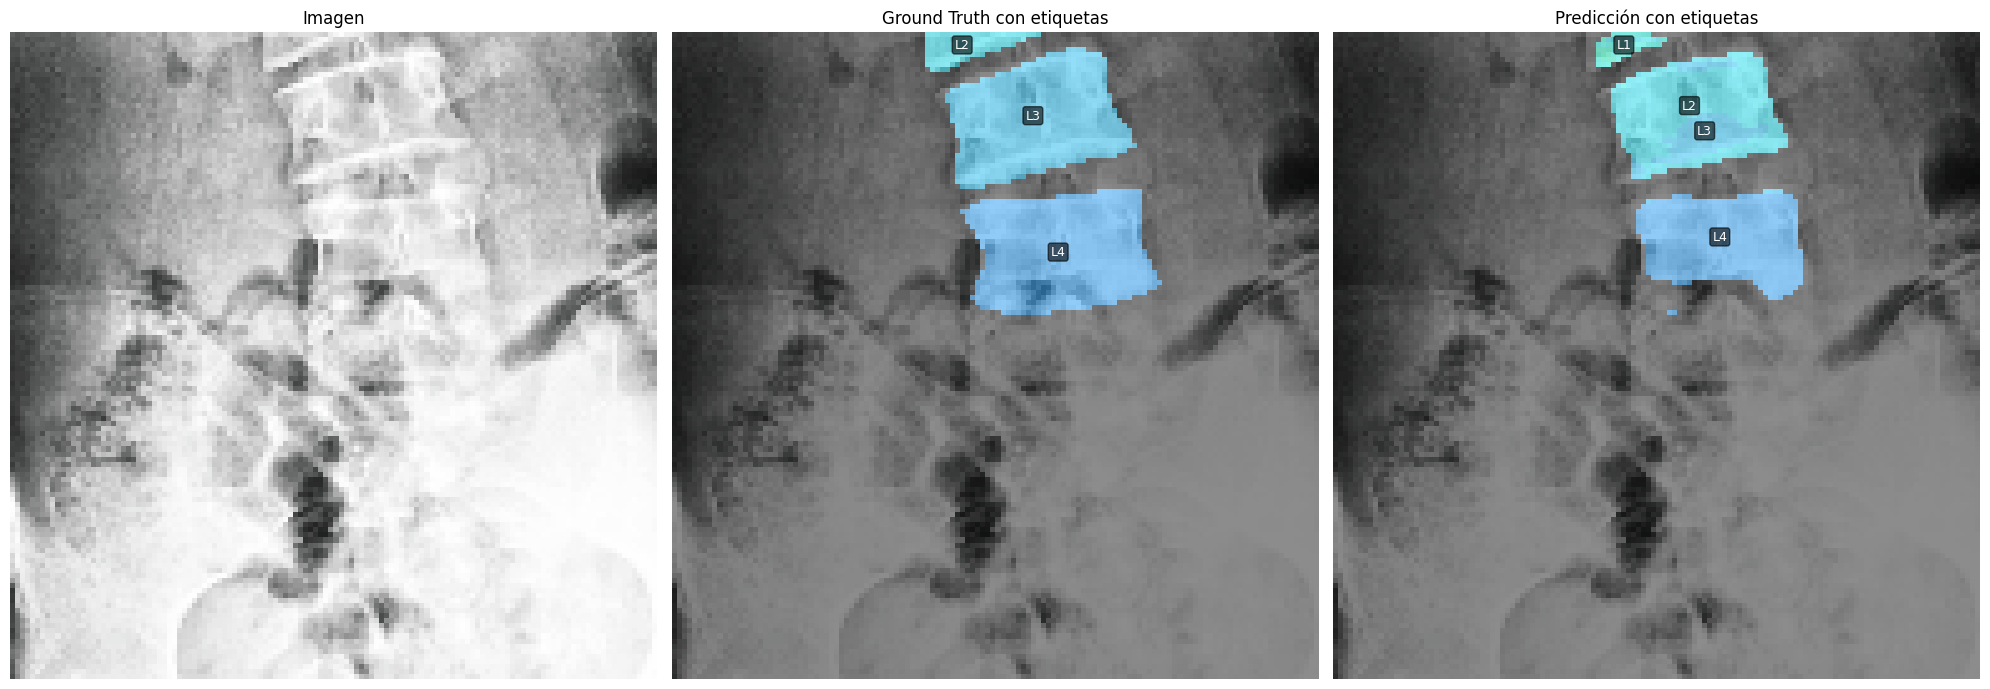

Dice Score promedio: 0.7886
Dice Score por clase: 
background 0.9874
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 1.0000
T8 1.0000
T9 1.0000
T10 1.0000
T11 1.0000
T12 0.0000
L1 0.0000
L2 0.0431
L3 0.3353
L4 0.8285
L5 1.0000
1
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_103.jpg


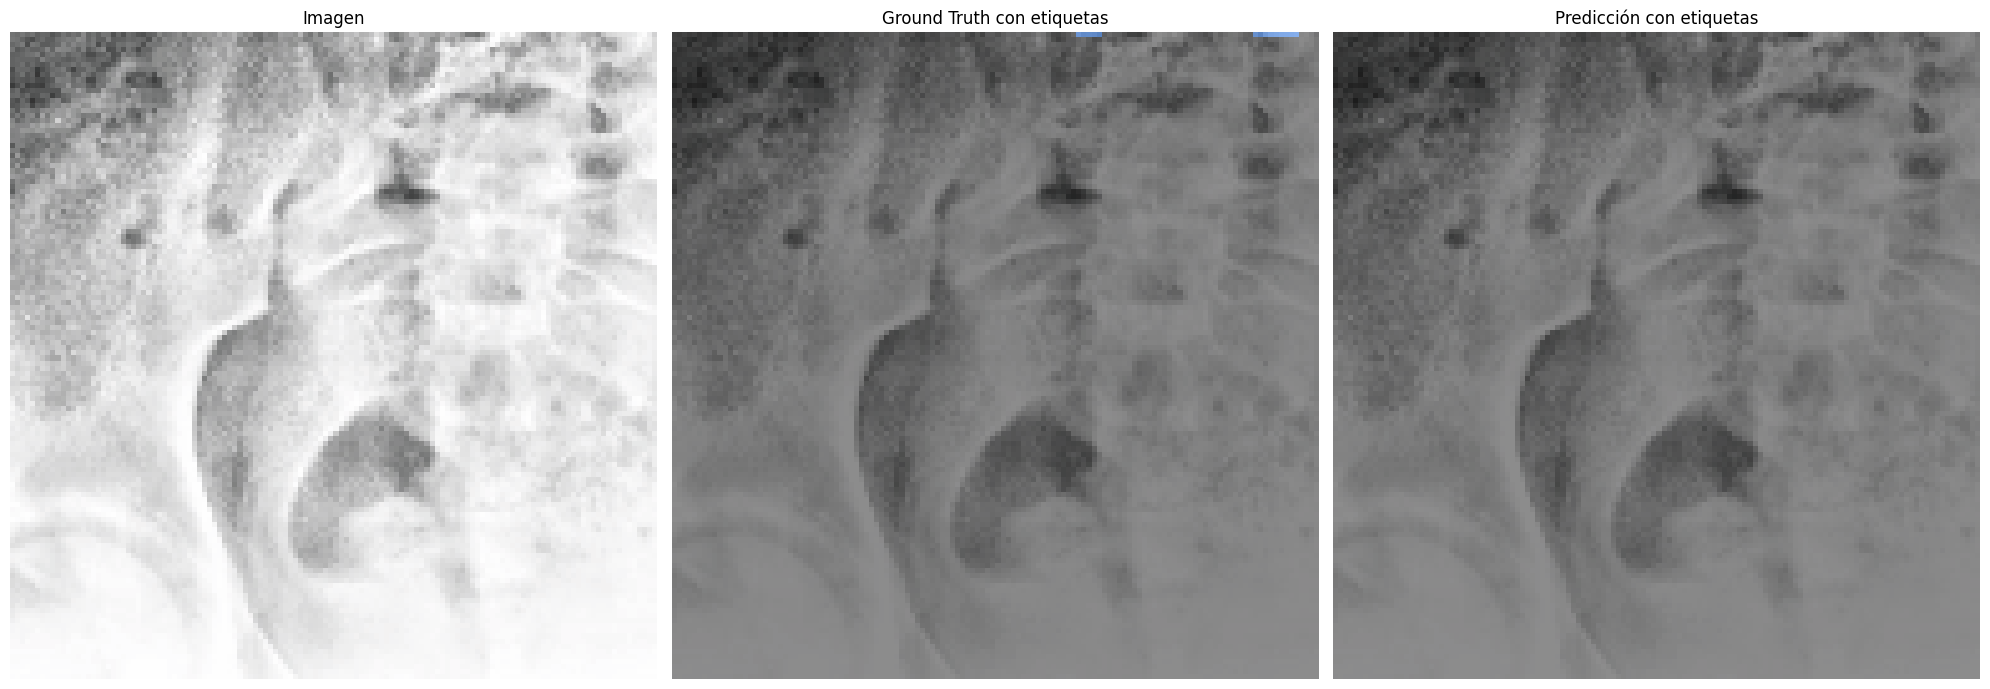

Dice Score promedio: 0.9444
Dice Score por clase: 
background 0.9996
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 1.0000
T8 1.0000
T9 1.0000
T10 1.0000
T11 1.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 0.0000
2
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_53.jpg


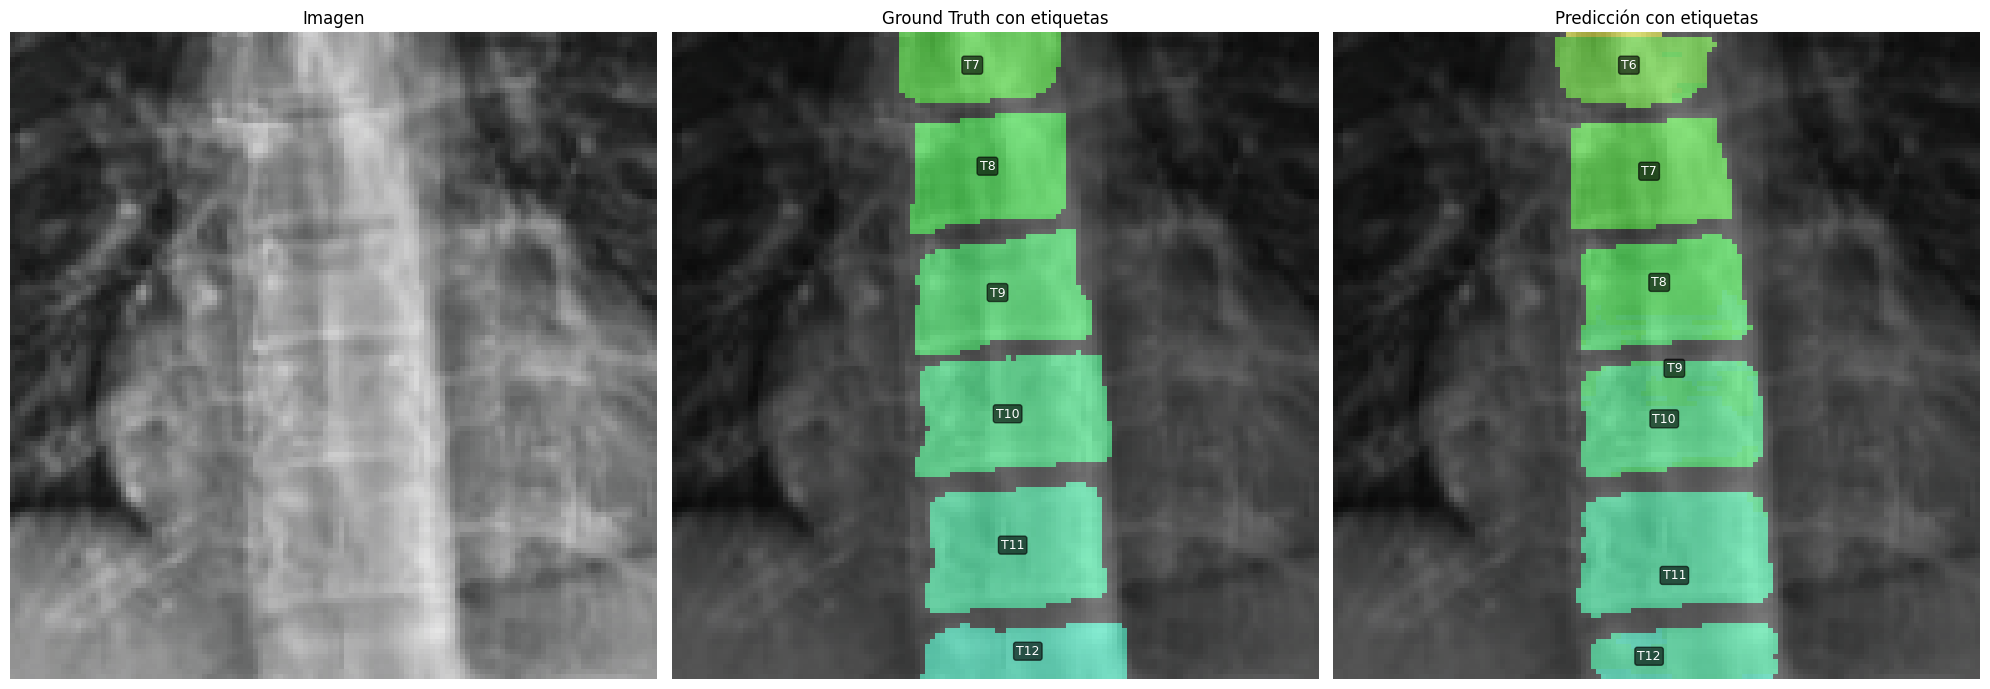

Dice Score promedio: 0.6741
Dice Score por clase: 
background 0.9823
T1 1.0000
T2 0.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 0.0000
T7 0.0317
T8 0.0000
T9 0.3071
T10 0.8100
T11 0.7865
T12 0.2154
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
3
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_56.jpg


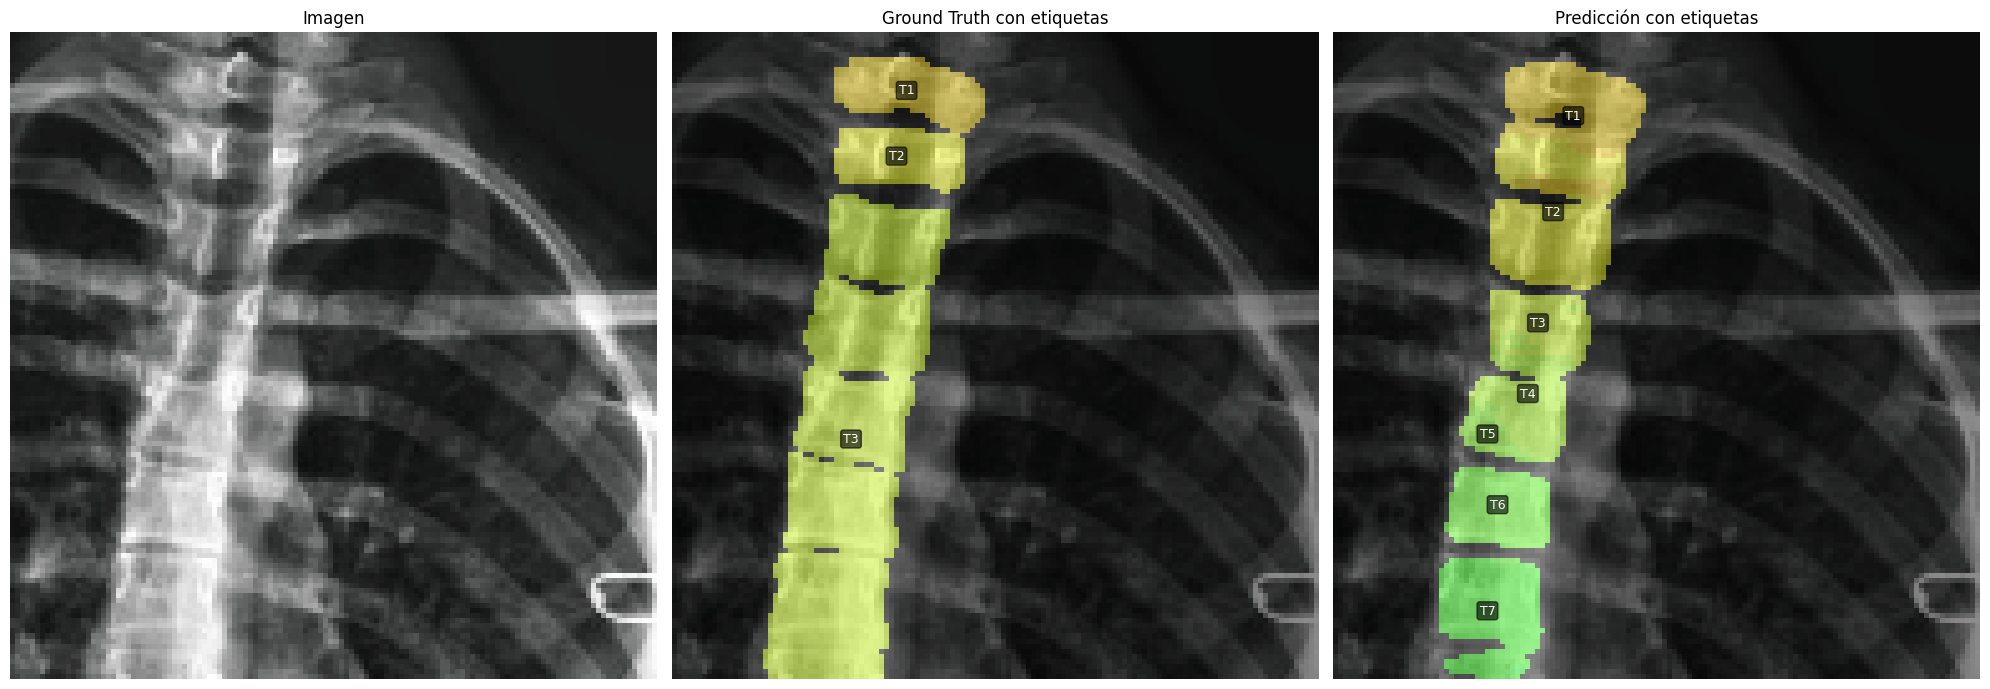

Dice Score promedio: 0.6263
Dice Score por clase: 
background 0.9774
T1 0.6959
T2 0.4128
T3 0.1877
T4 0.0000
T5 0.0000
T6 0.0000
T7 0.0000
T8 0.0000
T9 1.0000
T10 1.0000
T11 1.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
4
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_163.jpg


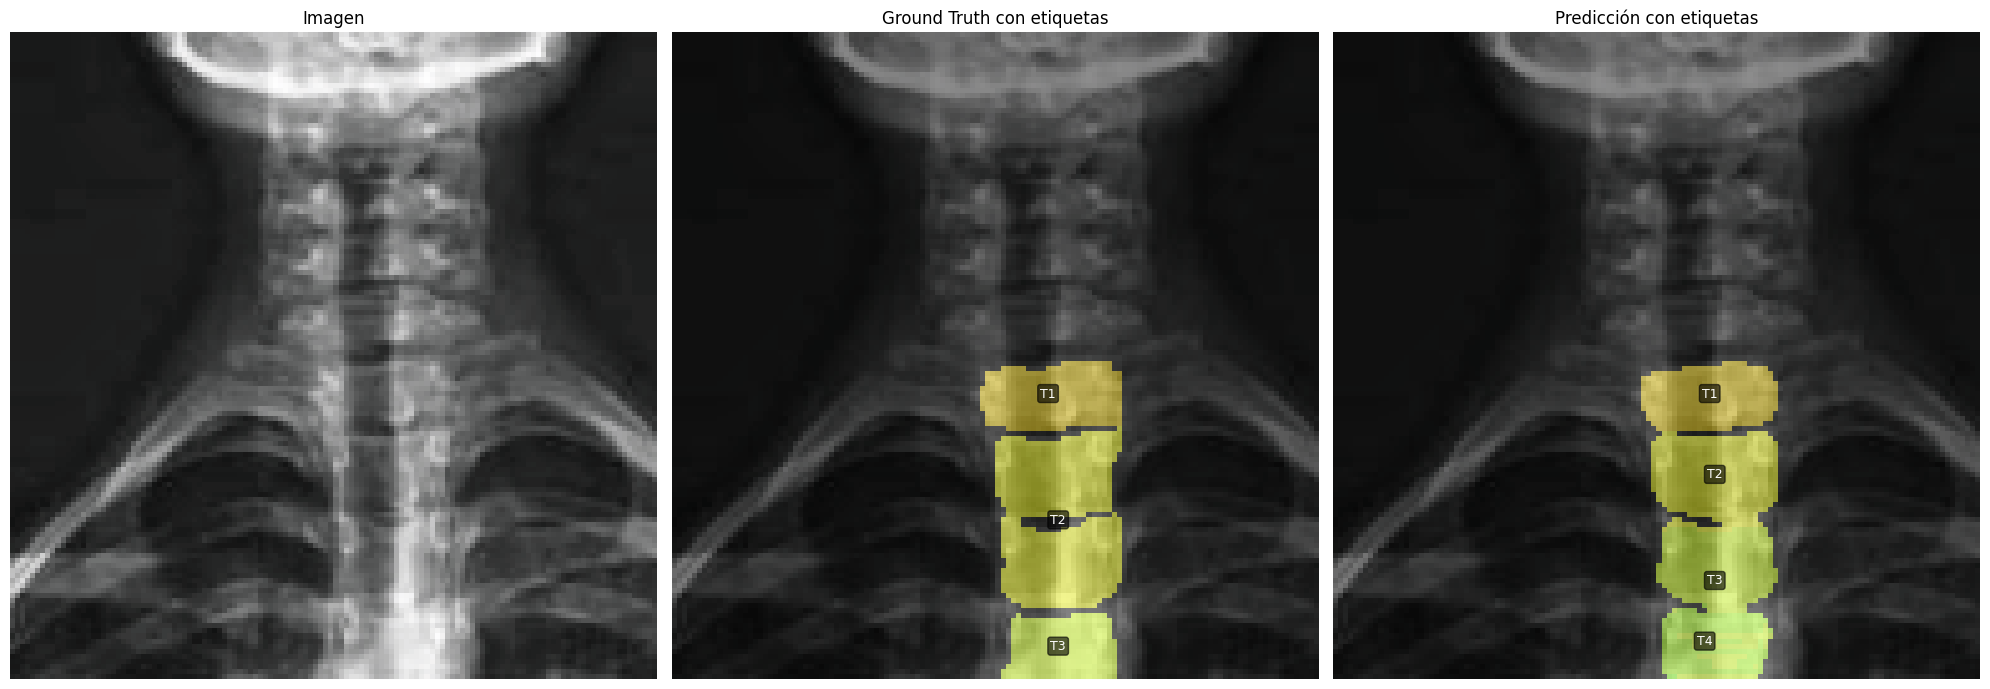

Dice Score promedio: 0.8224
Dice Score por clase: 
background 0.9925
T1 0.9412
T2 0.6289
T3 0.2400
T4 0.0000
T5 0.0000
T6 1.0000
T7 1.0000
T8 1.0000
T9 1.0000
T10 1.0000
T11 1.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
5
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_71.jpg


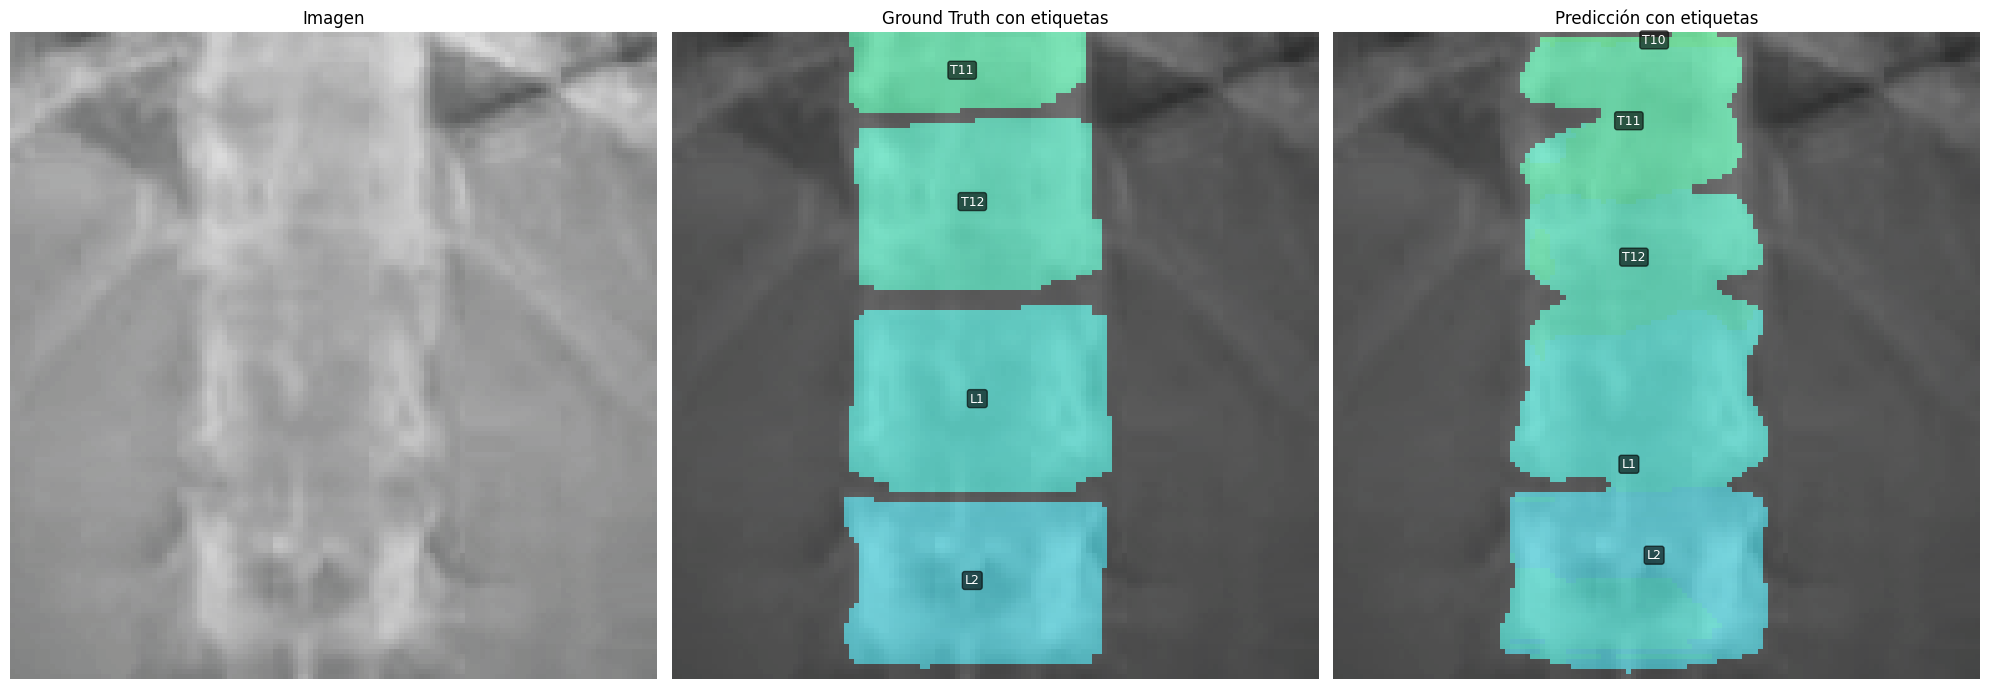

Dice Score promedio: 0.8668
Dice Score por clase: 
background 0.9606
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 1.0000
T8 1.0000
T9 1.0000
T10 0.0000
T11 0.5542
T12 0.6074
L1 0.7495
L2 0.7302
L3 1.0000
L4 1.0000
L5 1.0000
6
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_139.jpg


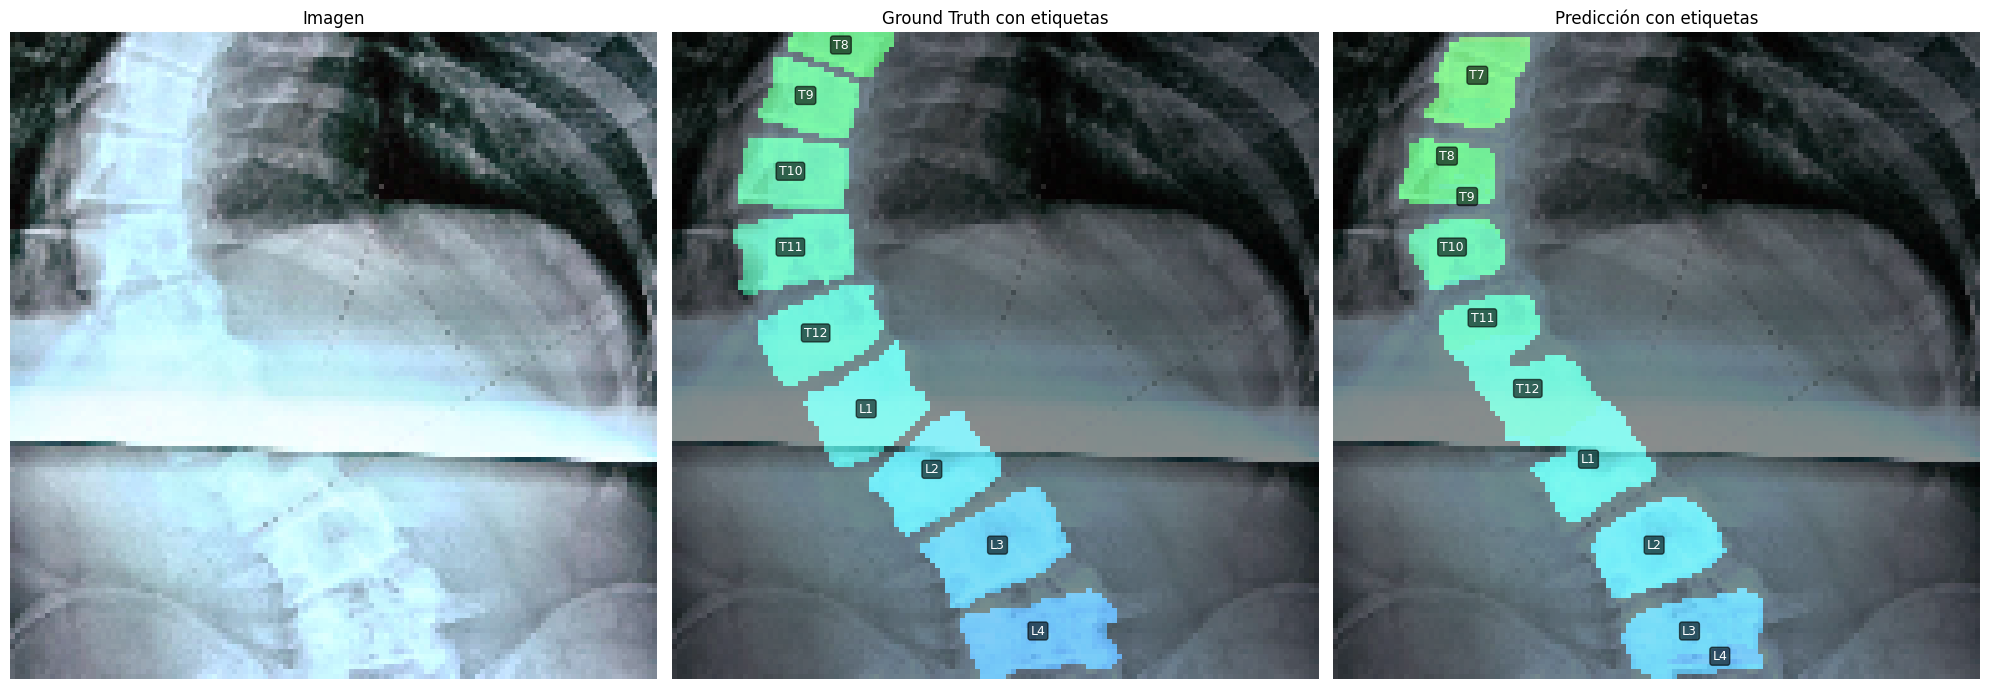

Dice Score promedio: 0.4157
Dice Score por clase: 
background 0.9713
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 0.0000
T7 0.0000
T8 0.0000
T9 0.0000
T10 0.0000
T11 0.0429
T12 0.2119
L1 0.0326
L2 0.0000
L3 0.0000
L4 0.2243
L5 1.0000
7
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_118.jpg


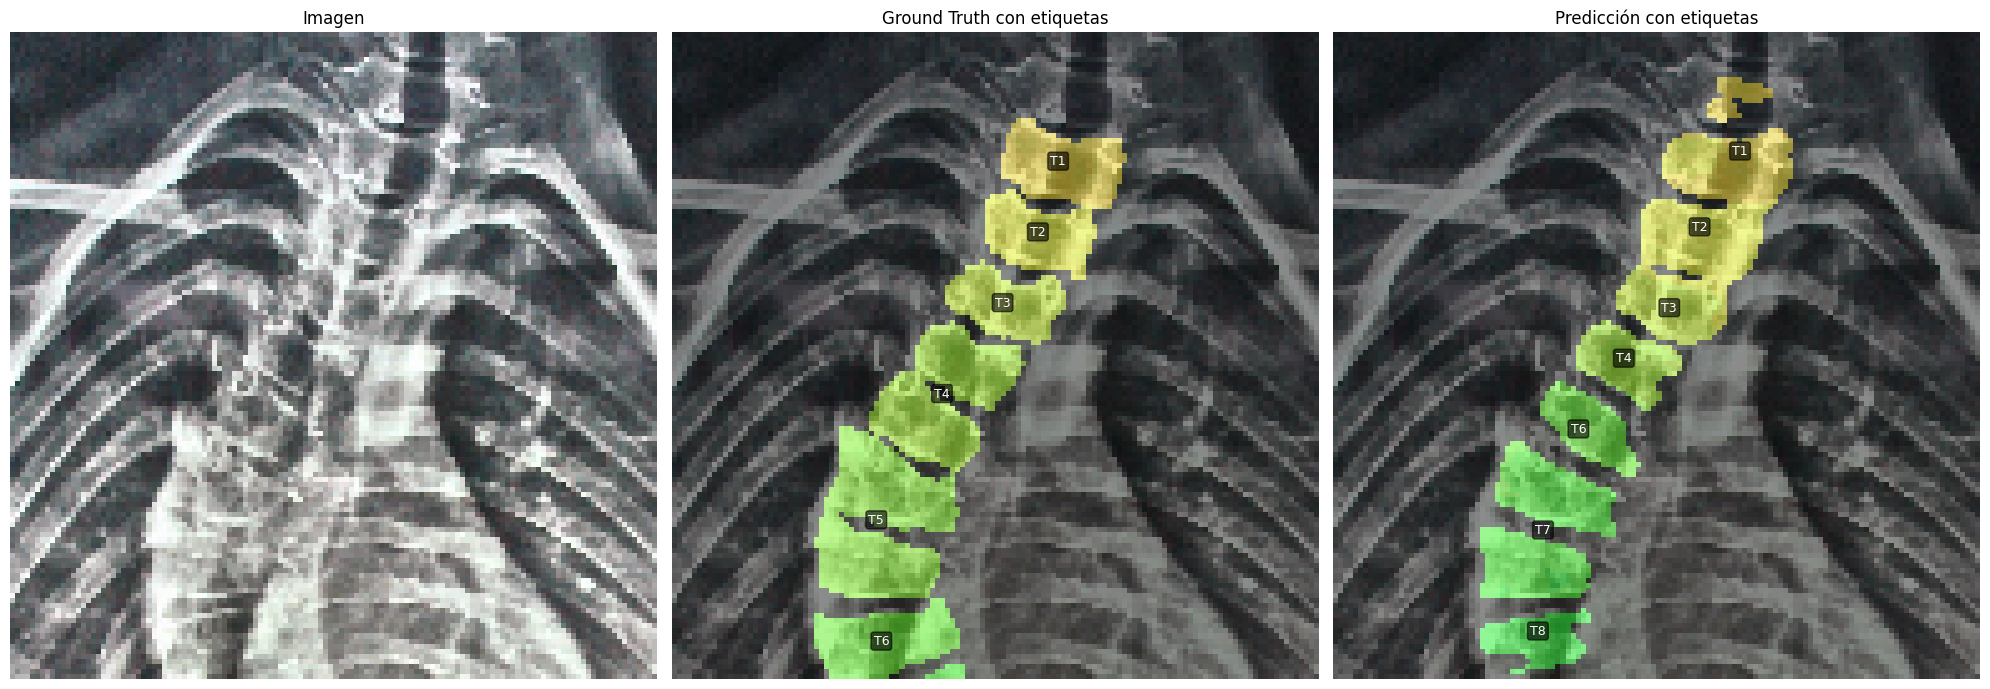

Dice Score promedio: 0.7075
Dice Score por clase: 
background 0.9756
T1 0.6600
T2 0.7032
T3 0.8540
T4 0.5413
T5 0.0000
T6 0.0000
T7 0.0000
T8 0.0000
T9 1.0000
T10 1.0000
T11 1.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
8
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_15.jpg


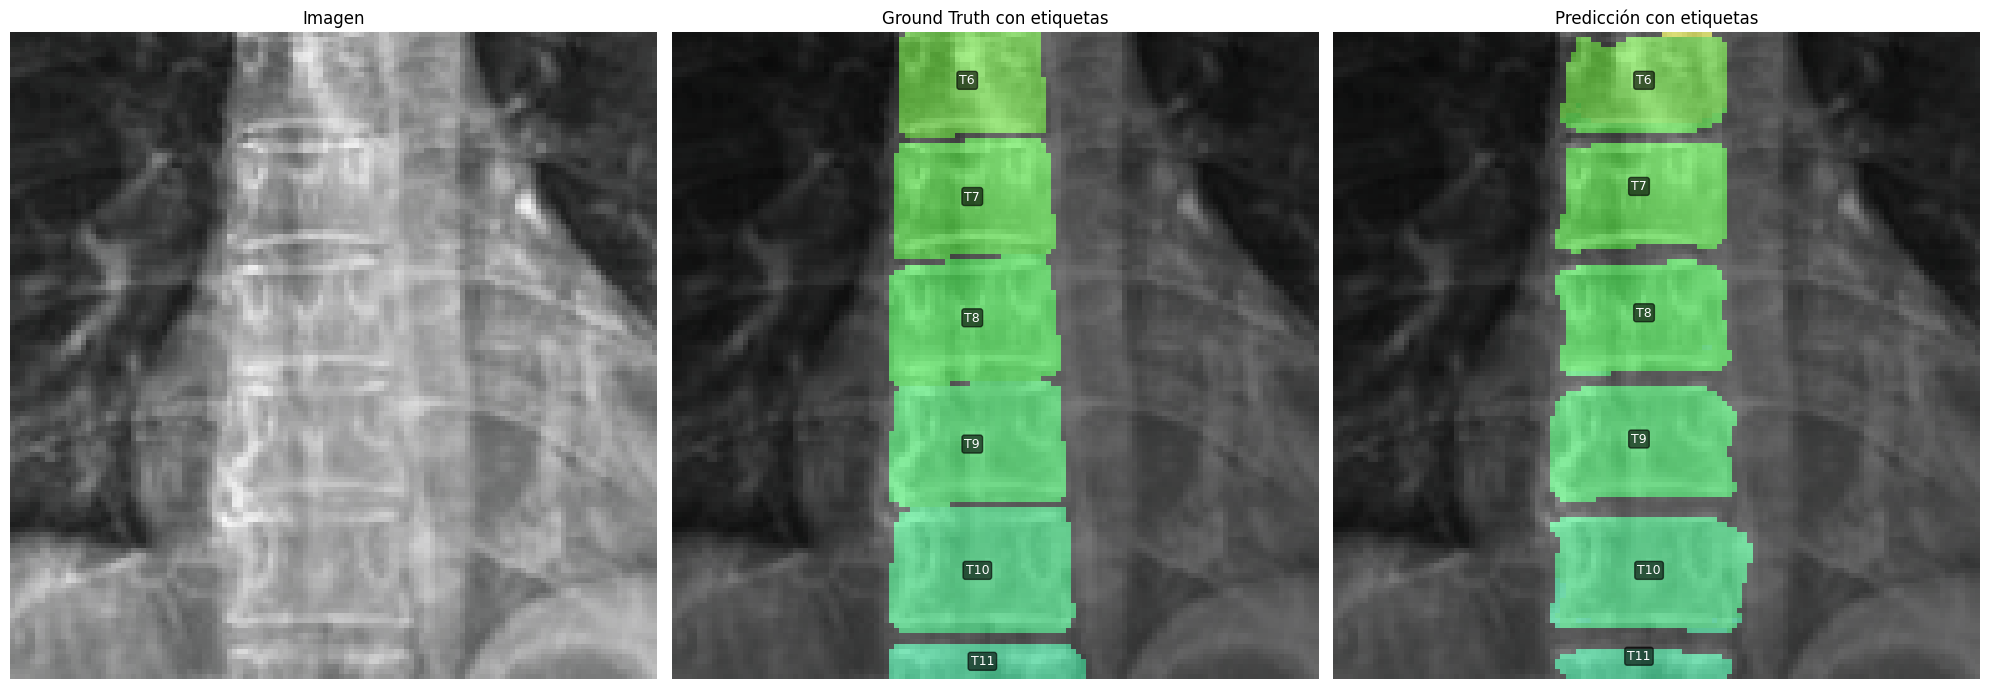

Dice Score promedio: 0.8950
Dice Score por clase: 
background 0.9684
T1 1.0000
T2 0.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 0.8128
T7 0.8443
T8 0.8809
T9 0.9323
T10 0.8927
T11 0.7794
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
9
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_157.jpg


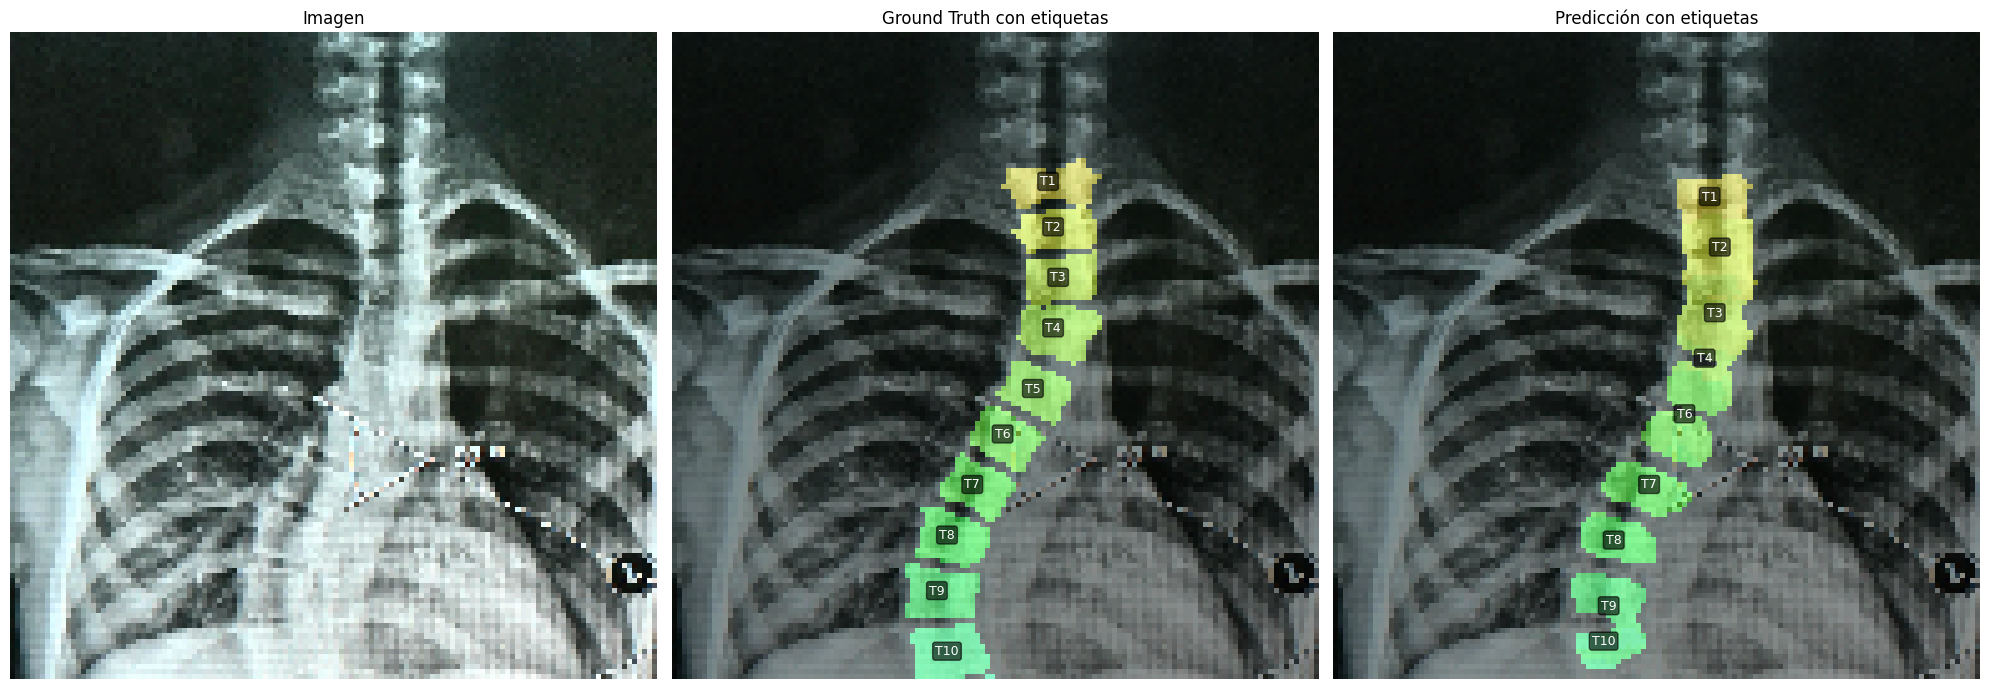

Dice Score promedio: 0.6786
Dice Score por clase: 
background 0.9863
T1 0.6239
T2 0.5918
T3 0.3322
T4 0.1895
T5 0.1985
T6 0.4674
T7 0.7849
T8 0.8462
T9 0.6966
T10 0.4974
T11 0.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
10
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_58.jpg


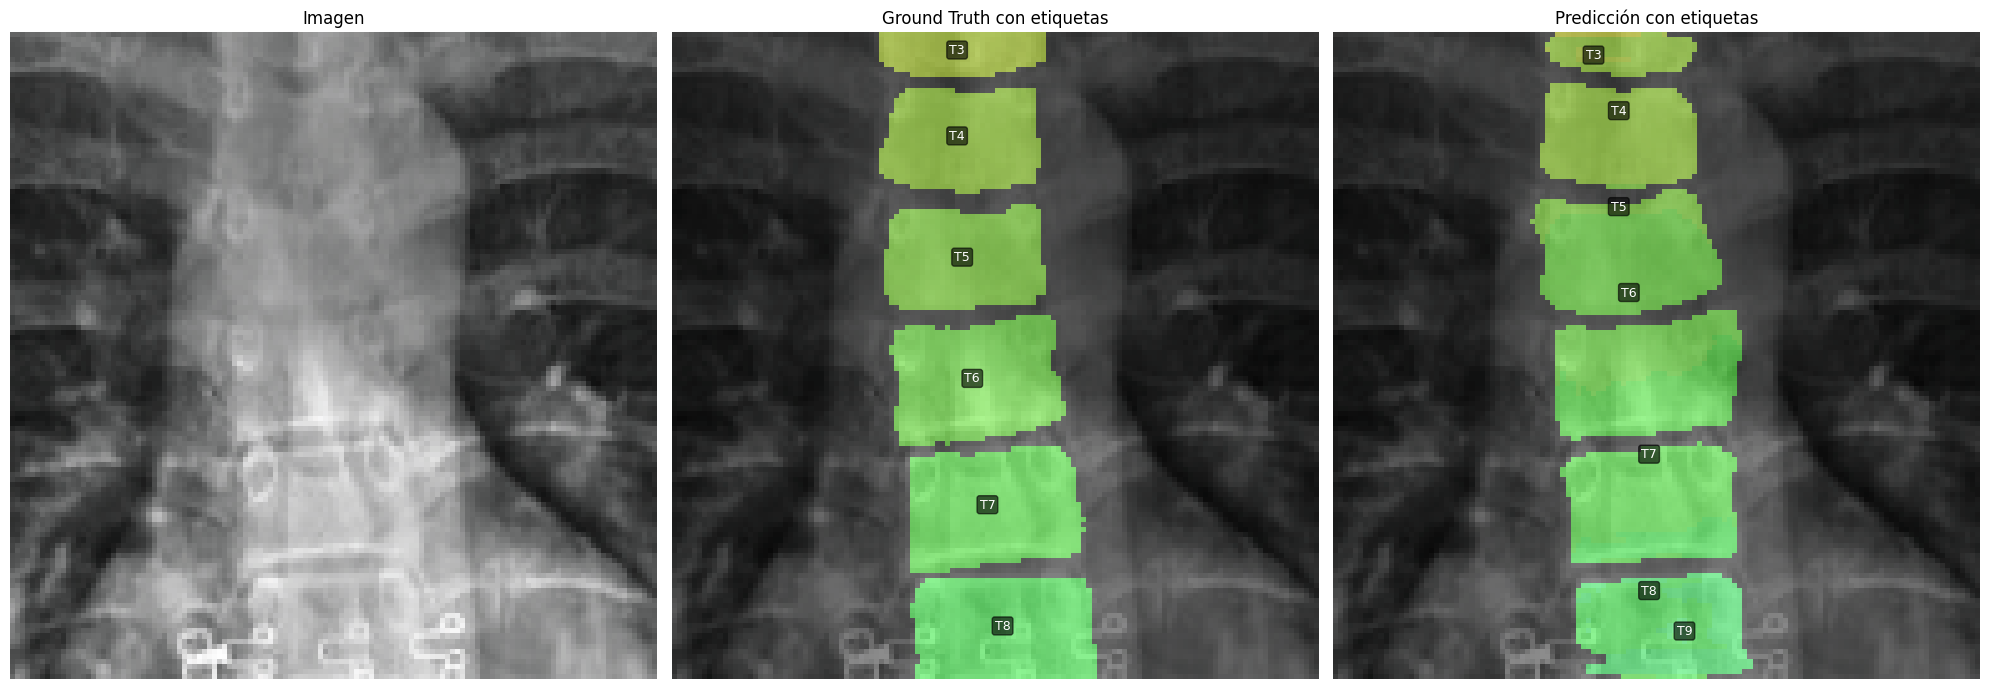

Dice Score promedio: 0.6962
Dice Score por clase: 
background 0.9772
T1 1.0000
T2 0.0000
T3 0.1448
T4 0.7997
T5 0.0862
T6 0.3843
T7 0.6105
T8 0.5292
T9 0.0000
T10 1.0000
T11 1.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
11
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_140.jpg


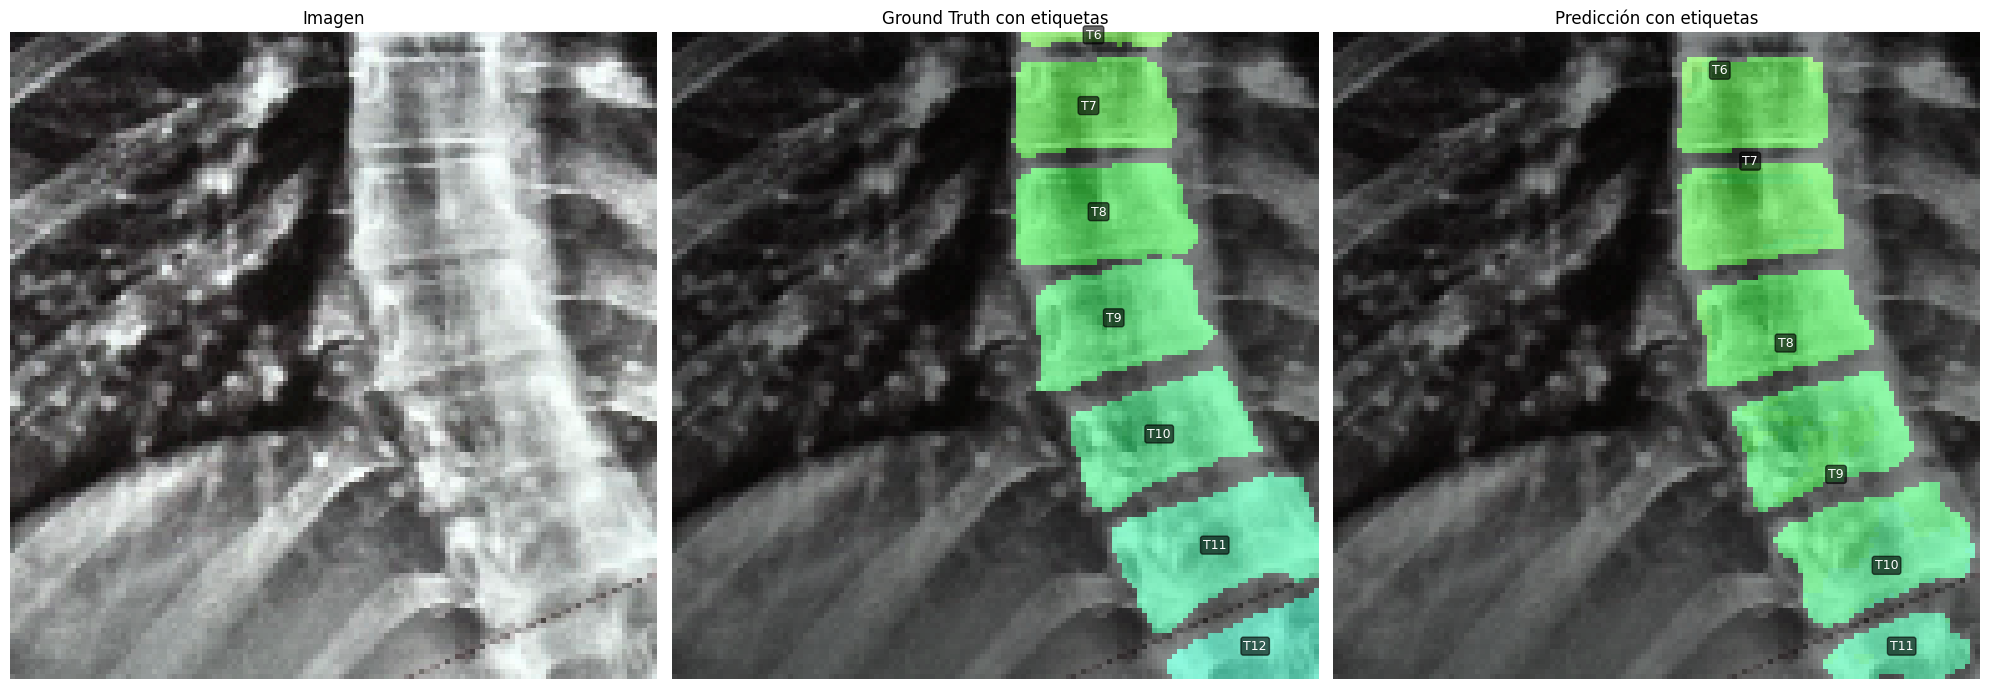

Dice Score promedio: 0.6490
Dice Score por clase: 
background 0.9754
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 0.0000
T7 0.6144
T8 0.0815
T9 0.0000
T10 0.0000
T11 0.0113
T12 0.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
12
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_102.jpg


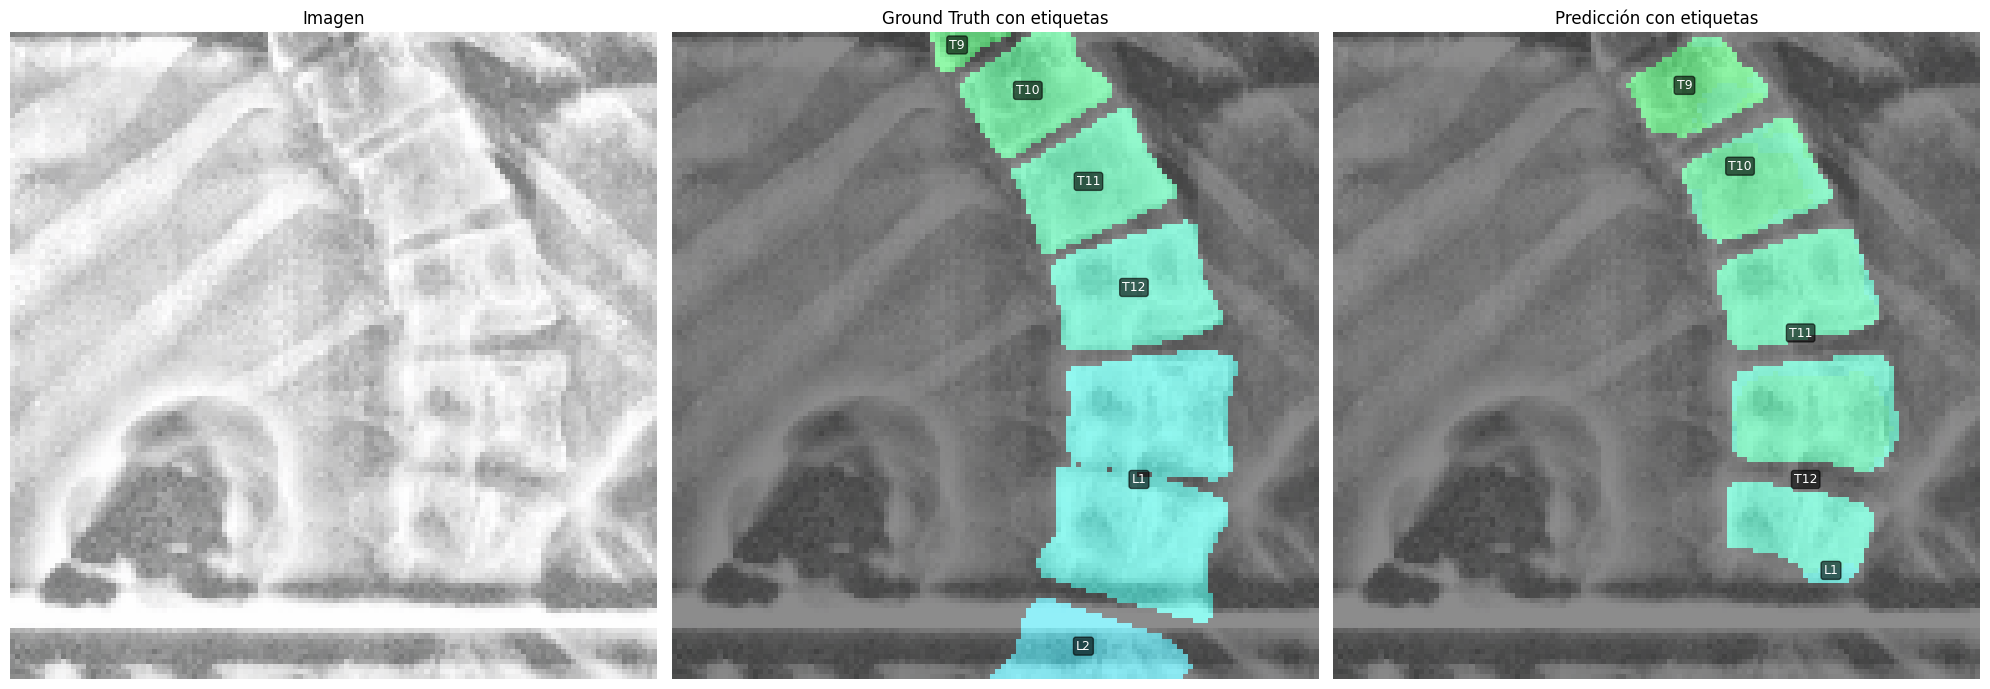

Dice Score promedio: 0.6851
Dice Score por clase: 
background 0.9523
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 1.0000
T8 1.0000
T9 0.0000
T10 0.1858
T11 0.1444
T12 0.0135
L1 0.0352
L2 0.0000
L3 1.0000
L4 1.0000
L5 1.0000
13
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_24.jpg


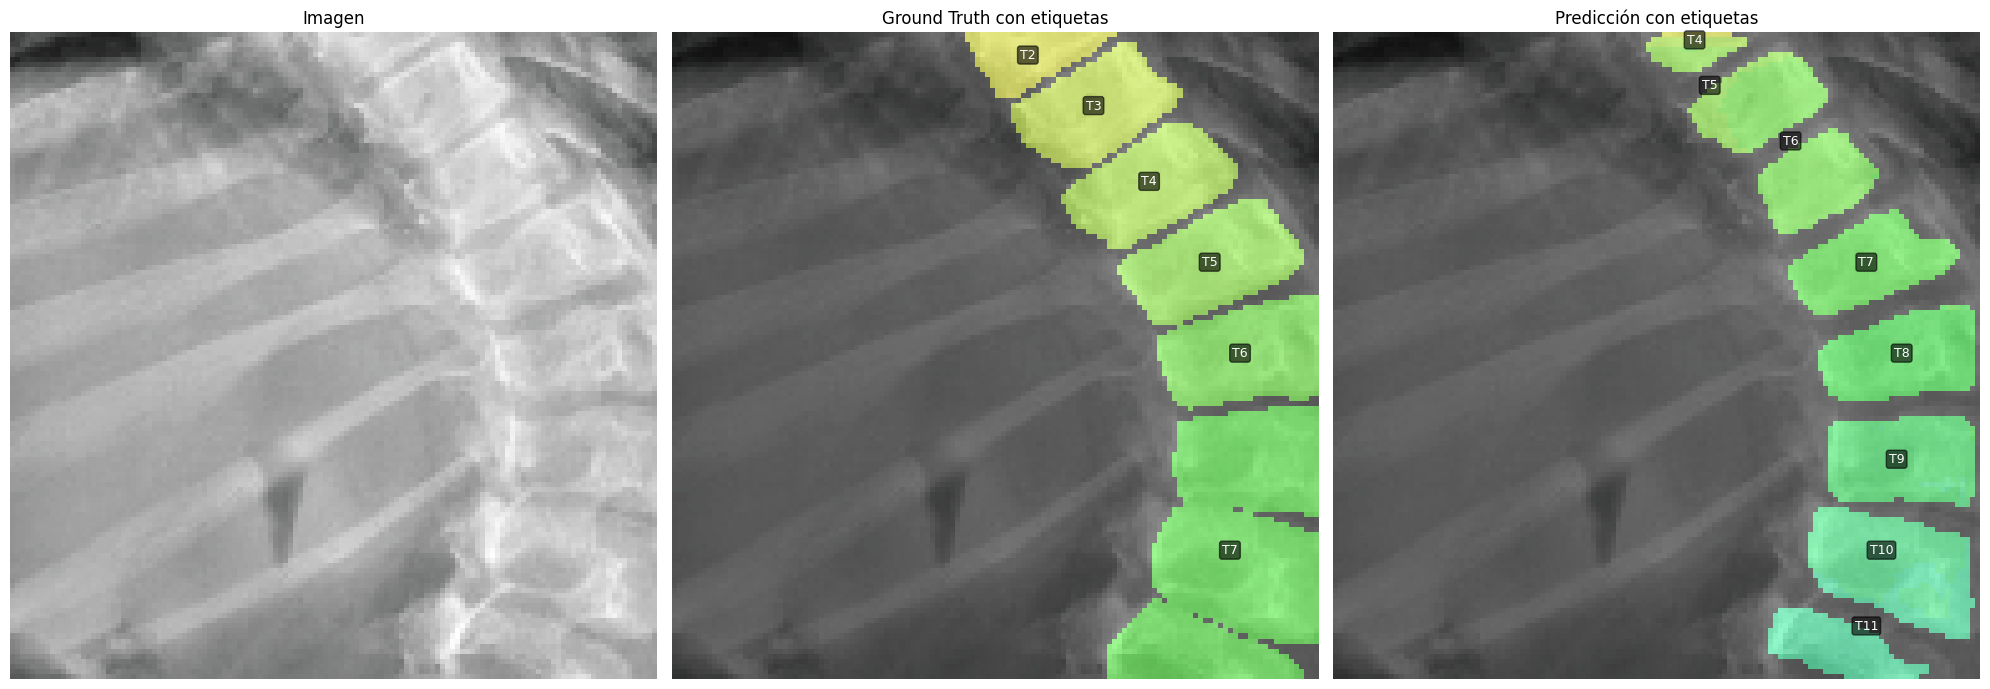

Dice Score promedio: 0.4482
Dice Score por clase: 
background 0.9541
T1 1.0000
T2 0.1138
T3 0.0000
T4 0.0000
T5 0.0000
T6 0.0000
T7 0.0000
T8 0.0000
T9 0.0000
T10 0.0000
T11 0.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
14
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_76.jpg


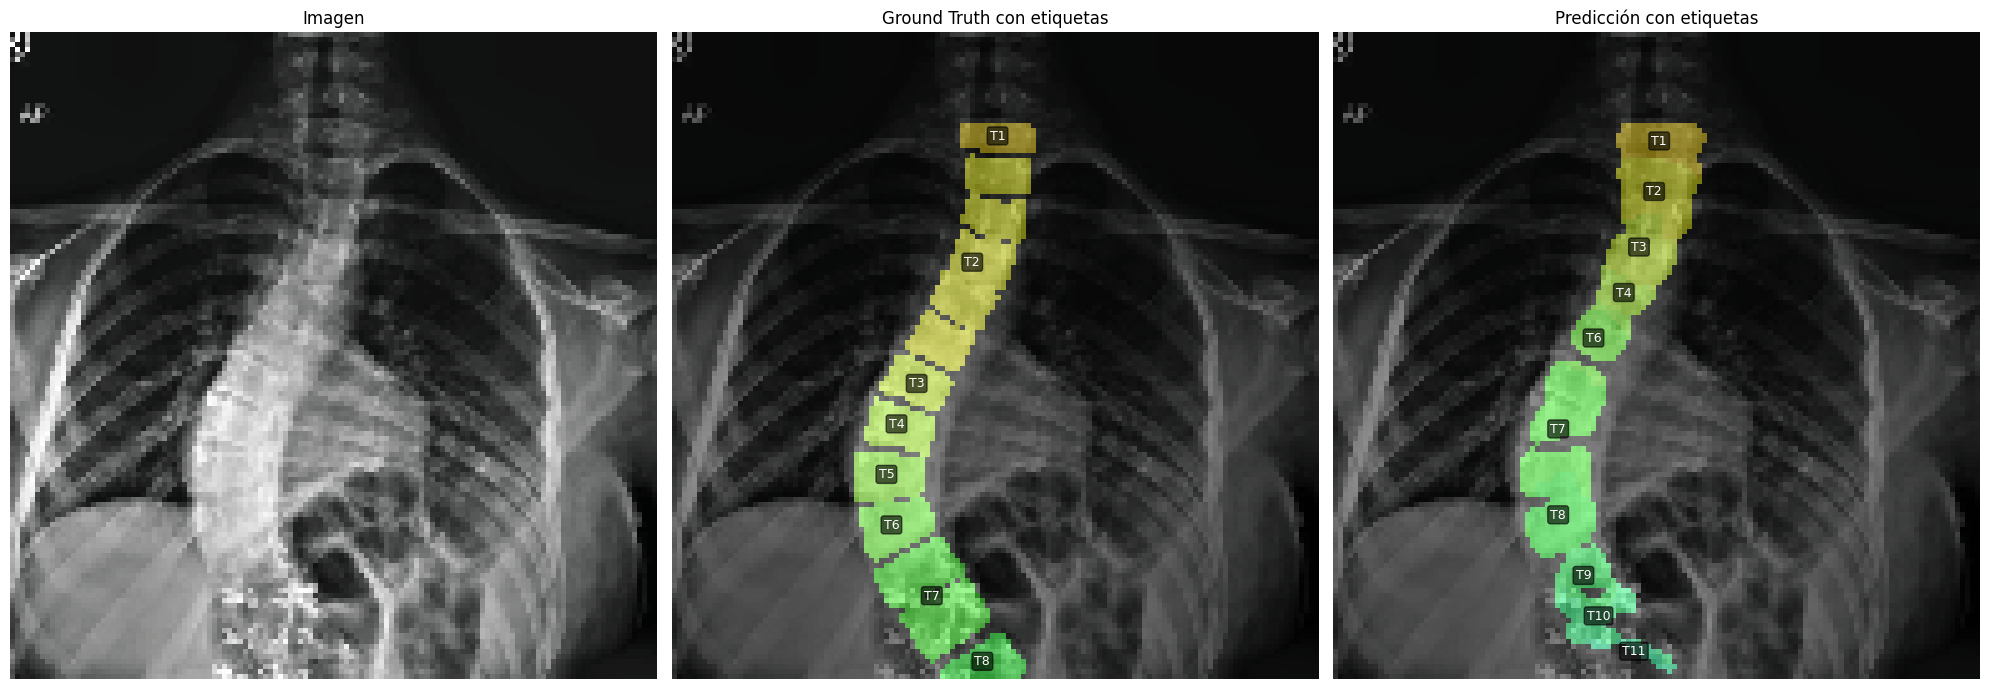

Dice Score promedio: 0.4567
Dice Score por clase: 
background 0.9844
T1 0.8019
T2 0.4347
T3 0.0000
T4 0.0000
T5 0.0000
T6 0.0000
T7 0.0000
T8 0.0000
T9 0.0000
T10 0.0000
T11 0.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
15
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_201.jpg


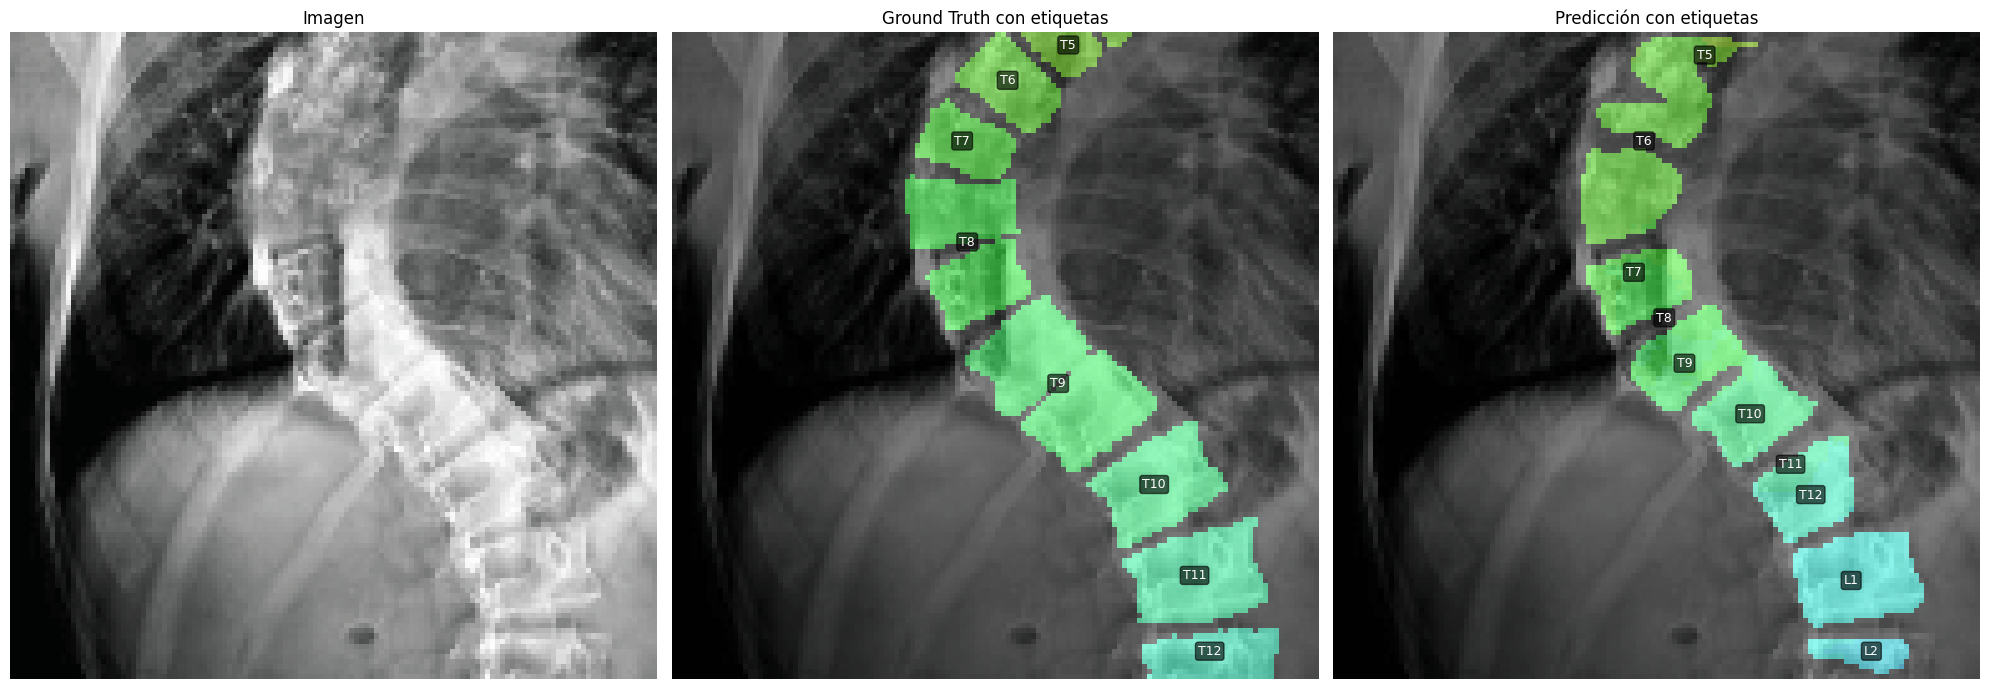

Dice Score promedio: 0.4082
Dice Score por clase: 
background 0.9687
T1 1.0000
T2 1.0000
T3 1.0000
T4 0.0000
T5 0.2406
T6 0.4326
T7 0.0000
T8 0.3411
T9 0.3527
T10 0.0125
T11 0.0000
T12 0.0000
L1 0.0000
L2 0.0000
L3 0.0000
L4 1.0000
L5 1.0000
16
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_83.jpg


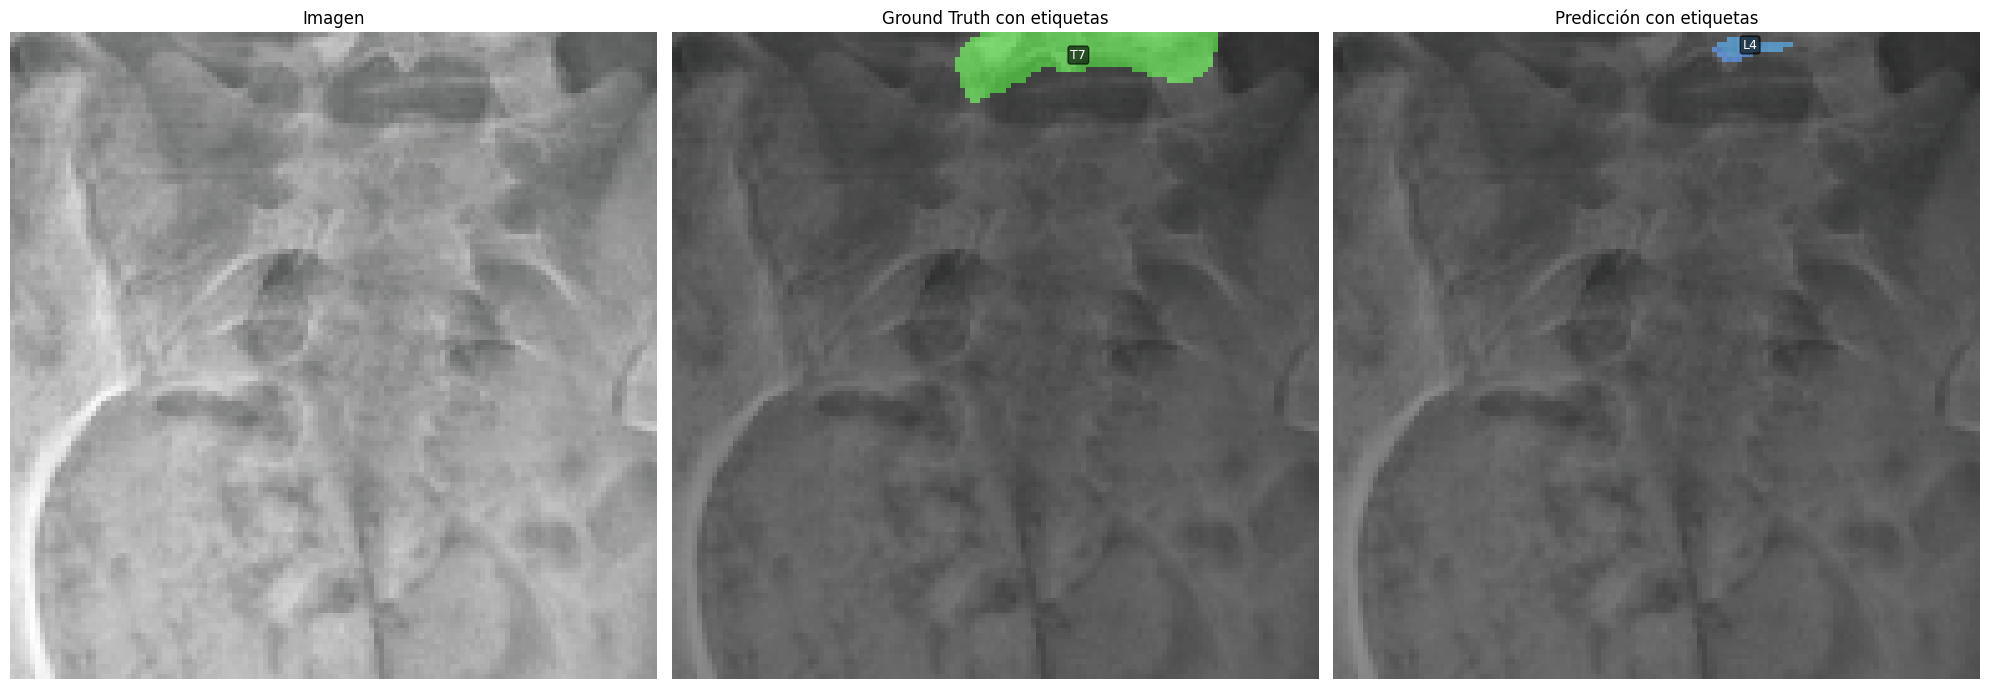

Dice Score promedio: 0.8326
Dice Score por clase: 
background 0.9873
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 0.0000
T8 1.0000
T9 1.0000
T10 1.0000
T11 1.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 0.0000
L5 0.0000
17
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_44.jpg


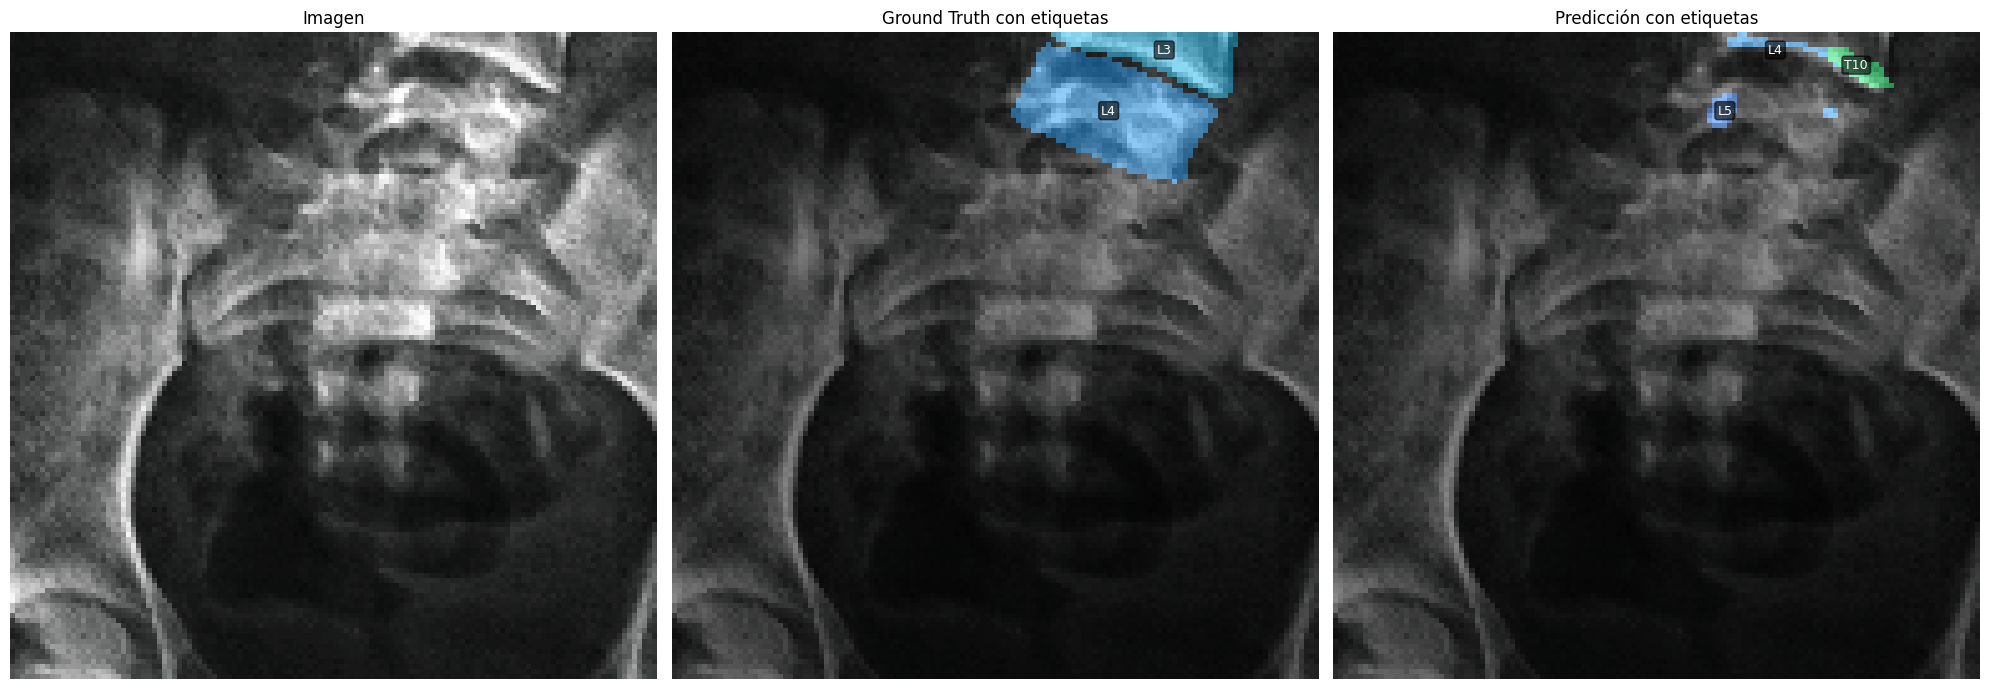

Dice Score promedio: 0.7776
Dice Score por clase: 
background 0.9746
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 1.0000
T8 1.0000
T9 1.0000
T10 0.0000
T11 1.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 0.0077
L4 0.0142
L5 0.0000
18
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_143.jpg


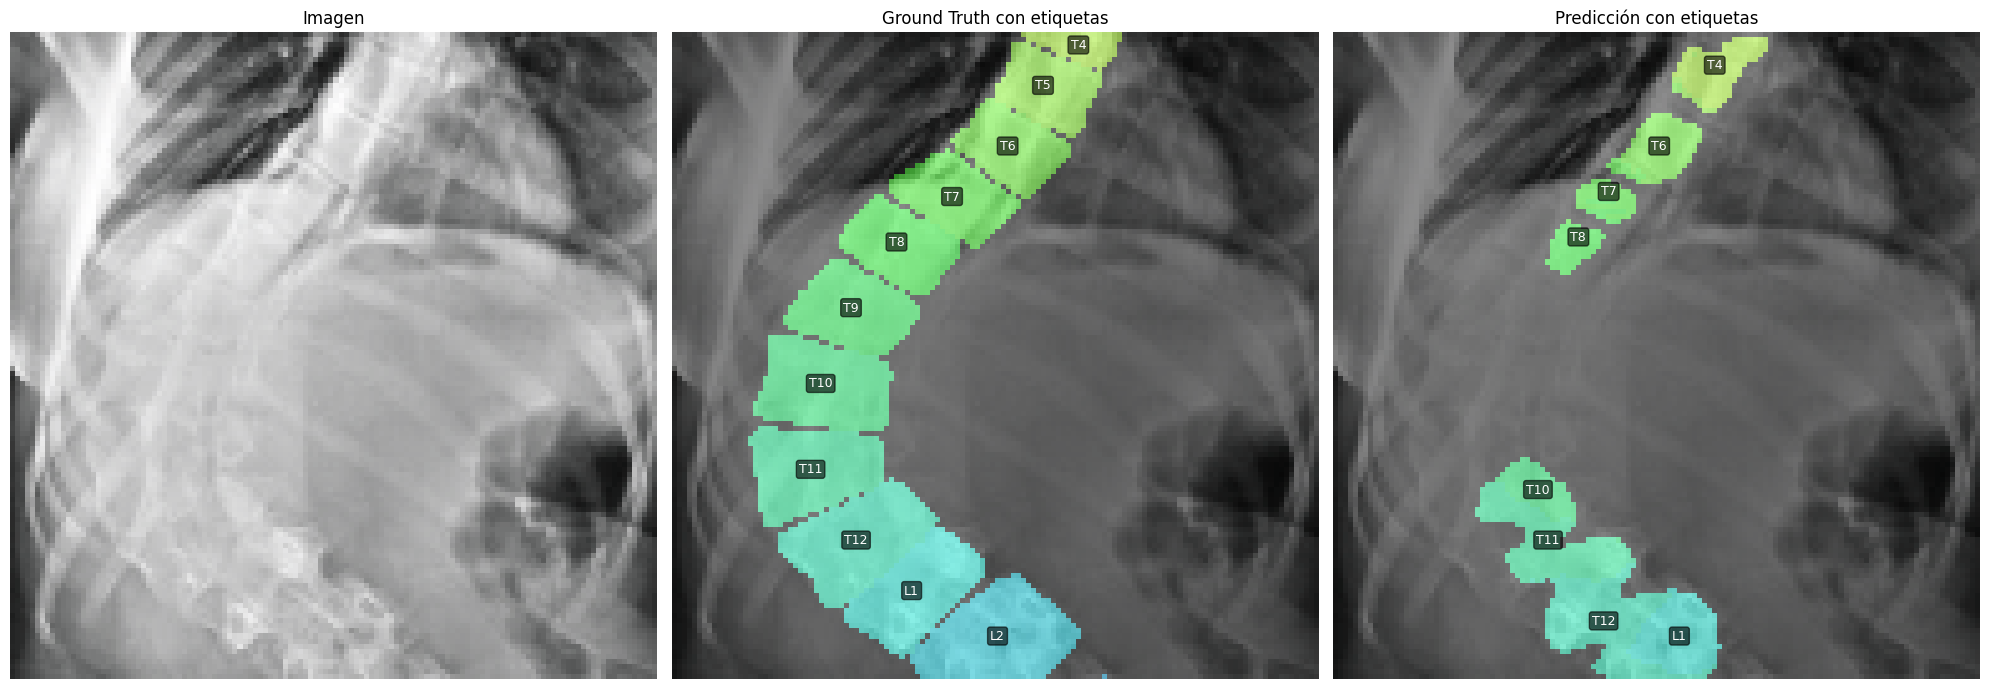

Dice Score promedio: 0.4389
Dice Score por clase: 
background 0.9201
T1 1.0000
T2 1.0000
T3 1.0000
T4 0.3333
T5 0.0916
T6 0.6570
T7 0.4290
T8 0.3895
T9 0.0000
T10 0.0000
T11 0.0774
T12 0.0026
L1 0.0000
L2 0.0000
L3 0.0000
L4 1.0000
L5 1.0000
19
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_24.jpg


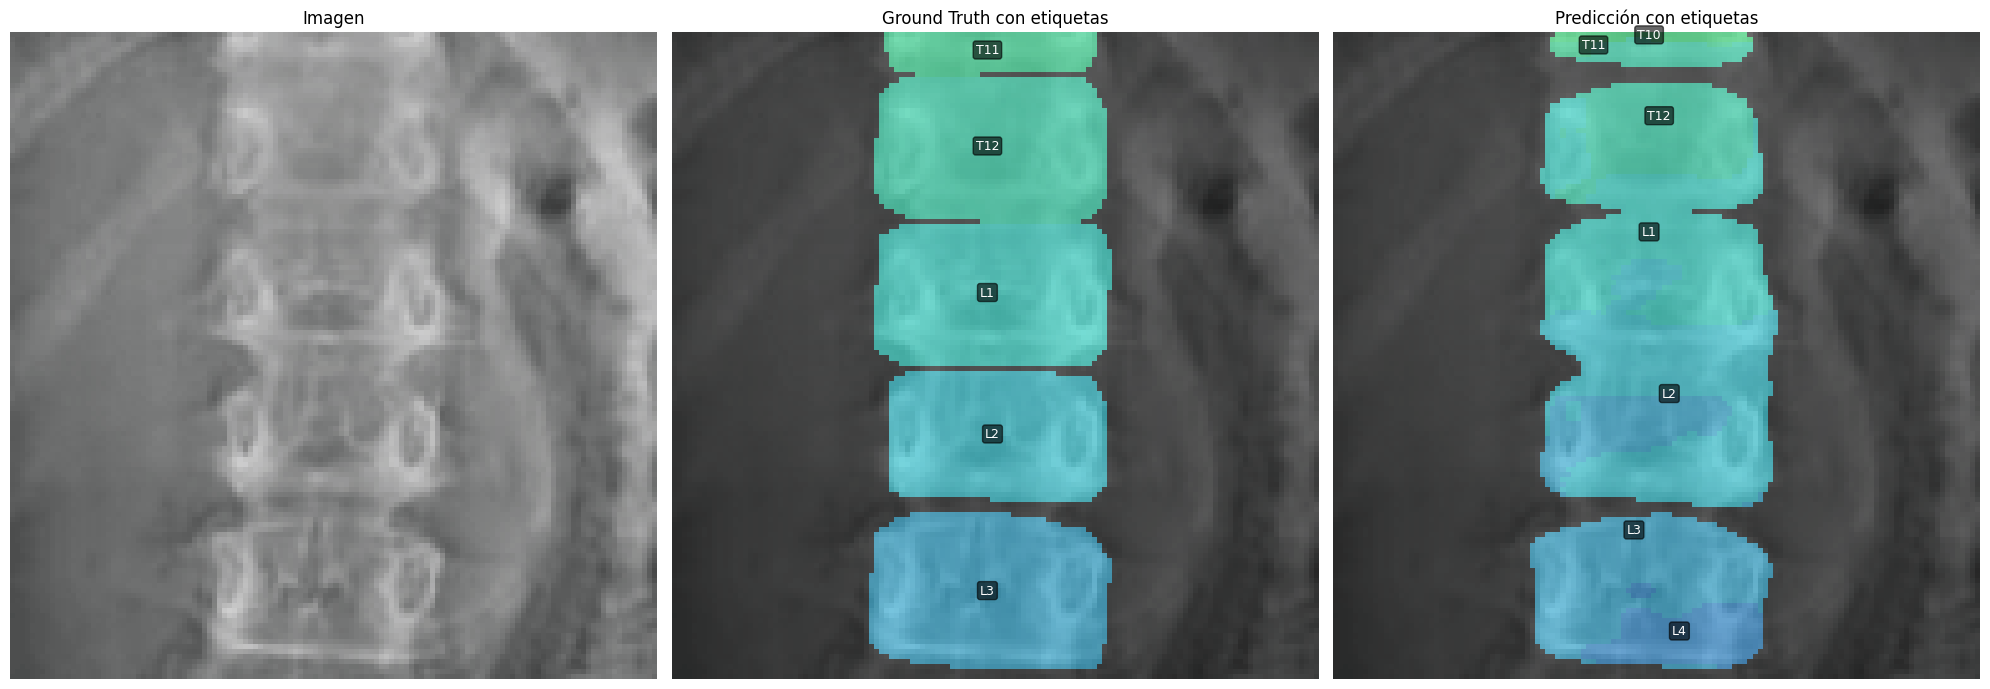

Dice Score promedio: 0.7543
Dice Score por clase: 
background 0.9715
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 1.0000
T8 1.0000
T9 1.0000
T10 0.0000
T11 0.1572
T12 0.6029
L1 0.5802
L2 0.5852
L3 0.6813
L4 0.0000
L5 1.0000
20
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_167.jpg


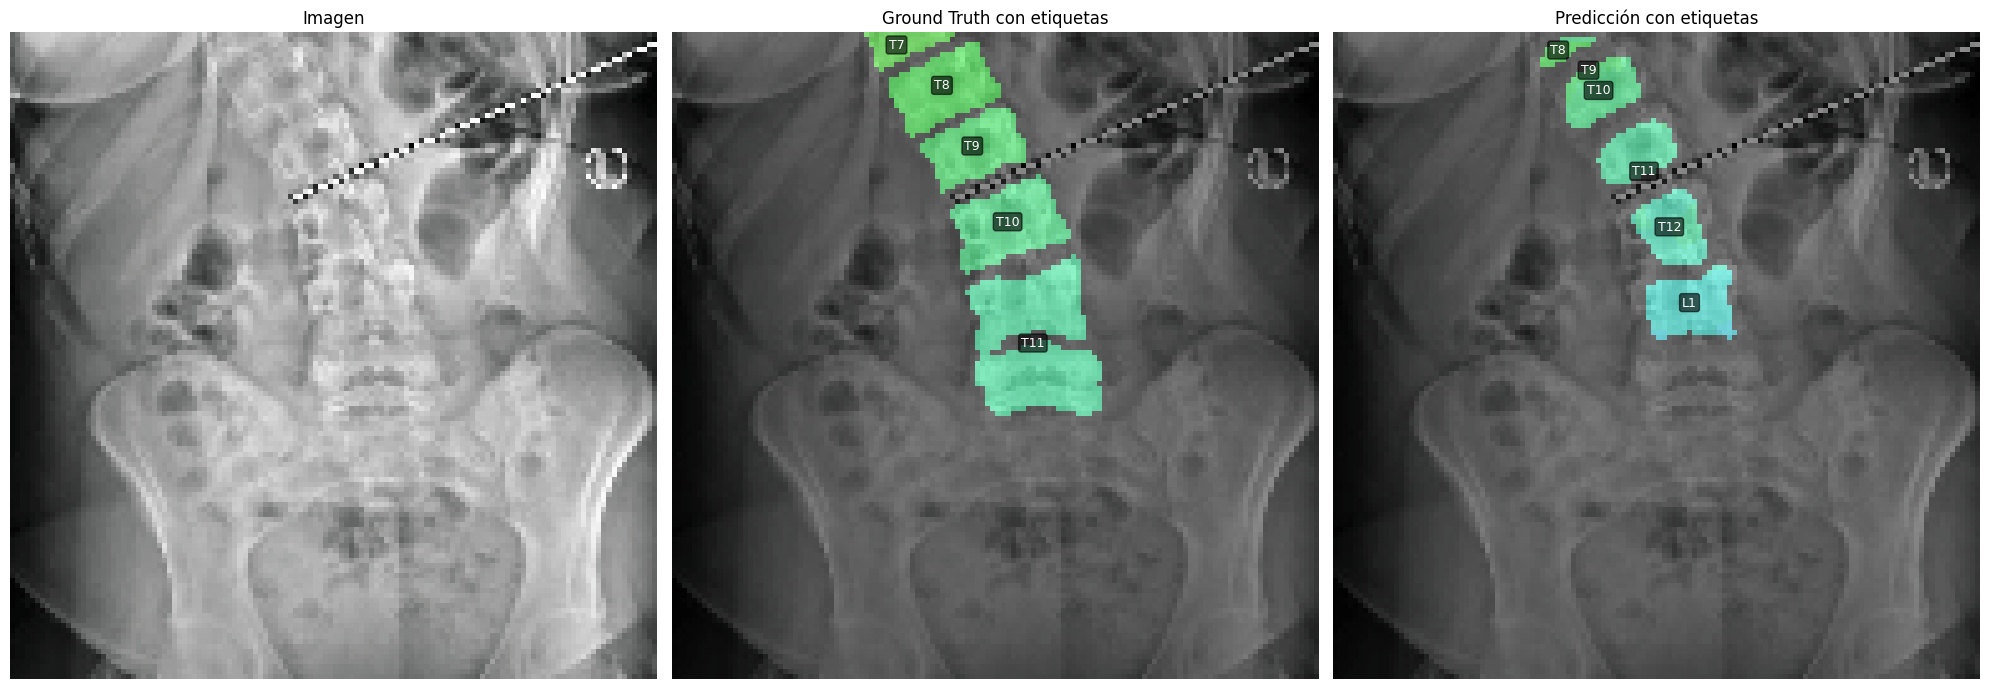

Dice Score promedio: 0.5542
Dice Score por clase: 
background 0.9752
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 0.0000
T8 0.0000
T9 0.0000
T10 0.0000
T11 0.0000
T12 0.0000
L1 0.0000
L2 0.0000
L3 1.0000
L4 1.0000
L5 1.0000
21
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_54.jpg


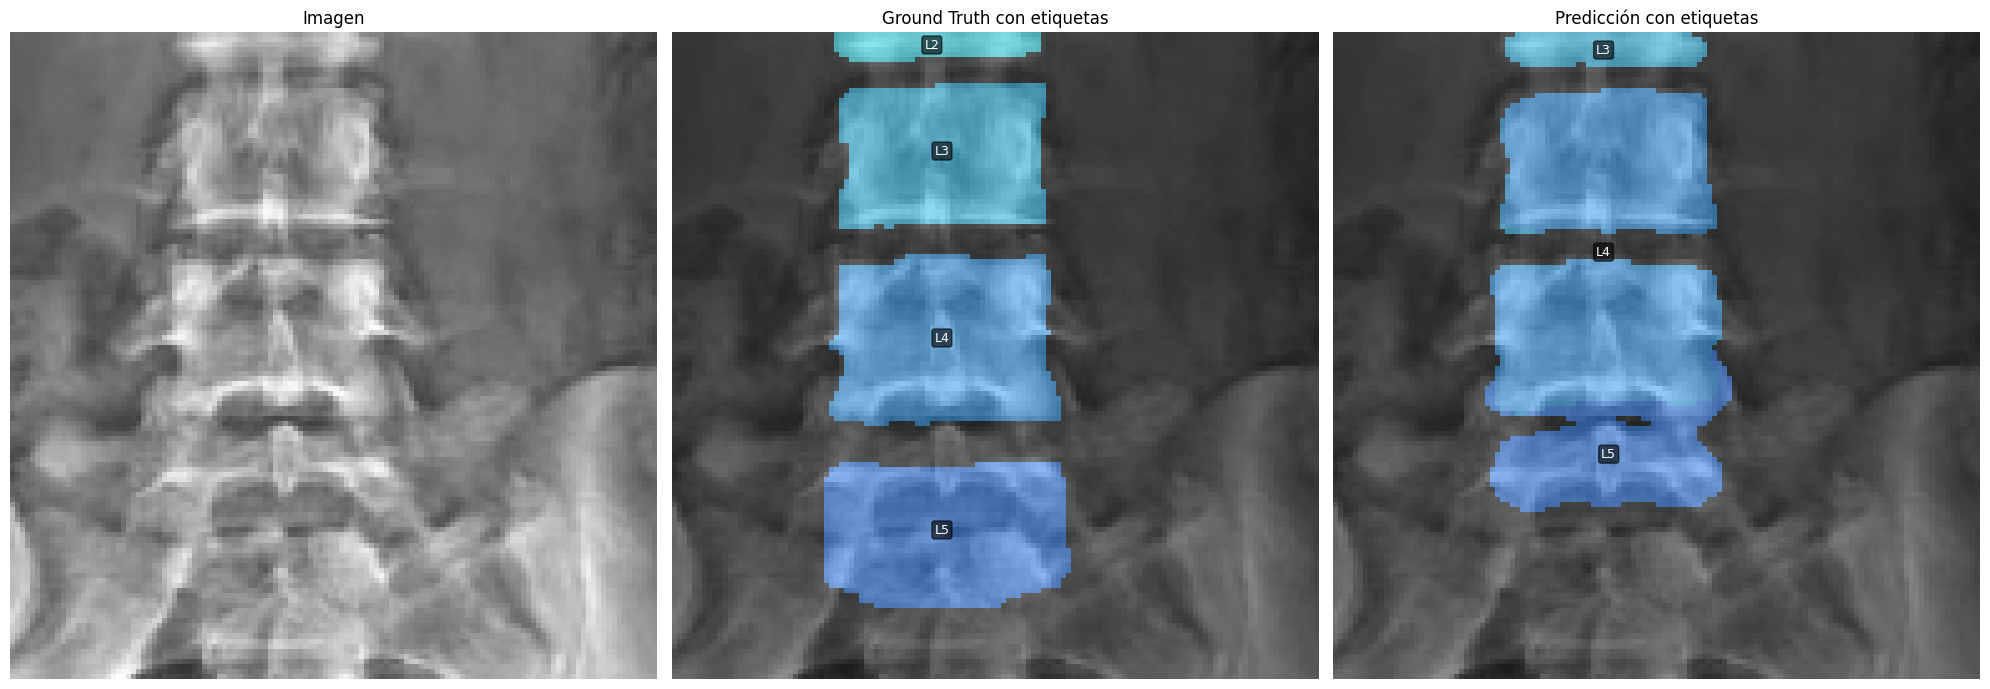

Dice Score promedio: 0.8285
Dice Score por clase: 
background 0.9358
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 1.0000
T8 1.0000
T9 1.0000
T10 1.0000
T11 1.0000
T12 1.0000
L1 1.0000
L2 0.0000
L3 0.0015
L4 0.6297
L5 0.3457
22
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_49.jpg


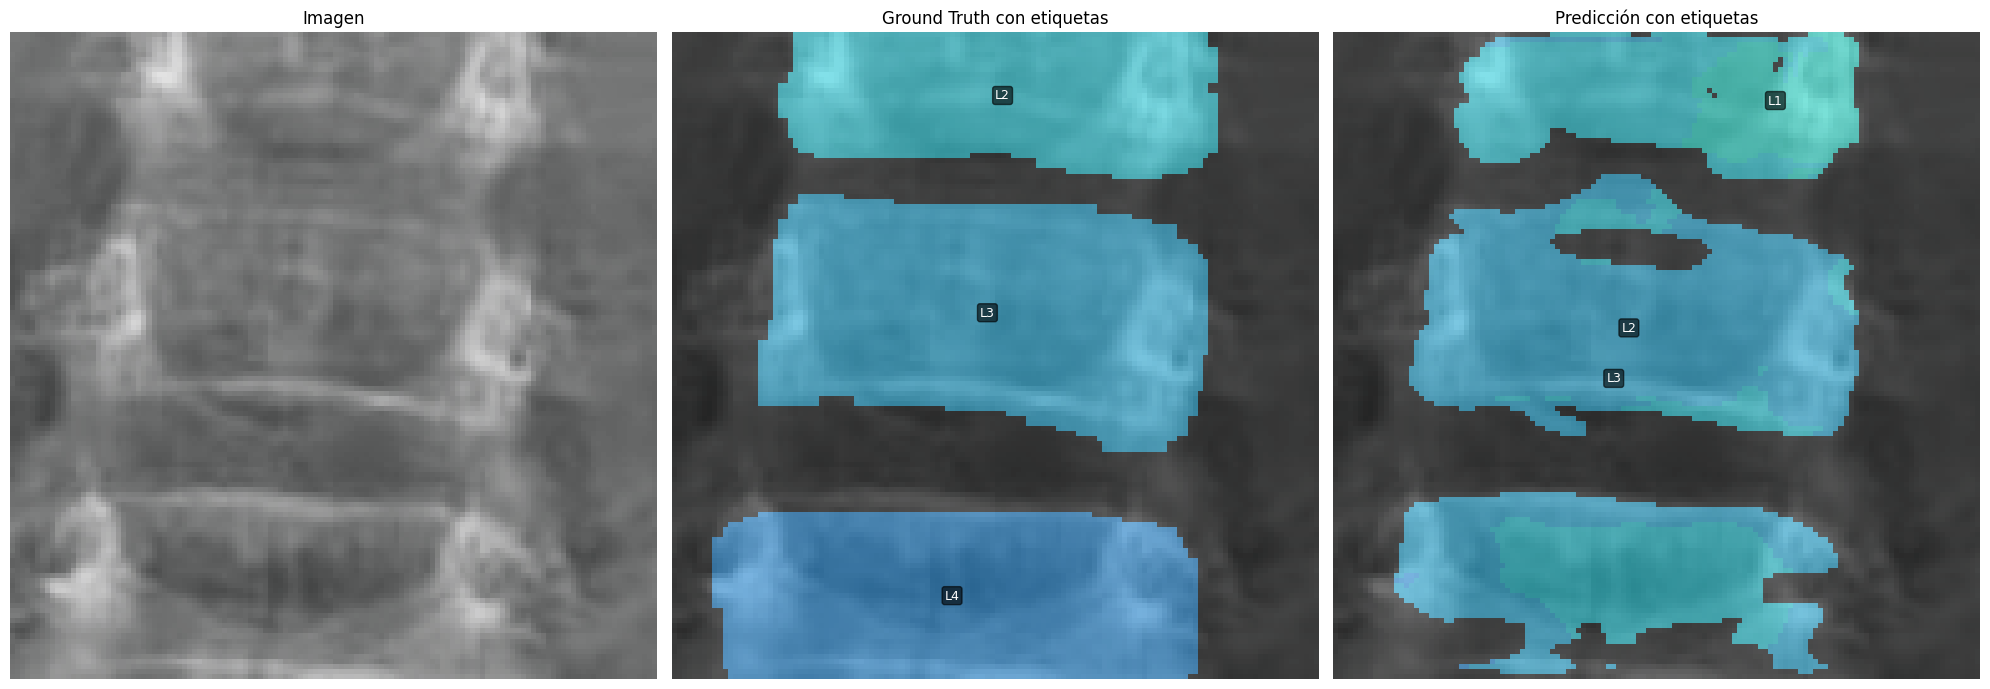

Dice Score promedio: 0.8367
Dice Score por clase: 
background 0.8572
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 1.0000
T8 1.0000
T9 1.0000
T10 1.0000
T11 1.0000
T12 1.0000
L1 0.0000
L2 0.4724
L3 0.7243
L4 0.0072
L5 1.0000
23
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_133.jpg


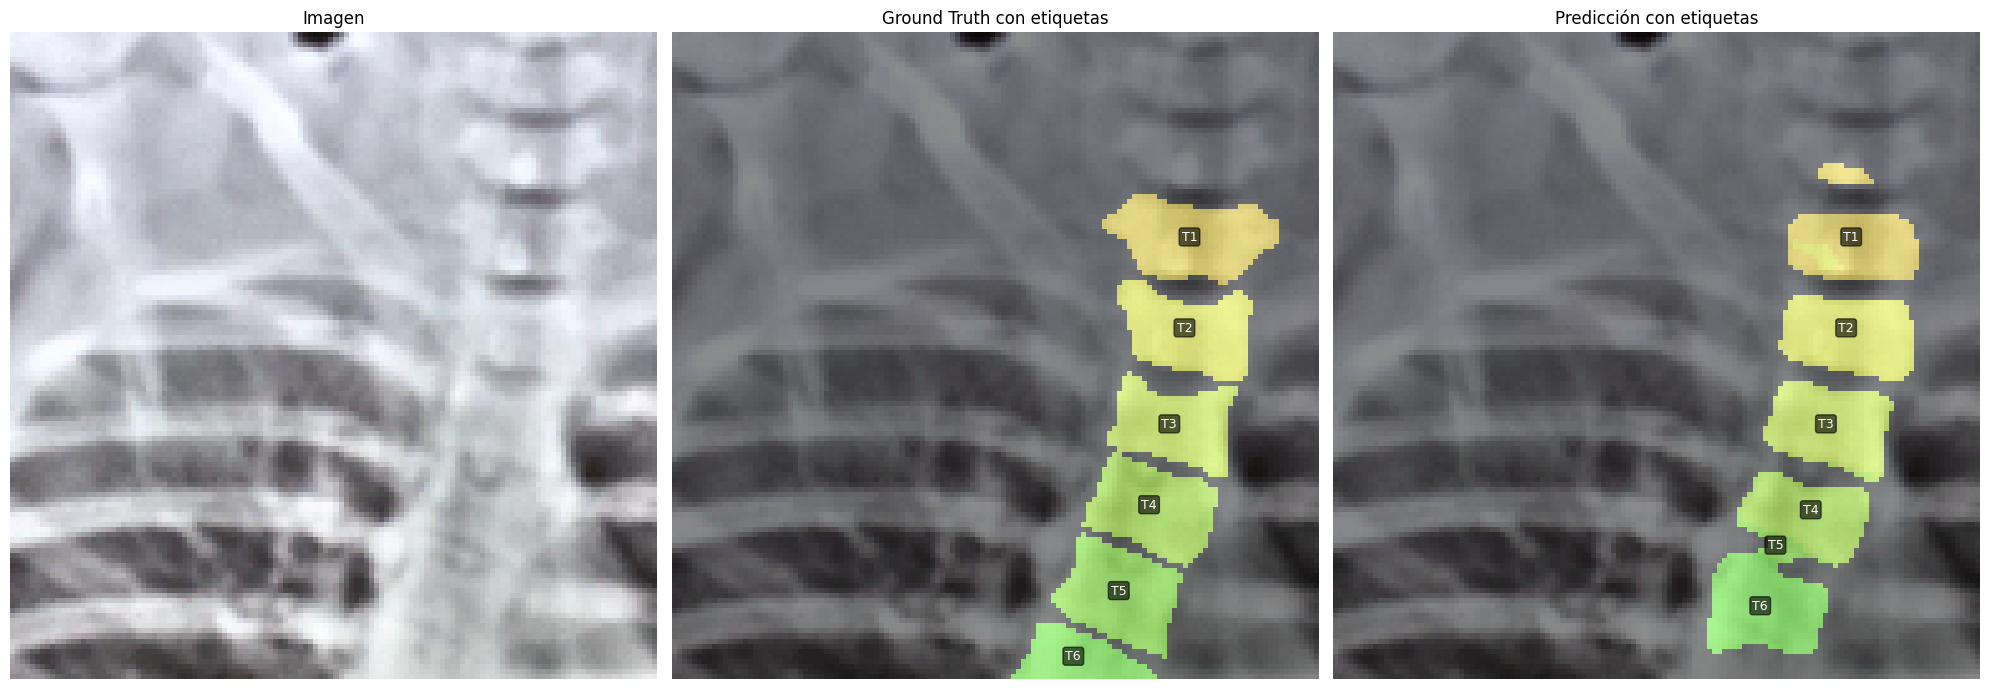

Dice Score promedio: 0.8624
Dice Score por clase: 
background 0.9738
T1 0.7302
T2 0.8594
T3 0.9010
T4 0.8208
T5 0.0930
T6 0.1449
T7 1.0000
T8 1.0000
T9 1.0000
T10 1.0000
T11 1.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
24
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_27.jpg


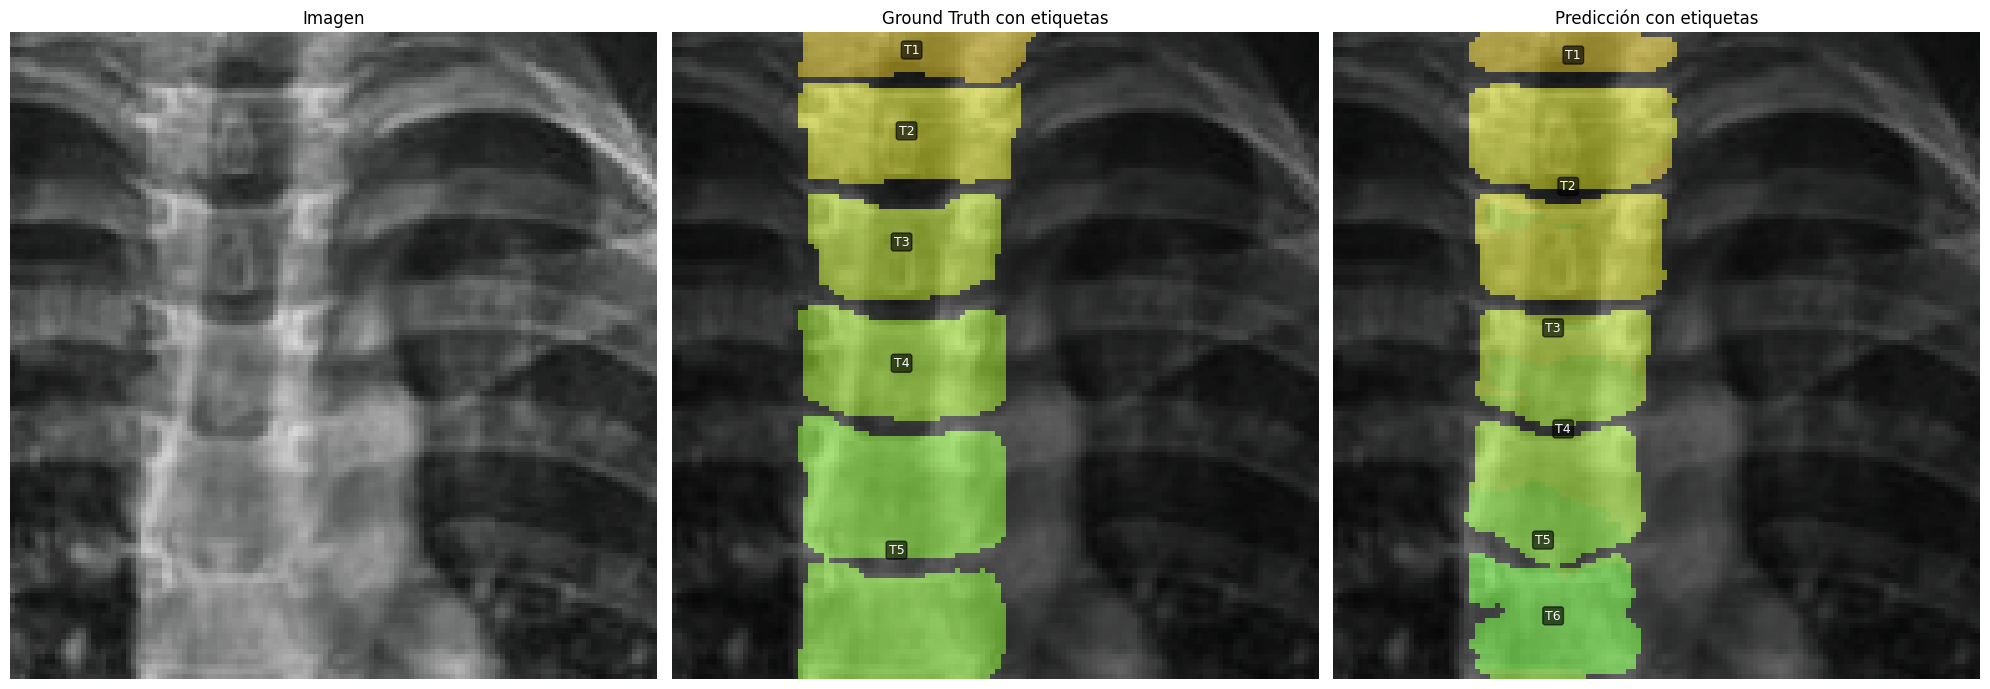

Dice Score promedio: 0.7937
Dice Score por clase: 
background 0.9620
T1 0.8524
T2 0.6463
T3 0.0846
T4 0.4168
T5 0.3252
T6 0.0000
T7 1.0000
T8 1.0000
T9 1.0000
T10 1.0000
T11 1.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
25
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_28.jpg


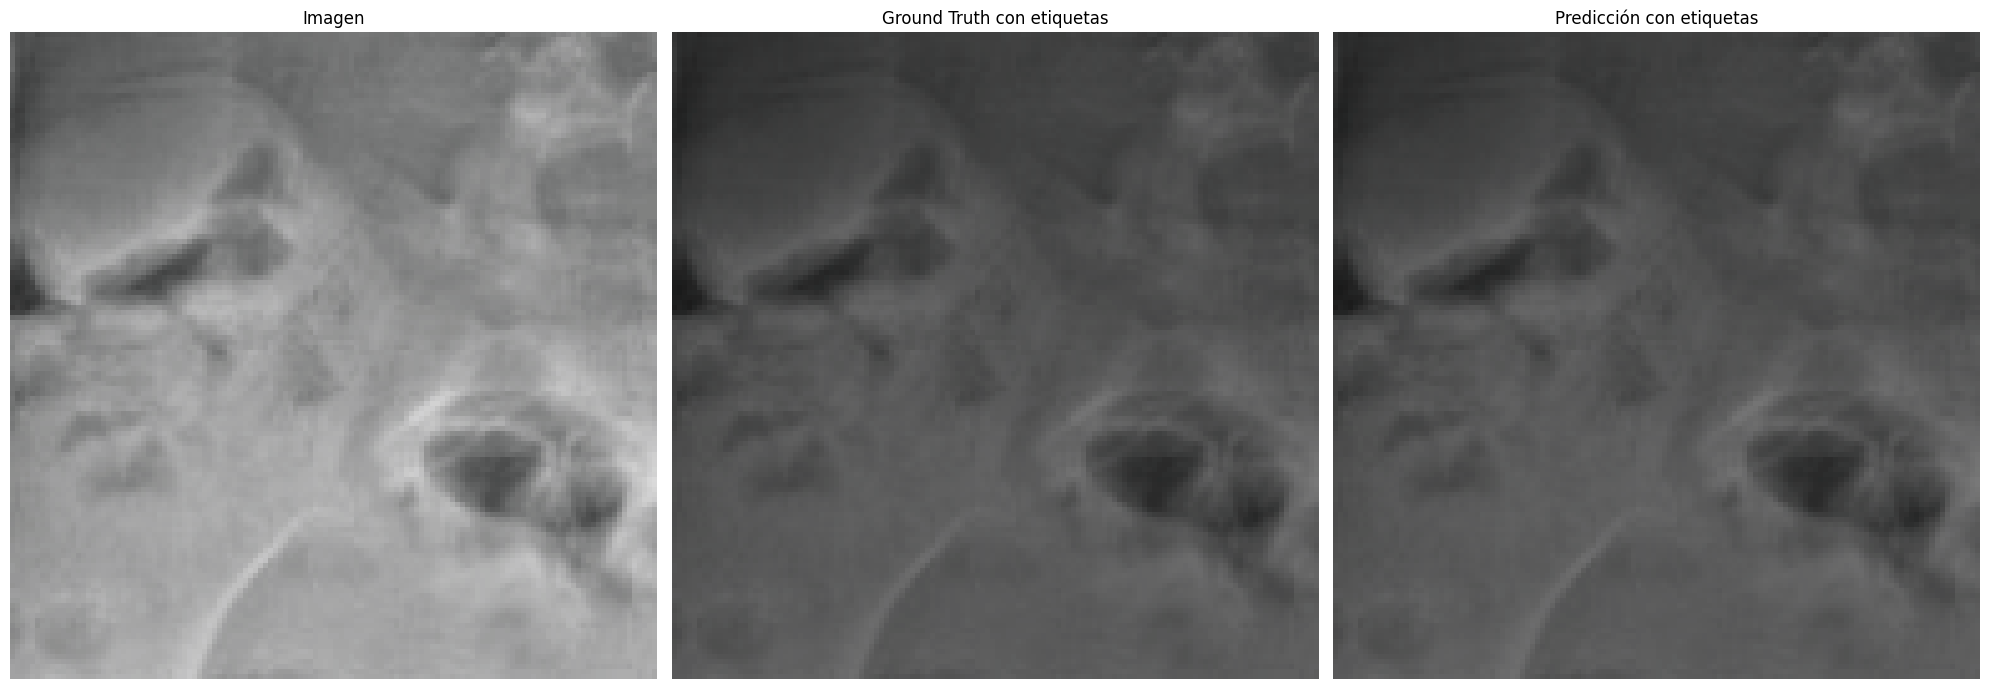

Dice Score promedio: 1.0000
Dice Score por clase: 
background 1.0000
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 1.0000
T8 1.0000
T9 1.0000
T10 1.0000
T11 1.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
26
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_42.jpg


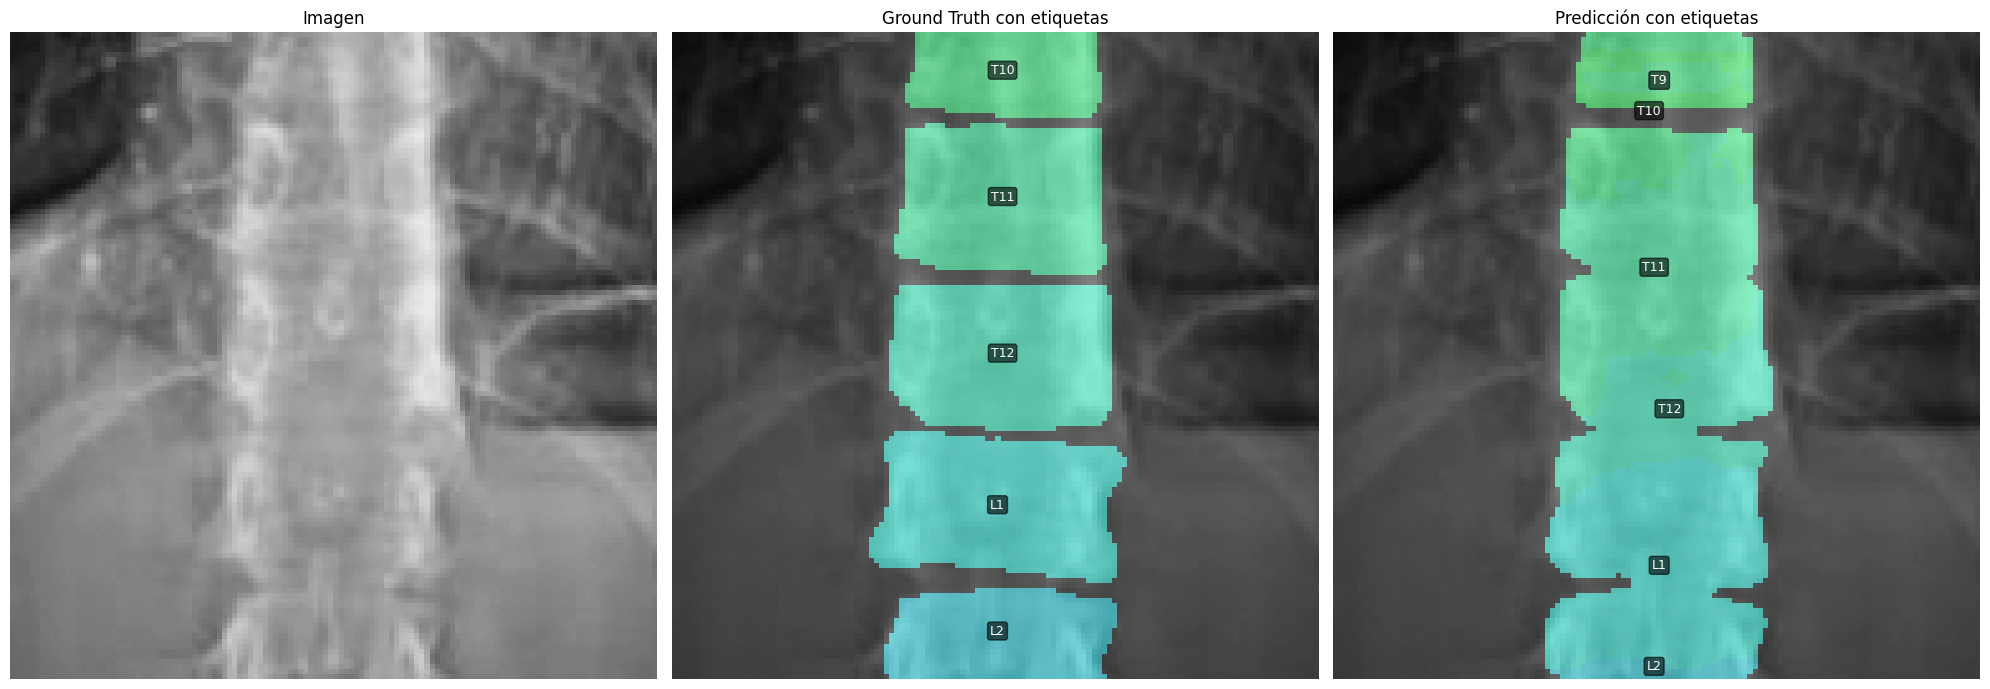

Dice Score promedio: 0.8012
Dice Score por clase: 
background 0.9699
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 1.0000
T8 1.0000
T9 0.0000
T10 0.4697
T11 0.5607
T12 0.5110
L1 0.6119
L2 0.2989
L3 1.0000
L4 1.0000
L5 1.0000
27
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_184.jpg


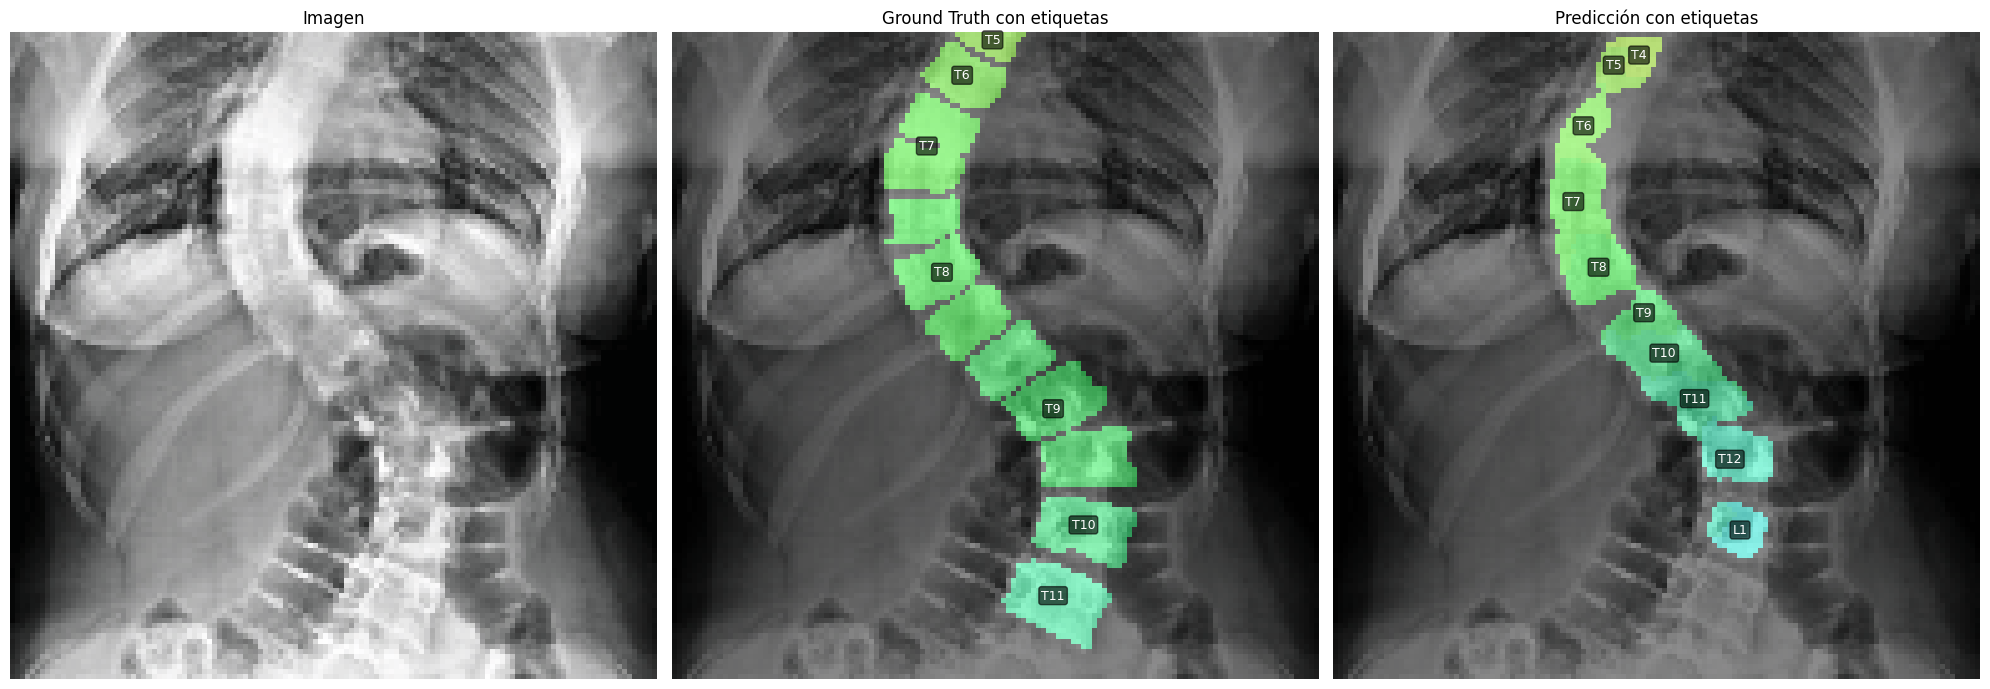

Dice Score promedio: 0.4879
Dice Score por clase: 
background 0.9706
T1 1.0000
T2 1.0000
T3 1.0000
T4 0.0000
T5 0.0187
T6 0.0255
T7 0.2695
T8 0.4852
T9 0.0126
T10 0.0000
T11 0.0000
T12 0.0000
L1 0.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
28
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_206.jpg


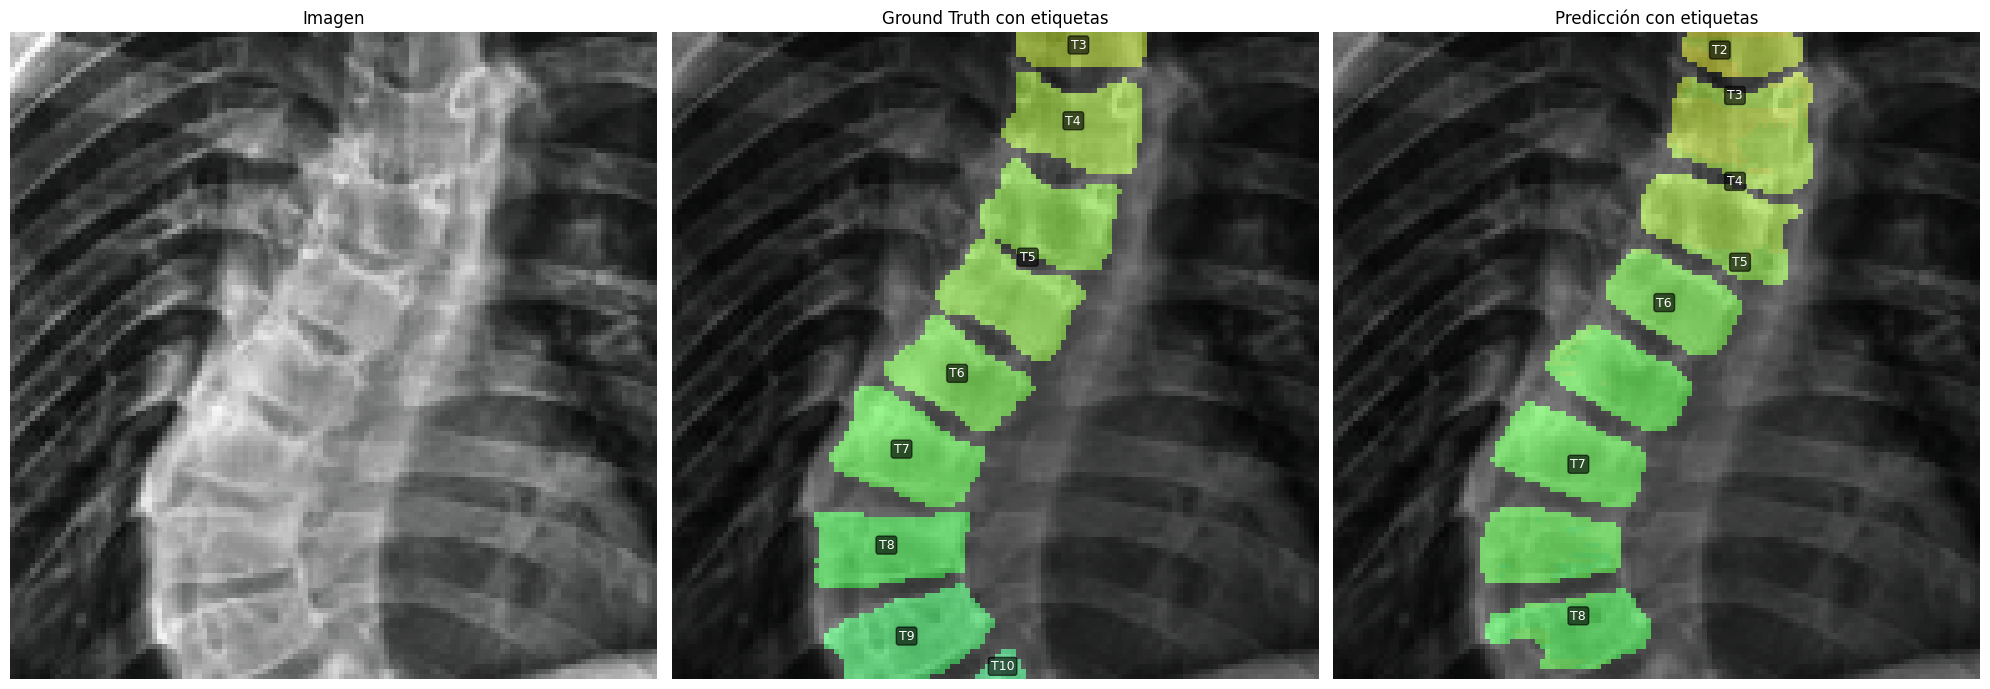

Dice Score promedio: 0.5858
Dice Score por clase: 
background 0.9724
T1 1.0000
T2 0.0000
T3 0.4154
T4 0.3521
T5 0.1189
T6 0.0650
T7 0.4980
T8 0.1221
T9 0.0000
T10 0.0000
T11 1.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
29
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_105.jpg


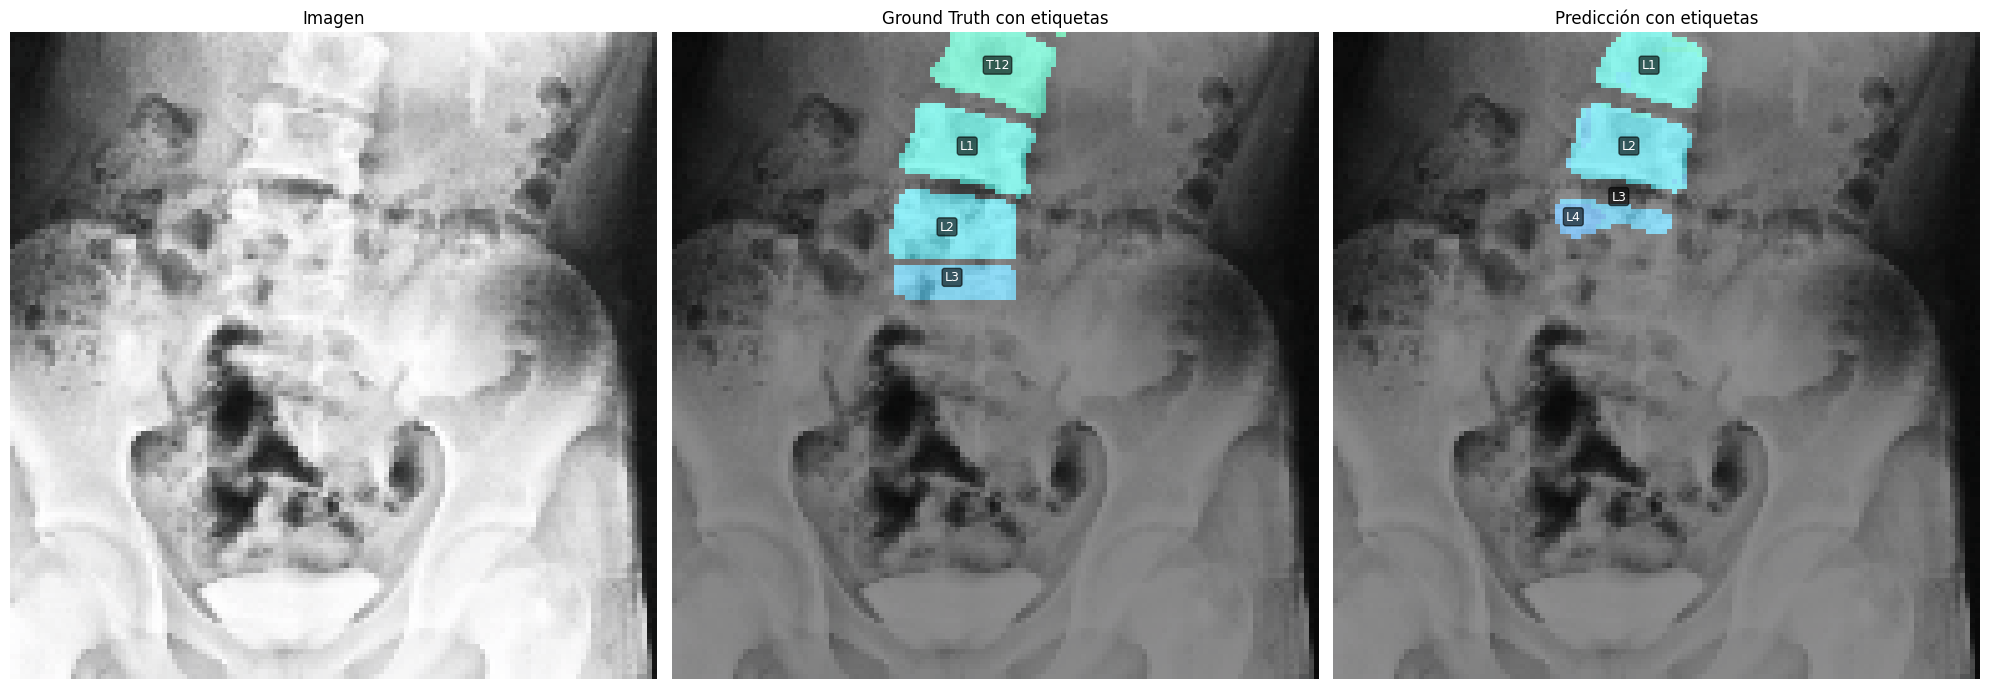

Dice Score promedio: 0.6718
Dice Score por clase: 
background 0.9858
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 1.0000
T8 1.0000
T9 1.0000
T10 1.0000
T11 0.0000
T12 0.0921
L1 0.0140
L2 0.0000
L3 0.0000
L4 0.0000
L5 1.0000
30
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_84.jpg


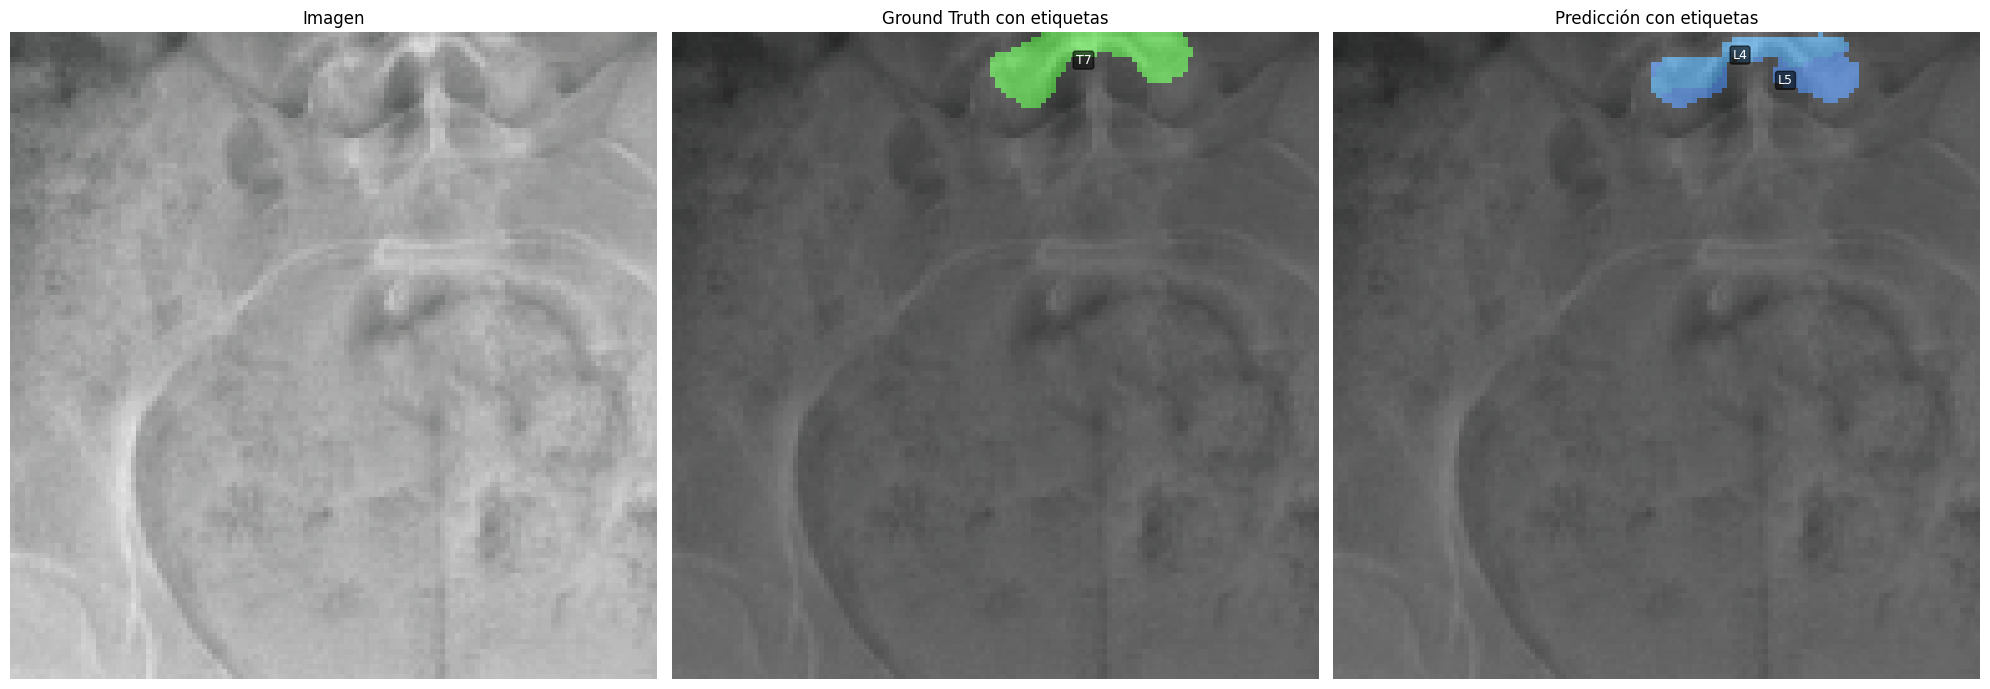

Dice Score promedio: 0.8330
Dice Score por clase: 
background 0.9945
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 0.0000
T8 1.0000
T9 1.0000
T10 1.0000
T11 1.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 0.0000
L5 0.0000
31
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_31.jpg


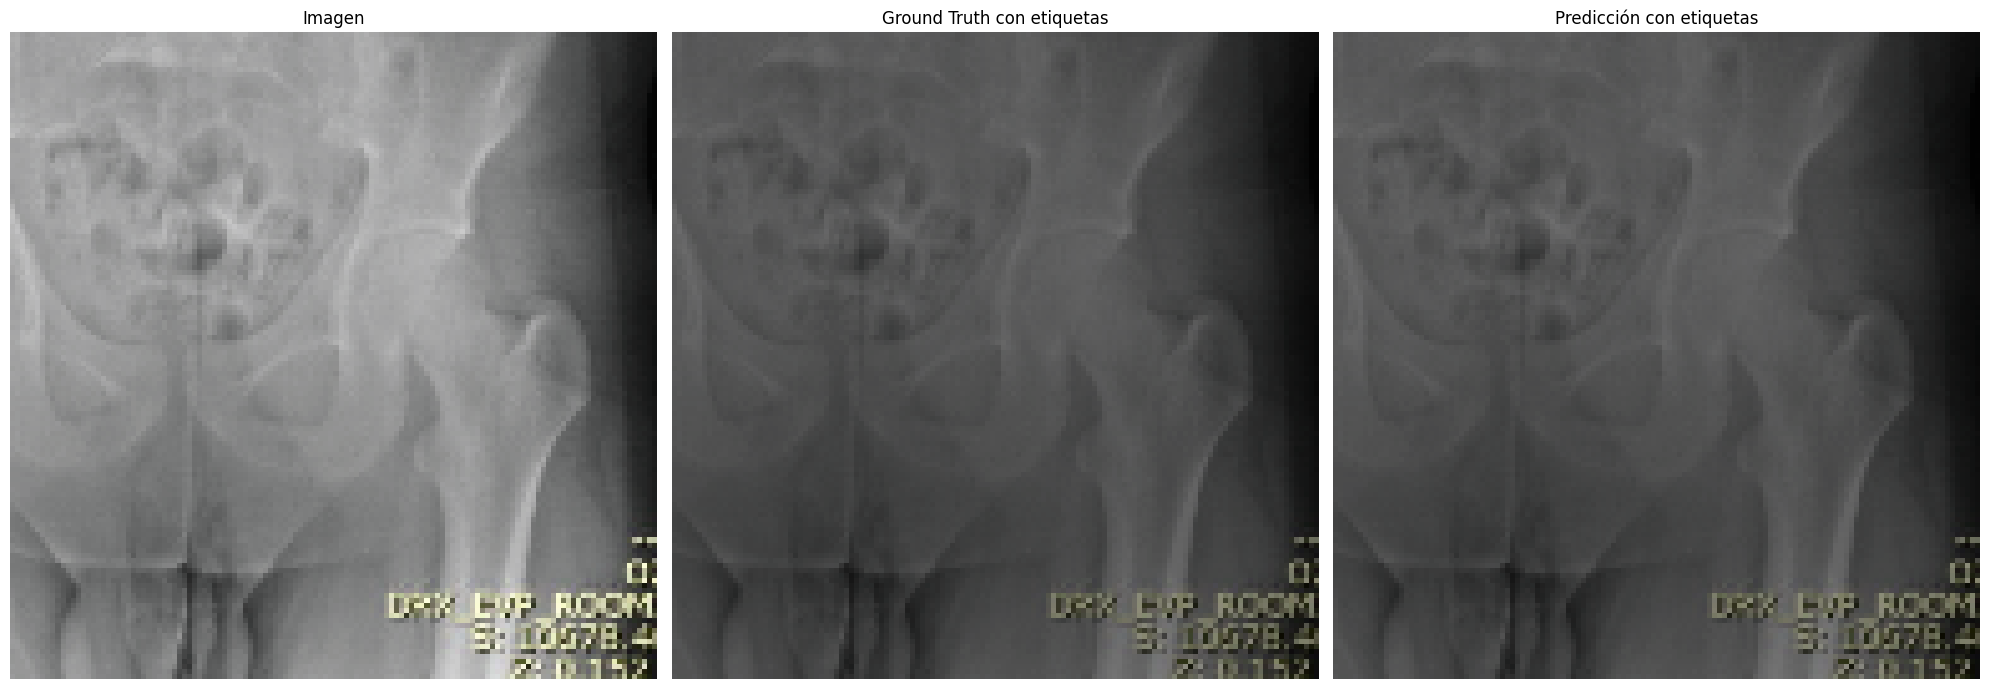

Dice Score promedio: 1.0000
Dice Score por clase: 
background 1.0000
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 1.0000
T8 1.0000
T9 1.0000
T10 1.0000
T11 1.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
32
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_142.jpg


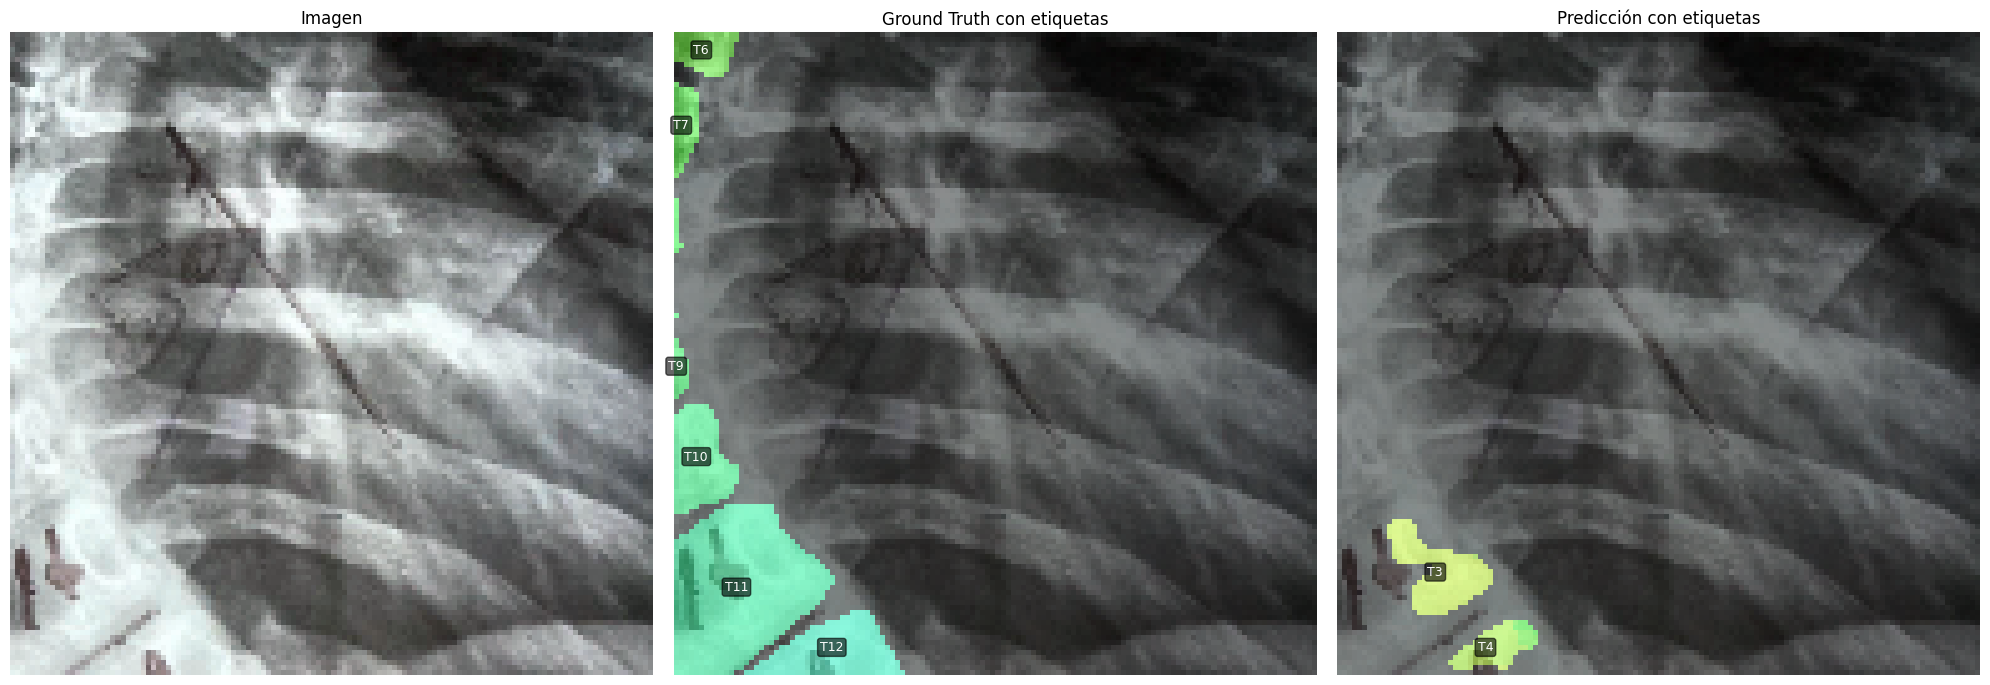

Dice Score promedio: 0.4980
Dice Score por clase: 
background 0.9637
T1 1.0000
T2 1.0000
T3 0.0000
T4 0.0000
T5 1.0000
T6 0.0000
T7 0.0000
T8 0.0000
T9 0.0000
T10 0.0000
T11 0.0000
T12 0.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
33
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_88.jpg


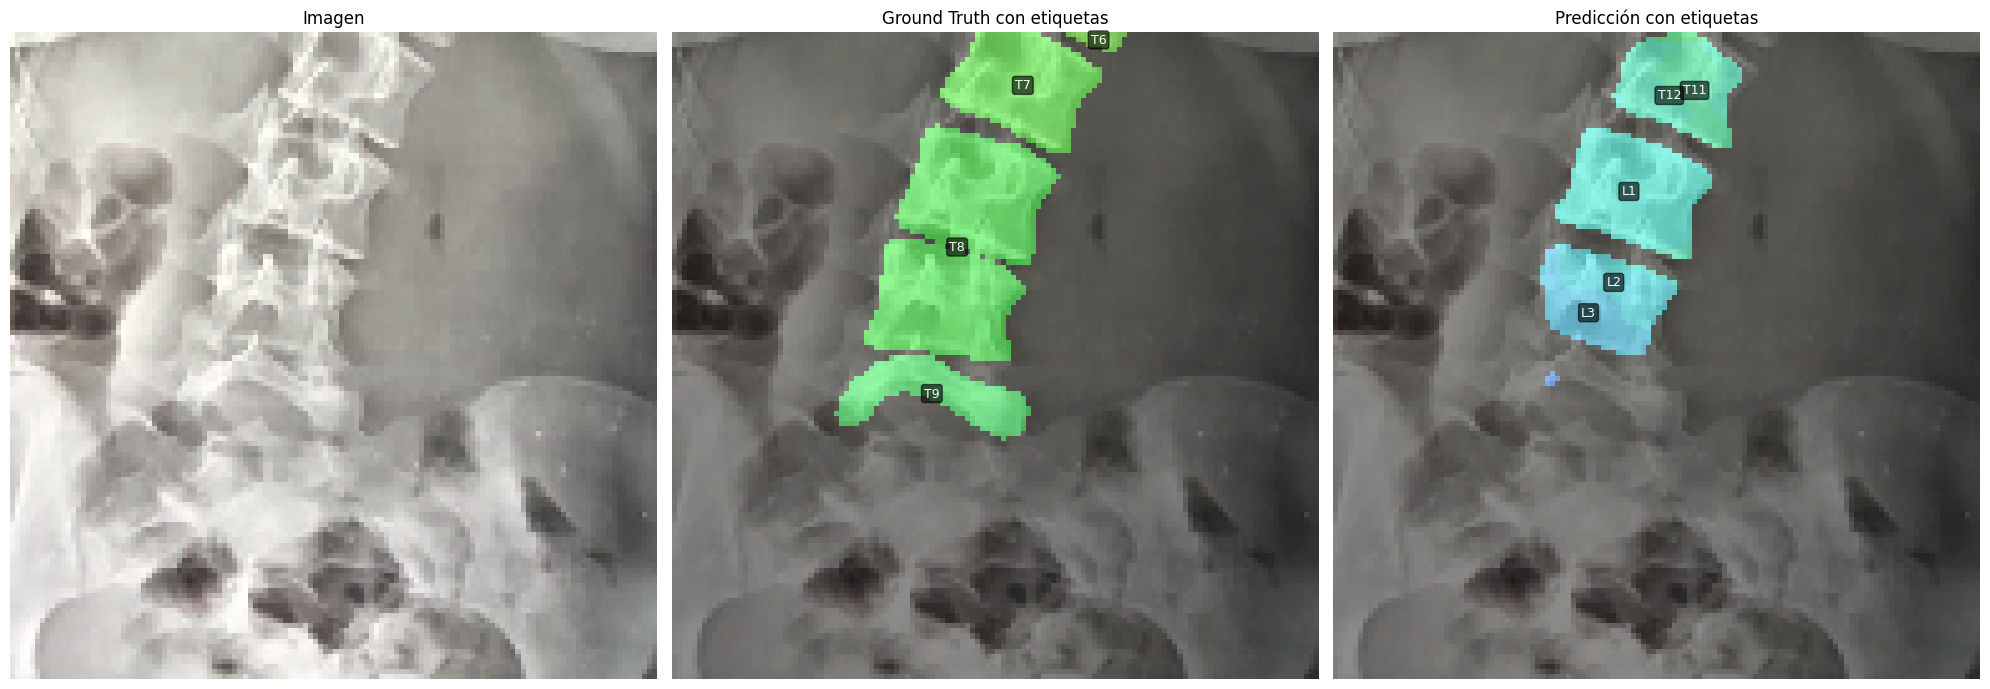

Dice Score promedio: 0.3876
Dice Score por clase: 
background 0.9765
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 0.0000
T7 0.0000
T8 0.0000
T9 0.0000
T10 0.0000
T11 0.0000
T12 0.0000
L1 0.0000
L2 0.0000
L3 0.0000
L4 1.0000
L5 0.0000
34
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_91.jpg


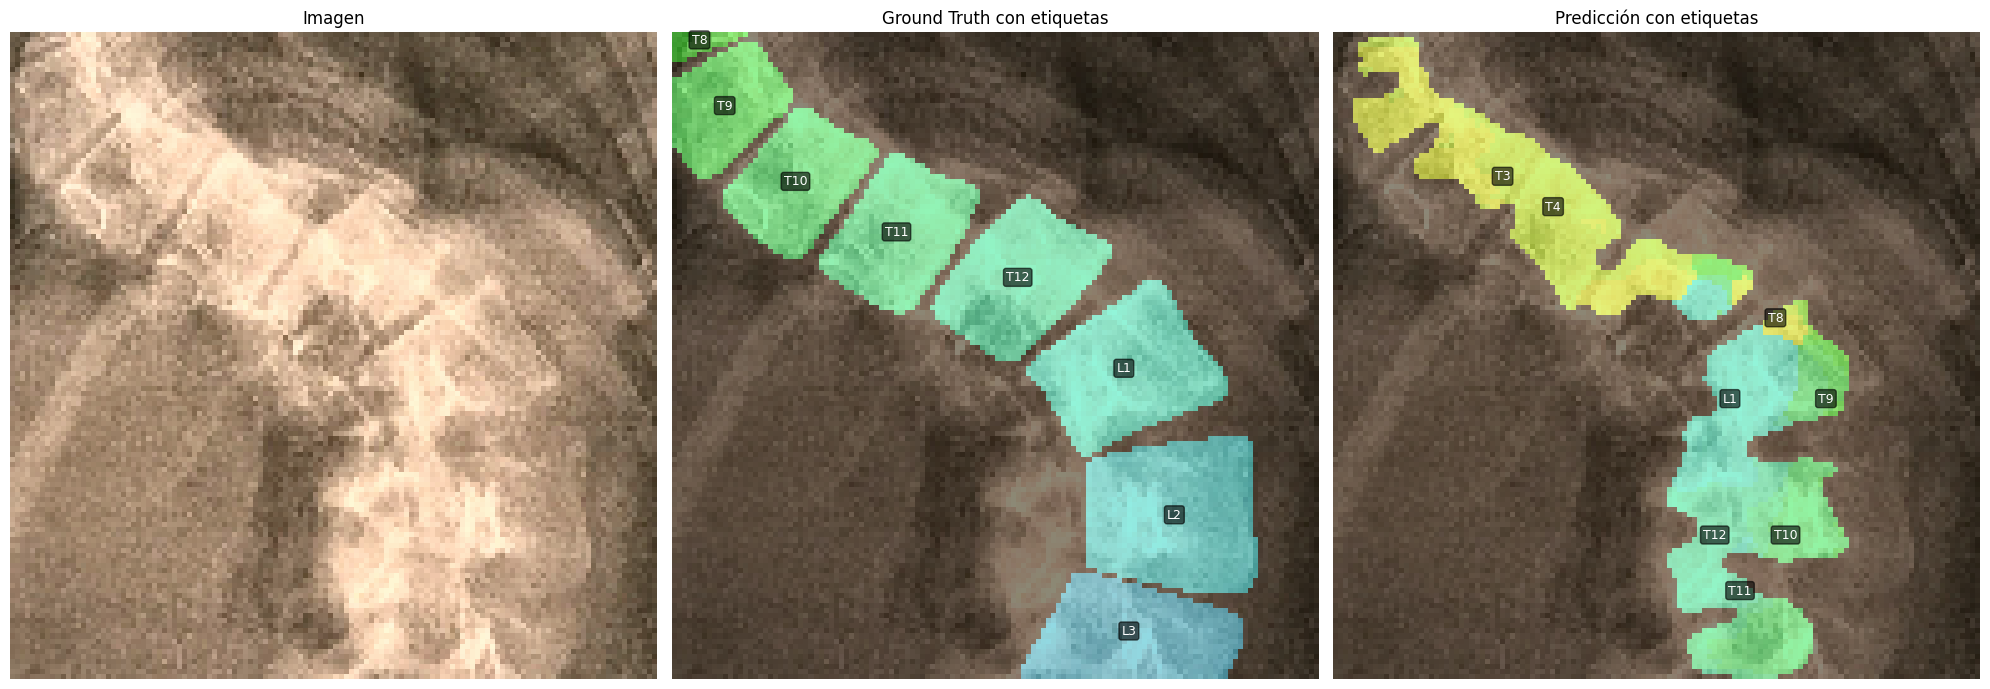

Dice Score promedio: 0.3529
Dice Score por clase: 
background 0.8885
T1 1.0000
T2 1.0000
T3 0.0000
T4 0.0000
T5 1.0000
T6 0.0000
T7 0.0000
T8 0.0000
T9 0.0000
T10 0.0000
T11 0.0000
T12 0.0000
L1 0.4643
L2 0.0000
L3 0.0000
L4 1.0000
L5 1.0000
35
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_3.jpg


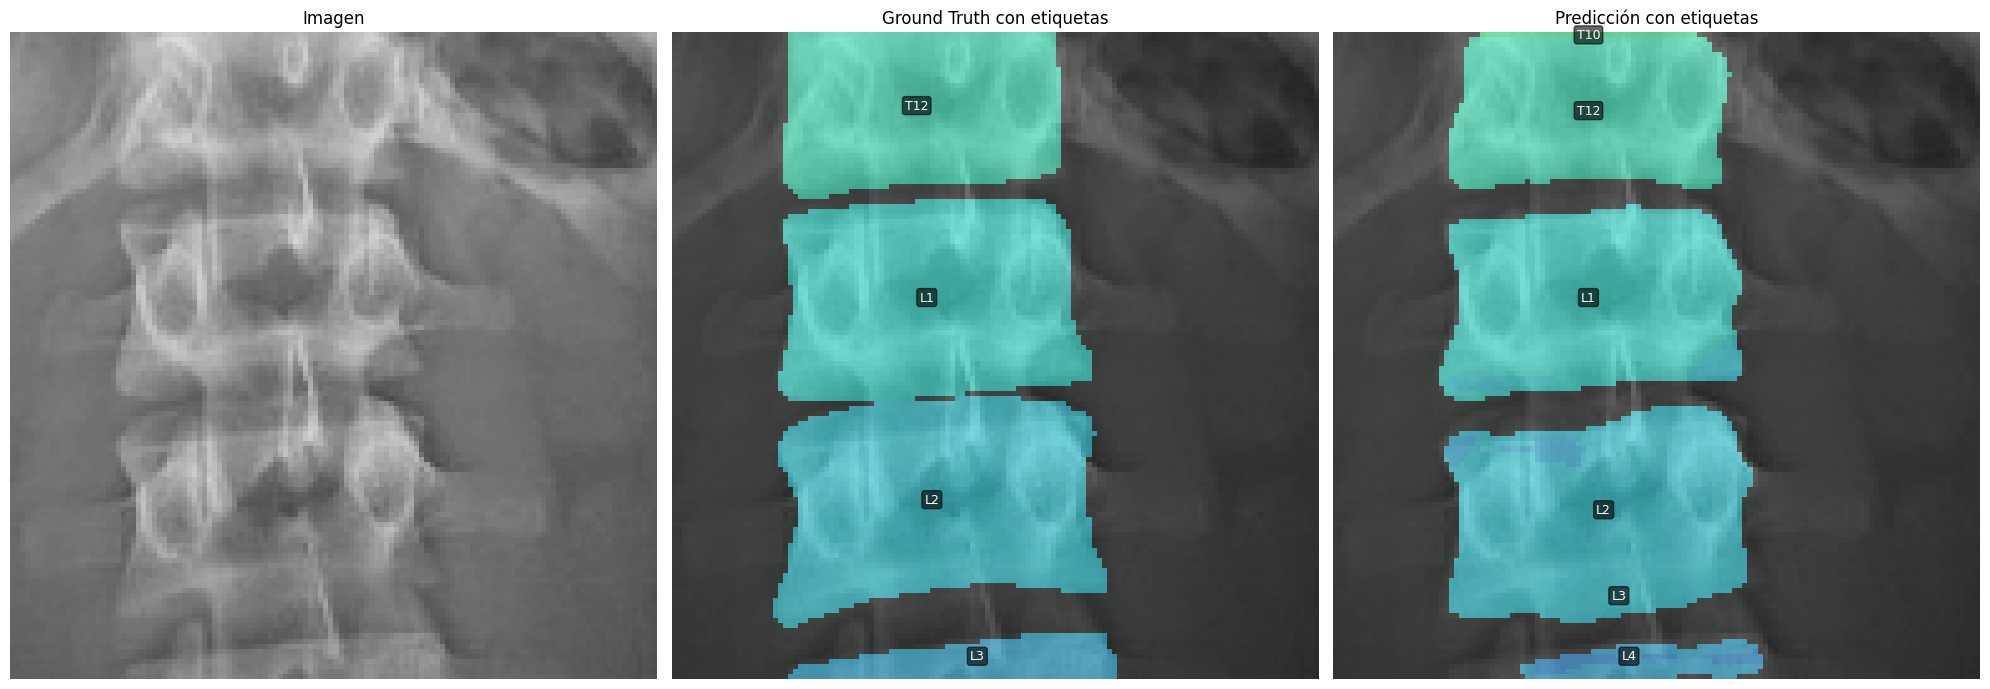

Dice Score promedio: 0.8444
Dice Score por clase: 
background 0.9450
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 1.0000
T8 1.0000
T9 1.0000
T10 0.0000
T11 1.0000
T12 0.9330
L1 0.9082
L2 0.8371
L3 0.5759
L4 0.0000
L5 1.0000
36
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Scoliosis/S_164.jpg


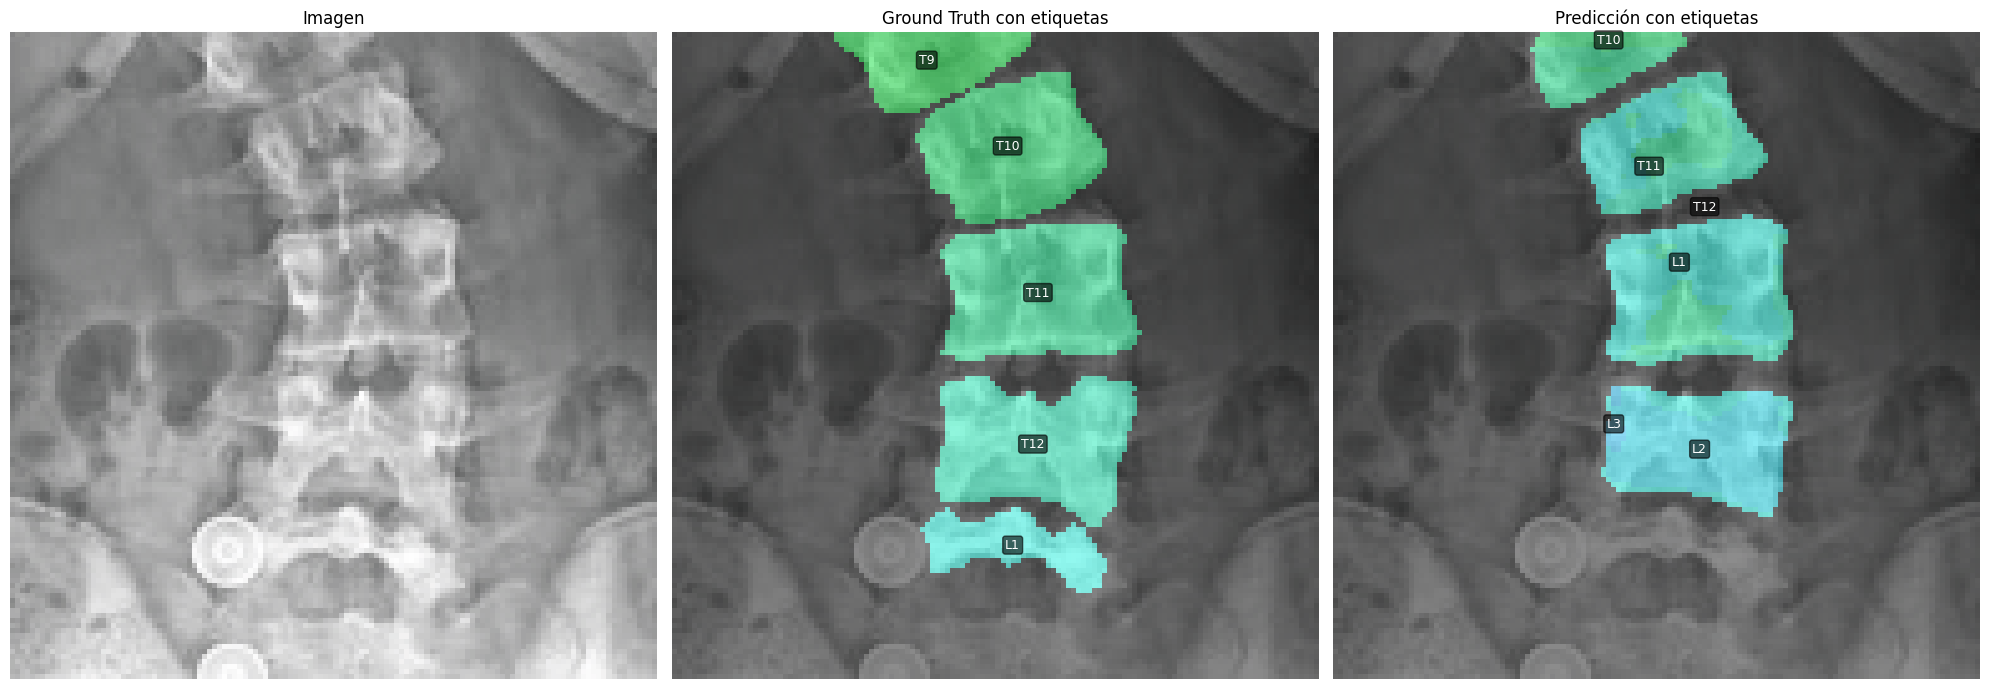

Dice Score promedio: 0.6224
Dice Score por clase: 
background 0.9710
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 1.0000
T8 1.0000
T9 0.0000
T10 0.0000
T11 0.2324
T12 0.0000
L1 0.0000
L2 0.0000
L3 0.0000
L4 1.0000
L5 1.0000
37
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_67.jpg


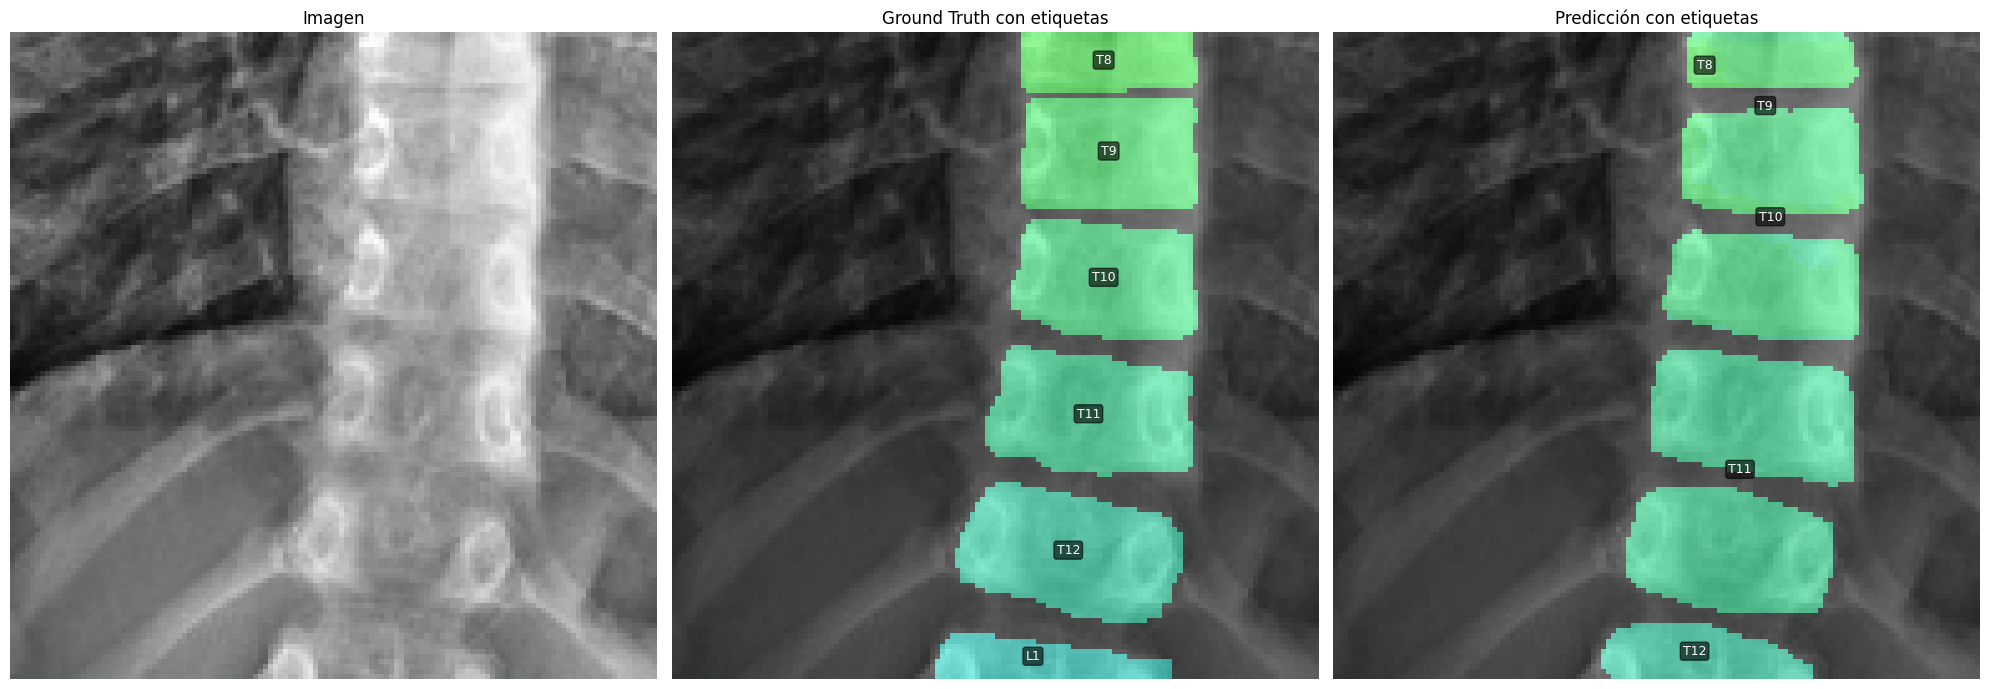

Dice Score promedio: 0.7589
Dice Score por clase: 
background 0.9768
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 1.0000
T8 0.2576
T9 0.2021
T10 0.6043
T11 0.6189
T12 0.0000
L1 0.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000


In [40]:
import random
# Seleccionar un índice aleatorio del dataset de test
# idx = random.randint(0, len(test_dataset) - 1)
# print(idx)
for idx in range(len(test_dataset)):
    print(idx)
    show_gt_vs_pred_with_labels(
        model=model,
        dataset=test_dataset,
        device=device,
        idx=idx,
        patch_idx = random.randint(0, NUM_PATCHES-1),
        label_dict=dic_labels,
        alpha=0.45,
        min_pixels=20
    )